# EDA — Base Analítica de Alfabetização

## Objetivo
Realizar uma **Análise Exploratória de Dados (EDA)** sobre alfabetização e proficiência dos alunos, combinando dados individuais e variáveis de contexto escolar, municipal e estadual.

## Perguntas que orientam a análise

1. A base tem problemas de qualidade, nulos, duplicidades ou colunas inadequadas?
2. Qual é a distribuição dos alvos e existe desbalanceamento relevante?
3. Há mudança de comportamento entre os anos?
4. Quais contextos socioeconômico, territorial e educacional prévio apresentam associação com o desempenho?
5. Há colinearidade, escalas incompatíveis ou risco de vazamento de dados?
6. Como as evidências devem orientar a escolha, validação e avaliação dos modelos?


## 1. Ambiente, dependências e leitura

1.   List item
2.   List item



A base completa possui múltiplos anos e pode exigir muita memória. Por isso, a EDA detalhada trabalha com a partição de 2024. Esse ano é adequado porque possui contexto histórico (`lag1`), enquanto 2023 não o possui por construção.

O Indicador Criança Alfabetizada foi criado em 2023 pelo Ministério da Educação (MEC) e pelo Inep para medir o percentual de crianças alfabetizadas ao final do 2º ano do ensino fundamental


In [51]:
AMBIENTE_COLAB = False

In [52]:
if AMBIENTE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')


In [53]:
# Dependências necessárias no ambiente Colab.
if AMBIENTE_COLAB:
    !pip install -q loguru python-dotenv pyarrow


In [54]:
import gc
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Ajuste se a pasta do projeto estiver em outro local no seu Drive.
if AMBIENTE_COLAB:
    PROJECT_ROOT = Path('/content/drive/Othercomputers/@lua2026/01_projects/2026_FIAP/desafios/postech-challenge-3')
else:
    PROJECT_ROOT = Path('.').resolve()

sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR
from src.preprocessing.io import read_parquet


In [55]:
ANO_ANALISE = 2024
CAMINHO_BASE = PROCESSED_DATA_DIR / 'base_analitica'
ARQUIVO_ANO = CAMINHO_BASE / f'ano={ANO_ANALISE}' / 'part.parquet'

df = read_parquet(ARQUIVO_ANO)
if '_gold_processed_at' in df.columns:
    df = df.drop(columns='_gold_processed_at')

print(f'Ano analisado: {ANO_ANALISE}')
print(f'Dimensões: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas')
print(f'Memória: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB')
display(df.head())


Ano analisado: 2024
Dimensões: 1,851,828 linhas x 84 colunas
Memória: 1,248.6 MB


,ano,id_uf,id_municipio,id_escola,id_aluno,dependencia_administrativa,label_proficiencia,label_alfabetizado,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_anos_finais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atu_fundamental_6_ano,ctx_atu_fundamental_7_ano,ctx_atu_fundamental_8_ano,ctx_atu_fundamental_9_ano,ctx_atu_multietapa,ctx_atu_medio,ctx_atu_medio_1_serie,ctx_atu_medio_2_serie,ctx_atu_medio_3_serie,ctx_atu_medio_4_serie,ctx_atu_medio_nao_seriado,ctx_atlas_idhm,ctx_atlas_idhm_educacao,ctx_atlas_idhm_renda,ctx_atlas_idhm_longevidade,ctx_atlas_taxa_analfabetismo_11a14,ctx_atlas_taxa_analfabetismo_15a17,ctx_atlas_taxa_analfabetismo_15mais,ctx_atlas_taxa_frequencia_6a14,ctx_atlas_taxa_frequencia_4a5,ctx_atlas_taxa_frequencia_0a3,ctx_atlas_expectativa_anos_estudo,ctx_atlas_taxa_fundamental_incompleto,ctx_atlas_renda_per_capita,ctx_atlas_indice_gini,ctx_atlas_indice_theil,ctx_atlas_razao_10_ricos_40_pobres,ctx_atlas_percentual_pobres,ctx_atlas_percentual_extremamente_pobres,ctx_atlas_percentual_vulneraveis_pobreza,ctx_atlas_percentual_pobres_criancas,ctx_atlas_percentual_extremamente_pobres_criancas,ctx_atlas_percentual_vulneraveis_pobreza_criancas,ctx_atlas_mortalidade_ate_1_ano,ctx_atlas_mortalidade_ate_5_anos,ctx_atlas_taxa_trabalho_infantil_10a14,ctx_atlas_taxa_maes_10a14,ctx_atlas_taxa_maes_chefes_familia,ctx_atlas_taxa_fora_escola_4a5,ctx_atlas_taxa_fora_escola_6a14,ctx_atlas_taxa_frequencia_liquida_fundamental,ctx_atlas_taxa_domicilios_vulneraveis_sem_fundamental,ctx_atlas_taxa_criancas_em_domicilios_sem_fundamental,ctx_atlas_percentual_domicilios_agua,ctx_atlas_percentual_domicilios_energia,ctx_atlas_taxa_densidade_domiciliar,ctx_fundeb_nse_municipio,ctx_fundeb_ponderador_nse_municipio,ctx_fundeb_nse_uf,ctx_fundeb_ponderador_nse_uf,ctx_ibge_populacao_residente,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_mediana,ctx_ibge_renda_domiciliar_per_capita_media,ctx_inep_mun_taxa_alfabetizacao_lag1,ctx_inep_mun_media_portugues_lag1,ctx_inep_mun_percentual_participacao_lag1,ctx_inep_mun_nivel_alfabetizacao_lag1,ctx_inep_mun_meta,ctx_inep_uf_taxa_alfabetizacao_lag1,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,ctx_inep_uf_meta
0,2024,11,1100015,60000163,11022231,3,759.430,1,18.800,14.800,20.900,18.900,22.100,12.900,23.400,21.300,23.400,21.000,20.600,12.800,13.900,13.100,11.800,20.600,NaN,NaN,NaN,NaN,NaN,NaN,0.641,0.526,0.657,0.763,1.220,1.520,11.990,95.680,39.180,4.890,8.670,40.270,476.990,0.580,0.600,21.680,26.040,14.290,47.120,37.330,19.010,62.990,23.800,25.490,9.080,0.000,14.510,60.820,4.320,92.880,24.810,45.730,93.690,93.980,22.580,48.613,1.003,49.335,1.001,22853,"7,067.127",0.397,0.005,920.000,"1,210.600",64.550,758.330,89.370,3,67.000,64.600,759.436,88.100,67.000
1,2024,11,1100015,60000164,11019498,3,741.280,0,18.800,14.800,20.900,18.900,22.100,12.900,23.400,21.300,23.400,21.000,20.600,12.800,13.900,13.100,11.800,20.600,NaN,NaN,NaN,NaN,NaN,NaN,0.641,0.526,0.657,0.763,1.220,1.520,11.990,95.680,39.180,4.890,8.670,40.270,476.990,0.580,0.600,21.680,26.040,14.290,47.120,37.330,19.010,62.990,23.800,25.490,9.080,0.000,14.510,60.820,4.320,92.880,24.810,45.730,93.690,93.980,22.580,48.613,1.003,49.335,1.001,22853,"7,067.127",0.397,0.005,920.000,"1,210.600",64.550,758.330,89.370,3,67.000,64.600,759.436,88.100,67.000
2,2024,11,1100015,60000334,11019621,3,807.040,1,18.800,14.800,20.900,18.900,22.100,12.900,23.400,21.300,23.400,21.000,20.600,12.800,13.900,13.100,11.800,20.600,NaN,NaN,NaN,NaN,NaN,NaN,0.641,0.526,0.657,0.763,1.220,1.520,11.990,95.680,39.180,4.890,8.670,40.270,476.990,0.580,0.600,21.680,26.040,14.290,47.120,37.330,19.010,62.990,23.800,25.490,9.080,0.000,14.510,60.820,4.320,92.880,24.810,45.730,93.690,93.980,22.580,48.613,1.003,49.335,1.001,22853,"7,067.1

### SIGNIFICADO DE CADA COLUNA

#### Identificação

| Coluna | Significado |
|---|---|
| `ano` | Ano de referência da observação (2023, 2024 ou 2025) |
| `id_uf` | Código IBGE da Unidade Federativa |
| `id_municipio` | Código IBGE do município (7 dígitos) |
| `id_escola` | Código INEP da escola |
| `id_aluno` | Identificador único do aluno |
| `dependencia_administrativa` | Rede de ensino do aluno — nominal: `2` = estadual, `3` = municipal (única coluna da base que descreve o aluno, não o lugar) |

#### Alvos

| Coluna | Significado |
|---|---|
| `label_proficiencia` | Nota contínua de proficiência em Língua Portuguesa (escala ~572 a 905) — alvo de regressão |
| `label_alfabetizado` | Alvo binário derivado do corte de proficiência ≥ 743 — alvo de classificação. Idêntico a `label_proficiencia >= 743` em 100% das linhas |

#### Interpretação oficial de `ctx_inep_mun_nivel_alfabetizacao_lag1`

A variável `ctx_inep_mun_nivel_alfabetizacao_lag1` — daqui em diante também referida pelo alias `nivel_lag1` — é uma **classificação oficial, histórica e ordinal** do desempenho municipal anterior. Ela não foi criada por este notebook.

| Nível | Faixa oficial do indicador |
|---:|---|
| 0 | abaixo do nível 1 — até 40% |
| 1 | nível 1 — acima de 40% até 50% |
| 2 | nível 2 — acima de 50% até 60% |
| 3 | nível 3 — acima de 60% até 70% |
| 4 | nível 4 — acima de 70% até 80% |
| 5 | nível 5 — acima de 80% |

A variável tem **ordem**, mas não deve ser tratada automaticamente como contínua: `0 < 1 < 2 < 3 < 4 < 5` não implica distâncias métricas iguais entre categorias.

Também é importante separar as duas granularidades presentes na base:

| Granularidade | Informação | Papel |
|---|---|---|
| aluno-ano | `label_alfabetizado` | resultado individual |
| aluno-ano | `label_proficiencia` | resultado individual |
| município-ano | `taxa_lag1` | desempenho municipal anterior |
| município-ano | `nivel_lag1` | classificação oficial ordinal do desempenho municipal anterior |
| município-ano | `meta` | meta municipal |
| município-ano | demais `ctx_*` | contexto municipal |

O significado de `nivel_lag1` é registrado aqui desde o início, mas sua **distribuição não deve ser calculada dando peso a cada aluno**. Como se trata de indicador municipal, as análises de frequência, comparação temporal, UF/região e relação com `taxa_lag1` são feitas adiante, depois da reconstrução da base município-ano.

#### ATU — Censo Escolar (alunos por turma, casado por `ano + id_municipio + rede`)

| Coluna | Significado |
|---|---|
| `ctx_atu_educacao_infantil` | Média de alunos por turma na educação infantil (creche + pré-escola) |
| `ctx_atu_creche` | Média de alunos por turma na creche |
| `ctx_atu_pre_escola` | Média de alunos por turma na pré-escola |
| `ctx_atu_fundamental` | Média de alunos por turma no ensino fundamental (todos os anos) |
| `ctx_atu_fundamental_anos_iniciais` | Idem, anos iniciais (1º ao 5º ano) |
| `ctx_atu_fundamental_anos_finais` | Idem, anos finais (6º ao 9º ano) |
| `ctx_atu_fundamental_1_ano` a `9_ano` | Média de alunos por turma em cada série específica do fundamental |
| `ctx_atu_multietapa` | Média de alunos por turma multietapa (turmas multisseriadas, mais de um ano/série na mesma turma) |
| `ctx_atu_medio` | Média de alunos por turma no ensino médio (todas as séries) |
| `ctx_atu_medio_1_serie` a `4_serie` | Idem, por série específica do médio |
| `ctx_atu_medio_nao_seriado` | Idem, turmas de médio não seriado |

> Nota: os `ctx_atu_medio*` são ~100% nulos na rede municipal e os de educação infantil/creche são ~35-39% nulos na rede estadual — reflexo da divisão constitucional de competências (art. 211), não falha de join. Ver `claude/atu-nulos-por-rede.md`.

#### Atlas do Desenvolvimento Humano (ano-base 2010, replicado em 2023-2025)

| Coluna | Significado |
|---|---|
| `ctx_atlas_idhm` | Índice de Desenvolvimento Humano Municipal (média geométrica dos três componentes) |
| `ctx_atlas_idhm_educacao` | Componente Educação do IDHM |
| `ctx_atlas_idhm_renda` | Componente Renda do IDHM |
| `ctx_atlas_idhm_longevidade` | Componente Longevidade do IDHM |
| `ctx_atlas_taxa_analfabetismo_11a14` | % de analfabetos na faixa de 11 a 14 anos |
| `ctx_atlas_taxa_analfabetismo_15a17` | % de analfabetos na faixa de 15 a 17 anos |
| `ctx_atlas_taxa_analfabetismo_15mais` | % de analfabetos com 15 anos ou mais |
| `ctx_atlas_taxa_frequencia_6a14` | Taxa de frequência escolar na faixa de 6 a 14 anos |
| `ctx_atlas_taxa_frequencia_4a5` | Idem, faixa de 4 a 5 anos |
| `ctx_atlas_taxa_frequencia_0a3` | Idem, faixa de 0 a 3 anos |
| `ctx_atlas_expectativa_anos_estudo` | Expectativa de anos de estudo aos 18 anos |
| `ctx_atlas_taxa_fundamental_incompleto` | % de pessoas em domicílios em que ninguém tem o fundamental completo (sigla `T_FUNDIN_TODOS` — não é "% com fundamental incompleto") |
| `ctx_atlas_renda_per_capita` | Renda domiciliar per capita média do município (Atlas, base 2010) |
| `ctx_atlas_indice_gini` | Índice de Gini de desigualdade de renda |
| `ctx_atlas_indice_theil` | Índice de Theil-L de desigualdade de renda |
| `ctx_atlas_razao_10_ricos_40_pobres` | Razão entre a renda média dos 10% mais ricos e dos 40% mais pobres |
| `ctx_atlas_percentual_pobres` | % de pobres (sigla `PMPOB`) |
| `ctx_atlas_percentual_extremamente_pobres` | % de extremamente pobres (sigla `PIND`) |
| `ctx_atlas_percentual_vulneraveis_pobreza` | % de vulneráveis à pobreza (sigla `PPOB`) |
| `ctx_atlas_percentual_pobres_criancas` | % de pobres entre crianças (0-14 anos) |
| `ctx_atlas_percentual_extremamente_pobres_criancas` | % de extremamente pobres entre crianças |
| `ctx_atlas_percentual_vulneraveis_pobreza_criancas` | % de vulneráveis à pobreza entre crianças |
| `ctx_atlas_mortalidade_ate_1_ano` | Mortalidade até 1 ano de idade (por mil nascidos vivos) |
| `ctx_atlas_mortalidade_ate_5_anos` | Mortalidade até 5 anos de idade (por mil nascidos vivos) |
| `ctx_atlas_taxa_trabalho_infantil_10a14` | % de crianças de 10 a 14 anos em situação de trabalho infantil |
| `ctx_atlas_taxa_maes_10a14` | % de mães adolescentes precoces, de 10 a 14 anos |
| `ctx_atlas_taxa_maes_chefes_familia` | % de mães chefes de família, sem fundamental completo e com filho menor, no total de mães chefes de família |
| `ctx_atlas_taxa_fora_escola_4a5` | % de crianças de 4 a 5 anos fora da escola |
| `ctx_atlas_taxa_fora_escola_6a14` | % de crianças de 6 a 14 anos fora da escola |
| `ctx_atlas_taxa_frequencia_liquida_fundamental` | Taxa de frequência líquida ao ensino fundamental (matriculados na idade certa / população da faixa etária) |
| `ctx_atlas_taxa_domicilios_vulneraveis_sem_fundamental` | % de pessoas vulneráveis à pobreza vivendo em domicílios em que ninguém tem fundamental completo |
| `ctx_atlas_taxa_criancas_em_domicilios_sem_fundamental` | % de crianças (0-14) vivendo em domicílios em que ninguém tem fundamental completo |
| `ctx_atlas_percentual_domicilios_agua` | % de domicílios com acesso à água encanada |
| `ctx_atlas_percentual_domicilios_energia` | % de domicílios com acesso à energia elétrica |
| `ctx_atlas_taxa_densidade_domiciliar` | % da população em domicílios com adensamento excessivo (mais de 2 moradores por dormitório) — sigla `T_DENS` |

> Nota: dados de 2010, sem edição posterior do Atlas — descrevem o contexto estrutural do município, não a coote de alunos avaliada (que ainda nem tinha nascido em 2010).

#### FUNDEB — Nível Socioeconômico (NSE)

| Coluna | Significado |
|---|---|
| `ctx_fundeb_nse_municipio` | Indicador de Nível Socioeconômico do município, publicado pelo INEP/FUNDEB |
| `ctx_fundeb_ponderador_nse_municipio` | Fator de ponderação do FUNDEB associado ao NSE municipal (função linear quase exata do NSE — Pearson ≈ −1) |
| `ctx_fundeb_nse_uf` | NSE agregado da UF |
| `ctx_fundeb_ponderador_nse_uf` | Ponderador correspondente ao NSE da UF |

> Nulo em 2023 por decisão de projeto (só existem edições 2024 e 2025, sem proxy).

#### IBGE — indicadores municipais

| Coluna | Significado |
|---|---|
| `ctx_ibge_populacao_residente` | População estimada residente no município (nula em 2023 — o IBGE não publicou estimativa naquele ano) |
| `ctx_ibge_area_km2` | Área territorial do município em km² (Censo 2022, atributo estrutural) |
| `ctx_ibge_pct_populacao_rural` | % da população residente em área rural (Censo 2022) |
| `ctx_ibge_pct_esgoto_adequado` | % de domicílios com esgotamento sanitário adequado (Censo 2022) |
| `ctx_ibge_renda_domiciliar_per_capita_mediana` | Mediana da renda domiciliar per capita, em reais nominais de 2022 |
| `ctx_ibge_renda_domiciliar_per_capita_media` | Média da renda domiciliar per capita, mesma base — a razão média/mediana é proxy de desigualdade |

#### INEP — desempenho municipal e estadual defasado (anti-vazamento)

| Coluna | Significado |
|---|---|
| `ctx_inep_mun_taxa_alfabetizacao_lag1` | Taxa de alfabetização do município no **ano anterior** |
| `ctx_inep_mun_media_portugues_lag1` | Média de proficiência em português do município, **ano anterior** |
| `ctx_inep_mun_percentual_participacao_lag1` | % de participação dos alunos do município na avaliação, **ano anterior** |
| `ctx_inep_mun_nivel_alfabetizacao_lag1` | Classificação **oficial e ordinal** do desempenho de alfabetização do município (0–5), **ano anterior**; não é um corte criado neste notebook |
| `ctx_inep_mun_meta` | Meta de taxa de alfabetização do município para o **ano corrente** (publicada antes da prova — não precisa de lag) |
| `ctx_inep_uf_taxa_alfabetizacao_lag1` | Taxa de alfabetização da UF, **ano anterior** |
| `ctx_inep_uf_media_portugues_lag1` | Média de proficiência em português da UF, **ano anterior** |
| `ctx_inep_uf_percentual_participacao_lag1` | % de participação dos alunos da UF na avaliação, **ano anterior** |
| `ctx_inep_uf_meta` | Meta de taxa de alfabetização da UF para o **ano corrente** |

> Todos os `_lag1` e a `meta` são nulos em 2023 (primeiro ano da série) — ausência estrutural, não falha de join.

---


### Qualidade das features

A seleção de features é feita logo após a leitura da partição de 2024 para reduzir o volume processado no restante da EDA. Entretanto, **nenhuma coluna é removida antes de a evidência correspondente ser exibida**.

A metodologia adotada é deliberadamente simples:

1. **Missingness:** remover features com mais de 10% de valores nulos em 2024.
2. **Redundância:** calcular correlação de Spearman na granularidade municipal de 2024 e formar componentes conectados com `|ρ| ≥ 0,90`.
3. **Representantes:** manter um único representante por componente redundante.
4. **Histórico educacional:** avaliar explicitamente `nivel_lag1 × taxa_lag1` em 2024 e 2025 antes da remoção.
5. Somente depois dessas verificações, aplicar `drop()`.

O corte de 10% é uma **regra de governança escolhida para simplificar o projeto**, e não um limiar estatístico estimado pelos dados. Por isso, o notebook exibe quais colunas são afetadas pelo corte antes de removê-las.

A análise de redundância é feita no nível municipal, e não no nível aluno. Isso evita que municípios com mais alunos recebam peso maior apenas por aparecerem mais vezes na base.


In [56]:
# ------------------------------------------------------------
# Qualidade 1/4 — Evidência de missingness antes da remoção
# ------------------------------------------------------------

# Colunas indispensáveis às definições de negócio e às análises posteriores.
# Elas não podem desaparecer por um filtro automático de missingness/redundância,
# pois `meta` é necessária para construir o alvo Q4 e as demais compõem o
# histórico/contexto pré-avaliação usado na modelagem.
COLUNAS_PRESERVAR_DOWNSTREAM = {
    'ctx_inep_mun_meta',
    'ctx_inep_mun_taxa_alfabetizacao_lag1',
    'ctx_inep_mun_percentual_participacao_lag1',
    'ctx_inep_mun_media_portugues_lag1',
    'ctx_ibge_populacao_residente',
}

COLUNAS_PROTEGIDAS = {
    'ano', 'id_uf', 'id_municipio', 'id_escola', 'id_aluno',
    'dependencia_administrativa',
    'label_alfabetizado', 'label_proficiencia',
} | COLUNAS_PRESERVAR_DOWNSTREAM

LIMITE_MISSING_PCT = 10.0

nulos_2024_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

diagnostico_missing = (
    nulos_2024_pct
    .rename('nulos_2024_pct')
    .to_frame()
)
diagnostico_missing['acima_limite_10_pct'] = (
    diagnostico_missing['nulos_2024_pct'] > LIMITE_MISSING_PCT
)
diagnostico_missing['protegida'] = diagnostico_missing.index.isin(COLUNAS_PROTEGIDAS)

REMOVER_MISSING_10 = sorted([
    c for c, pct in nulos_2024_pct.items()
    if pct > LIMITE_MISSING_PCT
    and c not in COLUNAS_PROTEGIDAS
])

print(f'Limite adotado: > {LIMITE_MISSING_PCT:.0f}% de nulos em 2024')
print(f'Colunas acima do limite e elegíveis para remoção: {len(REMOVER_MISSING_10)}')

display(
    diagnostico_missing[
        diagnostico_missing['acima_limite_10_pct']
    ].round(2)
)

print('\nColunas que serão removidas exclusivamente/primeiramente por missingness:')
for coluna in REMOVER_MISSING_10:
    print(coluna)


Limite adotado: > 10% de nulos em 2024
Colunas acima do limite e elegíveis para remoção: 12


,nulos_2024_pct,acima_limite_10_pct,protegida
ctx_atu_medio_4_serie,95.480,True,False
ctx_atu_medio_nao_seriado,93.840,True,False
ctx_atu_medio_1_serie,81.120,True,False
ctx_atu_medio_3_serie,81.090,True,False
ctx_atu_medio_2_serie,81.010,True,False
ctx_atu_medio,80.850,True,False
ctx_atu_multietapa,36.780,True,False
ctx_atu_fundamental_9_ano,18.870,True,False
ctx_atu_fundamental_8_ano,18.640,True,False
ctx_atu_fundamental_7_ano,18.520,True,False



Colunas que serão removidas exclusivamente/primeiramente por missingness:
ctx_atu_fundamental_6_ano
ctx_atu_fundamental_7_ano
ctx_atu_fundamental_8_ano
ctx_atu_fundamental_9_ano
ctx_atu_fundamental_anos_finais
ctx_atu_medio
ctx_atu_medio_1_serie
ctx_atu_medio_2_serie
ctx_atu_medio_3_serie
ctx_atu_medio_4_serie
ctx_atu_medio_nao_seriado
ctx_atu_multietapa


#### Evidência de redundância

A redundância é avaliada com **Spearman**, porque o objetivo é identificar features que carregam praticamente a mesma ordenação dos municípios, mesmo quando a relação não é perfeitamente linear.

Procedimento:

- retirar temporariamente as features já condenadas pelo corte de missingness;
- agregar as features numéricas de 2024 para uma linha por município;
- calcular a matriz de Spearman;
- criar uma ligação entre duas features quando `|ρ| ≥ 0,90`;
- considerar cada componente conectado como um grupo redundante;
- manter apenas um representante por componente.


In [57]:
# ------------------------------------------------------------
# Qualidade 2/4 — Redundância por Spearman em município-2024
# ------------------------------------------------------------

LIMITE_REDUNDANCIA = 0.90

features_contexto_antes_filtro = [
    c for c in df.columns
    if c.startswith('ctx_')
]

features_elegiveis_redundancia = [
    c for c in features_contexto_antes_filtro
    if c not in REMOVER_MISSING_10
    and pd.api.types.is_numeric_dtype(df[c])
]

# A futura unidade de modelagem é município-ano.
# Para não ponderar municípios pelo número de alunos, a redundância é
# calculada depois de colapsar 2024 para uma linha por município.
grupo_municipio_2024 = df.groupby('id_municipio', observed=True)

municipio_2024_redundancia = pd.DataFrame({
    c: grupo_municipio_2024[c].mean()
    for c in features_elegiveis_redundancia
})

corr_spearman_2024 = municipio_2024_redundancia.corr(method='spearman')

mask_sup = np.triu(
    np.ones(corr_spearman_2024.shape),
    k=1
).astype(bool)

pares_redundantes = (
    corr_spearman_2024
    .where(mask_sup)
    .stack()
    .rename('spearman')
    .reset_index()
    .rename(columns={
        'level_0': 'feature_a',
        'level_1': 'feature_b',
    })
)

pares_redundantes['abs_spearman'] = pares_redundantes['spearman'].abs()
pares_redundantes = (
    pares_redundantes[
        pares_redundantes['abs_spearman'] >= LIMITE_REDUNDANCIA
    ]
    .sort_values('abs_spearman', ascending=False)
    .reset_index(drop=True)
)

print(f'Features avaliadas na granularidade municipal: '
      f'{len(features_elegiveis_redundancia)}')
print(f'Pares com |Spearman| >= {LIMITE_REDUNDANCIA:.2f}: '
      f'{len(pares_redundantes)}')

display(pares_redundantes.head(30).round(4))

# ------------------------------------------------------------
# Componentes conectados
# A~B e B~C pertencem ao mesmo grupo mesmo que A~C fique abaixo do corte.
# ------------------------------------------------------------

adj = {f: set() for f in features_elegiveis_redundancia}

for _, linha in pares_redundantes.iterrows():
    a = linha['feature_a']
    b = linha['feature_b']
    adj[a].add(b)
    adj[b].add(a)

visitados = set()
componentes_redundancia = []

for feature in features_elegiveis_redundancia:
    if feature in visitados or not adj[feature]:
        continue

    pilha = [feature]
    componente = []

    while pilha:
        atual = pilha.pop()

        if atual in visitados:
            continue

        visitados.add(atual)
        componente.append(atual)
        pilha.extend(adj[atual] - visitados)

    componentes_redundancia.append(sorted(componente))

componentes_redundancia = sorted(
    componentes_redundancia,
    key=len,
    reverse=True
)

# ------------------------------------------------------------
# Escolha reprodutível de um representante por componente
# ------------------------------------------------------------
# A ordem abaixo expressa a preferência de interpretação adotada no projeto.
# Ela só é usada quando a feature está efetivamente dentro do componente.
PRIORIDADE_REPRESENTANTES = [
    # histórico educacional contínuo
    'ctx_inep_mun_taxa_alfabetizacao_lag1',

    # contexto socioeconômico mais atual e diretamente interpretável
    'ctx_ibge_renda_domiciliar_per_capita_media',

    # indicadores sintéticos/interpretáveis dos demais blocos
    'ctx_atlas_idhm_longevidade',
    'ctx_atlas_indice_gini',
    'ctx_atlas_taxa_fora_escola_6a14',
    'ctx_atlas_taxa_fora_escola_4a5',
    'ctx_atu_fundamental_anos_iniciais',
]

def escolher_representante(componente):
    # 1) preferência semântica explícita
    for preferida in PRIORIDADE_REPRESENTANTES:
        if preferida in componente:
            return preferida, 'prioridade de interpretabilidade/aderência'

    # 2) fallback objetivo: menor missingness em 2024
    ordenadas = sorted(
        componente,
        key=lambda c: (nulos_2024_pct.get(c, np.inf), c)
    )
    return ordenadas[0], 'menor missingness em 2024'

linhas_componentes = []
REMOVER_REDUNDANCIA = []
REPRESENTANTES_REDUNDANCIA = {}

for i, componente in enumerate(componentes_redundancia, start=1):
    representante, criterio = escolher_representante(componente)
    nome_grupo = f'grupo_{i:02d}'

    REPRESENTANTES_REDUNDANCIA[nome_grupo] = representante
    REMOVER_REDUNDANCIA.extend([
        c for c in componente
        if c != representante
        and c not in COLUNAS_PRESERVAR_DOWNSTREAM
    ])

    linhas_componentes.append({
        'grupo': nome_grupo,
        'n_features': len(componente),
        'representante': representante,
        'criterio': criterio,
        'features_do_grupo': ' | '.join(componente),
    })

resumo_componentes_redundancia = pd.DataFrame(linhas_componentes)

print('\nComponentes de redundância e decisão de representante')
display(resumo_componentes_redundancia)

print(f'\nFeatures marcadas para remoção por redundância: '
      f'{len(set(REMOVER_REDUNDANCIA))}')
print('Features preservadas por dependência downstream:')
for coluna in sorted(COLUNAS_PRESERVAR_DOWNSTREAM):
    print(f'  - {coluna}')

# Mantém os objetos-resumo para auditoria; libera apenas a matriz intermediária.
del municipio_2024_redundancia, corr_spearman_2024
gc.collect();


Features avaliadas na granularidade municipal: 64
Pares com |Spearman| >= 0.90: 104


,feature_a,feature_b,spearman,abs_spearman
0,ctx_fundeb_nse_municipio,ctx_fundeb_ponderador_nse_municipio,-1.000,1.000
1,ctx_atlas_taxa_frequencia_4a5,ctx_atlas_taxa_fora_escola_4a5,-1.000,1.000
2,ctx_atlas_taxa_frequencia_6a14,ctx_atlas_taxa_fora_escola_6a14,-1.000,1.000
3,ctx_atlas_idhm_renda,ctx_atlas_renda_per_capita,1.000,1.000
4,ctx_fundeb_nse_uf,ctx_fundeb_ponderador_nse_uf,-0.997,0.997
5,ctx_inep_uf_taxa_alfabetizacao_lag1,ctx_inep_uf_meta,0.996,0.996
6,ctx_atlas_mortalidade_ate_1_ano,ctx_atlas_mortalidade_ate_5_anos,0.994,0.994
7,ctx_atlas_percentual_pobres,ctx_atlas_percentual_pobres_criancas,0.993,0.993
8,ctx_atlas_percentual_extremamente_pobres,ctx_atlas_percentual_extremamente_pobres_criancas,0.992,0.992
9,ctx_atlas_percentual_vulneraveis_pobreza,ctx_atlas_percentual_vulneraveis_pobreza_criancas,0.990,0.990



Componentes de redundância e decisão de representante


,grupo,n_features,representante,criterio,features_do_grupo
0,grupo_01,17,ctx_ibge_renda_domiciliar_per_capita_media,prioridade de interpretabilidade/aderência,ctx_atlas_idhm | ctx_atlas_idhm_educacao | ctx...
1,grupo_02,4,ctx_inep_mun_taxa_alfabetizacao_lag1,prioridade de interpretabilidade/aderência,ctx_inep_mun_media_portugues_lag1 | ctx_inep_m...
2,grupo_03,3,ctx_atlas_idhm_longevidade,prioridade de interpretabilidade/aderência,ctx_atlas_idhm_longevidade | ctx_atlas_mortali...
3,grupo_04,3,ctx_atlas_indice_gini,prioridade de interpretabilidade/aderência,ctx_atlas_indice_gini | ctx_atlas_indice_theil...
4,grupo_05,3,ctx_inep_uf_media_portugues_lag1,menor missingness em 2024,ctx_inep_uf_media_portugues_lag1 | ctx_inep_uf...
5,grupo_06,2,ctx_atu_fundamental_anos_iniciais,prioridade de interpretabilidade/aderência,ctx_atu_fundamental | ctx_atu_fundamental_anos...
6,grupo_07,2,ctx_atlas_taxa_fora_escola_6a14,prioridade de interpretabilidade/aderência,ctx_atlas_taxa_fora_escola_6a14 | ctx_atlas_ta...
7,grupo_08,2,ctx_atlas_taxa_fora_escola_4a5,prioridade de interpretabilidade/aderência,ctx_atlas_taxa_fora_escola_4a5 | ctx_atlas_tax...
8,grupo_09,2,ctx_fundeb_nse_uf,menor missingness em 2024,ctx_fundeb_nse_uf | ctx_fundeb_ponderador_nse_uf



Features marcadas para remoção por redundância: 27
Features preservadas por dependência downstream:
  - ctx_ibge_populacao_residente
  - ctx_inep_mun_media_portugues_lag1
  - ctx_inep_mun_meta
  - ctx_inep_mun_percentual_participacao_lag1
  - ctx_inep_mun_taxa_alfabetizacao_lag1


#### Evidência específica — `nivel_lag1 × taxa_lag1`

`taxa_lag1` e `nivel_lag1` representam o **desempenho histórico de alfabetização do município no ano anterior**, mas em escalas diferentes.

A `taxa_lag1` é **contínua**, expressa em percentual, enquanto `nivel_lag1` é **ordinal (0–5)** e corresponde a faixas dessa taxa:

| `nivel_lag1` | Faixa de `taxa_lag1` |
| -----------: | -------------------- |
|            0 | até 40%              |
|            1 | >40% a 50%           |
|            2 | >50% a 60%           |
|            3 | >60% a 70%           |
|            4 | >70% a 80%           |
|            5 | >80%                 |

Assim, `nivel_lag1` funciona como uma **versão discretizada de `taxa_lag1`**. Por exemplo, taxas de 51%, 55% e 59% pertencem ao mesmo nível 2, enquanto a taxa preserva essas diferenças.

Para verificar empiricamente essa redundância, são avaliados em 2024 e 2025:

* correlação de Spearman entre taxa e nível;
* missingness municipal;
* concordância entre `nivel_lag1` registrado e o nível reconstruído a partir de `taxa_lag1`.

Se os resultados confirmarem alta concordância e cobertura igual ou superior da taxa, será mantida apenas `taxa_lag1`, pois ela preserva maior quantidade de informação.


In [58]:
# ------------------------------------------------------------
# Qualidade 3/4 — nivel_lag1 x taxa_lag1, reproduzido em 2024/2025
# ------------------------------------------------------------

COL_TAXA_LAG = 'ctx_inep_mun_taxa_alfabetizacao_lag1'
COL_NIVEL_LAG = 'ctx_inep_mun_nivel_alfabetizacao_lag1'

CORTES_NIVEL_AUDITORIA = [40, 50, 60, 70, 80]

def nivel_a_partir_taxa(serie):
    valores = pd.to_numeric(serie, errors='coerce')
    nivel = pd.Series(
        np.digitize(
            valores.to_numpy(dtype=float),
            CORTES_NIVEL_AUDITORIA,
            right=True
        ),
        index=valores.index,
        dtype='float'
    )
    return nivel.where(valores.notna())

linhas_nivel_taxa = []

for ano_diag in [2024, 2025]:
    arquivo_diag = CAMINHO_BASE / f'ano={ano_diag}' / 'part.parquet'

    parte_diag = pd.read_parquet(
        arquivo_diag,
        columns=['id_municipio', COL_TAXA_LAG, COL_NIVEL_LAG]
    )

    # Uma linha por município; essas variáveis são municipais.
    mun_diag = (
        parte_diag
        .groupby('id_municipio', observed=True)[[COL_TAXA_LAG, COL_NIVEL_LAG]]
        .first()
    )

    nivel_derivado = nivel_a_partir_taxa(mun_diag[COL_TAXA_LAG])
    validos = mun_diag[COL_NIVEL_LAG].notna() & nivel_derivado.notna()

    linhas_nivel_taxa.append({
        'ano': ano_diag,
        'municipios': len(mun_diag),
        'missing_taxa_pct': mun_diag[COL_TAXA_LAG].isna().mean() * 100,
        'missing_nivel_pct': mun_diag[COL_NIVEL_LAG].isna().mean() * 100,
        'spearman_nivel_taxa': (
            mun_diag[[COL_NIVEL_LAG, COL_TAXA_LAG]]
            .corr(method='spearman')
            .iloc[0, 1]
        ),
        'concordancia_nivel_derivado_pct': (
            mun_diag.loc[validos, COL_NIVEL_LAG]
            .astype(float)
            .eq(nivel_derivado.loc[validos])
            .mean() * 100
        ),
        'n_comparaveis': int(validos.sum()),
    })

    del parte_diag, mun_diag
    gc.collect()

diagnostico_nivel_taxa = (
    pd.DataFrame(linhas_nivel_taxa)
    .set_index('ano')
)

print('Diagnóstico reproduzível — nivel_lag1 x taxa_lag1')
display(diagnostico_nivel_taxa.round(3))

print(
    '\nDecisão operacional: se a concordância permanecer próxima de 100% '
    'e taxa_lag1 tiver cobertura igual ou melhor, manter taxa_lag1.'
)


Diagnóstico reproduzível — nivel_lag1 x taxa_lag1


,municipios,missing_taxa_pct,missing_nivel_pct,spearman_nivel_taxa,concordancia_nivel_derivado_pct,n_comparaveis
ano,,,,,,
2024,5517,1.813,3.408,0.985,99.981,5329
2025,5556,2.070,3.798,0.985,98.952,5345



Decisão operacional: se a concordância permanecer próxima de 100% e taxa_lag1 tiver cobertura igual ou melhor, manter taxa_lag1.


#### Aplicação do filtro

In [59]:
# ------------------------------------------------------------
# Qualidade 4/4 — Aplicação das decisões
# ------------------------------------------------------------

REMOVER_REDUNDANCIA = sorted(set(REMOVER_REDUNDANCIA))

# Sanidade específica: taxa_lag1 deve ser o representante do componente
# que contém nivel_lag1, quando ambas estiverem conectadas.
if (
    COL_TAXA_LAG in features_elegiveis_redundancia
    and COL_NIVEL_LAG in features_elegiveis_redundancia
):
    grupo_nivel_taxa = [
        comp for comp in componentes_redundancia
        if COL_TAXA_LAG in comp and COL_NIVEL_LAG in comp
    ]

    if grupo_nivel_taxa:
        assert COL_TAXA_LAG not in REMOVER_REDUNDANCIA
        assert COL_NIVEL_LAG in REMOVER_REDUNDANCIA

COLUNAS_REMOVER = sorted(
    set(REMOVER_MISSING_10) |
    set(REMOVER_REDUNDANCIA)
)

# Sanidade: nenhuma coluna necessária às etapas posteriores pode ser removida.
remocoes_indevidas = sorted(
    set(COLUNAS_REMOVER) & COLUNAS_PRESERVAR_DOWNSTREAM
)
assert not remocoes_indevidas, (
    'Colunas obrigatórias marcadas para remoção: '
    f'{remocoes_indevidas}'
)

auditoria_remocao = pd.DataFrame({
    'coluna': COLUNAS_REMOVER,
    'missing_gt_10_pct': [
        c in REMOVER_MISSING_10 for c in COLUNAS_REMOVER
    ],
    'redundancia_spearman': [
        c in REMOVER_REDUNDANCIA for c in COLUNAS_REMOVER
    ],
    'nulos_2024_pct': [
        nulos_2024_pct.get(c, np.nan) for c in COLUNAS_REMOVER
    ],
})

memoria_antes = df.memory_usage(deep=True).sum() / 1024**2

df = df.drop(columns=COLUNAS_REMOVER, errors='ignore')
gc.collect();

memoria_depois = df.memory_usage(deep=True).sum() / 1024**2

print(f'Removidas por missingness >10%: {len(REMOVER_MISSING_10)}')
print(f'Removidas por redundância: {len(REMOVER_REDUNDANCIA)}')
print(f'Total de colunas removidas (união): {len(COLUNAS_REMOVER)}')
print(f'Colunas restantes: {df.shape[1]}')
print(
    f'Memória: {memoria_antes:,.1f} MB -> {memoria_depois:,.1f} MB '
    f'({memoria_antes - memoria_depois:,.1f} MB liberados)'
)

display(
    auditoria_remocao
    .sort_values(
        ['redundancia_spearman', 'nulos_2024_pct'],
        ascending=[False, False]
    )
    .round(2)
)


Removidas por missingness >10%: 12
Removidas por redundância: 27
Total de colunas removidas (união): 39
Colunas restantes: 45
Memória: 1,248.6 MB -> 692.3 MB (556.3 MB liberados)


,coluna,missing_gt_10_pct,redundancia_spearman,nulos_2024_pct
36,ctx_inep_mun_nivel_alfabetizacao_lag1,False,True,3.210
37,ctx_inep_uf_meta,False,True,1.750
38,ctx_inep_uf_taxa_alfabetizacao_lag1,False,True,1.750
32,ctx_fundeb_nse_municipio,False,True,1.200
33,ctx_fundeb_ponderador_nse_municipio,False,True,1.200
0,ctx_atlas_idhm,False,True,0.030
1,ctx_atlas_idhm_educacao,False,True,0.030
2,ctx_atlas_idhm_renda,False,True,0.030
3,ctx_atlas_indice_theil,False,True,0.030
4,ctx_atlas_mortalidade_ate_1_ano,False,True,0.030


In [60]:
# Exibe cada coluna em uma nova linha
for coluna in df.columns:
    print(coluna)

ano
id_uf
id_municipio
id_escola
id_aluno
dependencia_administrativa
label_proficiencia
label_alfabetizado
ctx_atu_educacao_infantil
ctx_atu_creche
ctx_atu_pre_escola
ctx_atu_fundamental_anos_iniciais
ctx_atu_fundamental_1_ano
ctx_atu_fundamental_2_ano
ctx_atu_fundamental_3_ano
ctx_atu_fundamental_4_ano
ctx_atu_fundamental_5_ano
ctx_atlas_idhm_longevidade
ctx_atlas_taxa_analfabetismo_11a14
ctx_atlas_taxa_analfabetismo_15a17
ctx_atlas_taxa_analfabetismo_15mais
ctx_atlas_taxa_frequencia_0a3
ctx_atlas_expectativa_anos_estudo
ctx_atlas_indice_gini
ctx_atlas_taxa_trabalho_infantil_10a14
ctx_atlas_taxa_maes_10a14
ctx_atlas_taxa_maes_chefes_familia
ctx_atlas_taxa_fora_escola_4a5
ctx_atlas_taxa_fora_escola_6a14
ctx_atlas_taxa_frequencia_liquida_fundamental
ctx_atlas_percentual_domicilios_agua
ctx_atlas_percentual_domicilios_energia
ctx_atlas_taxa_densidade_domiciliar
ctx_fundeb_nse_uf
ctx_ibge_populacao_residente
ctx_ibge_area_km2
ctx_ibge_pct_populacao_rural
ctx_ibge_pct_esgoto_adequado
ctx_i

## 2. Auditoria de qualidade e granularidade

A EDA começa verificando se a unidade de análise é consistente. Nesta base, cada linha deve representar um aluno em um ano letivo. Identificadores são essenciais para auditoria e divisão dos dados, mas não devem ser tratados como variáveis numéricas explicativas.


In [61]:
ALVO_CLASSIFICACAO = 'label_alfabetizado'
ALVO_REGRESSAO = 'label_proficiencia'
IDENTIFICADORES = ['ano', 'id_aluno', 'id_escola', 'id_municipio', 'id_uf']

print(df.dtypes.value_counts())
print(f'Nulos totais: {df.isna().sum().sum():,}')
print(f'Duplicatas em ano + id_aluno: {df.duplicated(["ano", "id_aluno"]).sum():,}')

resumo = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'unicos': df.nunique(dropna=True),
    'nulos': df.isna().sum(),
    'nulos_pct': (df.isna().mean() * 100).round(2)
})
resumo['constante'] = resumo['unicos'].le(1)
resumo['fonte'] = resumo.index.str.extract(r'^ctx_([a-z]+)_', expand=False).fillna('aluno')
display(resumo.sort_values(['nulos_pct', 'unicos'], ascending=[False, True]).head(25))

float64    33
Int64       5
Float64     4
string      3
Name: count, dtype: int64
Nulos totais: 655,509
Duplicatas em ano + id_aluno: 0


,dtype,unicos,nulos,nulos_pct,constante,fonte
ctx_atu_creche,float64,294,149081,8.050,False,atu
ctx_atu_pre_escola,float64,232,135348,7.310,False,atu
ctx_atu_educacao_infantil,float64,236,130098,7.030,False,atu
ctx_inep_mun_percentual_participacao_lag1,float64,1752,59397,3.210,False,inep
ctx_inep_mun_taxa_alfabetizacao_lag1,float64,3716,37360,2.020,False,inep
ctx_inep_mun_media_portugues_lag1,float64,5396,37360,2.020,False,inep
ctx_inep_uf_media_portugues_lag1,float64,24,32345,1.750,False,inep
ctx_inep_uf_percentual_participacao_lag1,float64,24,32345,1.750,False,inep
ctx_inep_mun_meta,float64,90,25173,1.360,False,inep
ctx_atu_fundamental_1_ano,float64,244,5641,0.300,False,atu


In [62]:
nulos_por_coluna = df.isna().sum().sort_values(ascending=False)
print(nulos_por_coluna.head(25))

# conferir se bate com a hipótese ATU
prefixo = df.columns.str.startswith('ctx_atu_')
print('Nulos só no ATU:', df.loc[:, prefixo].isna().sum().sum())
print('Nulos no resto:', df.isna().sum().sum() - df.loc[:, prefixo].isna().sum().sum())

ctx_atu_creche                                   149081
ctx_atu_pre_escola                               135348
ctx_atu_educacao_infantil                        130098
ctx_inep_mun_percentual_participacao_lag1         59397
ctx_inep_mun_media_portugues_lag1                 37360
ctx_inep_mun_taxa_alfabetizacao_lag1              37360
ctx_inep_uf_media_portugues_lag1                  32345
ctx_inep_uf_percentual_participacao_lag1          32345
ctx_inep_mun_meta                                 25173
ctx_atu_fundamental_1_ano                          5641
ctx_atlas_taxa_analfabetismo_15mais                 642
ctx_atlas_taxa_analfabetismo_15a17                  642
ctx_atlas_taxa_maes_10a14                           642
ctx_atlas_taxa_densidade_domiciliar                 642
ctx_atlas_percentual_domicilios_energia             642
ctx_atlas_taxa_frequencia_liquida_fundamental       642
ctx_atlas_percentual_domicilios_agua                642
ctx_atlas_taxa_fora_escola_6a14                 

## 2.1 Checklist de auditoria de consistência

As verificações abaixo são executadas **antes** de qualquer decisão de modelagem. Cada uma responde a uma pergunta objetiva sobre a integridade da base e termina em uma decisão registrada.

| # | Verificação | Pergunta respondida |
|---|---|---|
| 1 | Duplicidades | A chave `ano + id_aluno` identifica uma linha única? |
| 2 | Valores ausentes | Onde faltam dados, e a ausência é estrutural ou falha de join? |
| 3 | Targets inválidos | Existe alvo nulo, fora de `{0, 1}` ou incoerente com o corte de proficiência? |
| 4 | Municípios sem meta | Quantos municípios ficam sem `ctx_inep_mun_meta` e quantos alunos isso afeta? |
| 5 | Features constantes | Alguma coluna não varia — ou é 100% nula — e portanto não carrega informação? |
| 6 | Features com leakage | Alguma feature está associada ao alvo de forma quase determinística? |
| 7 | Inconsistências de ano | A coluna `ano` concorda com a partição do arquivo? |
| 8 | Cobertura de municípios | Quais municípios aparecem em um ano e desaparecem em outro? |
| 9 | Alunos por município | Qual o tamanho amostral por município e onde ele é pequeno demais? |
| 10 | Distribuição do target | Qual o grau de desbalanceamento e ele muda entre os anos? |
| 11 | Distribuição das probabilidades | Como se distribui a taxa empírica de alfabetização e quanto dela é apenas ruído amostral? |

A seção 4 já cobre parte do item 2; aqui ele é reavaliado **por ano**, porque várias ausências desta base são estruturais e dependem do ano. O item 11 é tratado ao final desta seção, porque depende do tamanho amostral apurado no item 9; o item 10 abre a seção 5.1, junto da avaliação completa da `label_alfabetizado`.


In [63]:
# ------------------------------------------------------------
# Base leve com todos os anos, só para as verificações de consistência
# ------------------------------------------------------------
# A EDA detalhada usa apenas 2024 por memória. Mas duplicidade entre anos,
# cobertura de municípios e coerência do campo `ano` só podem ser avaliadas
# com a série completa. Lemos, portanto, um subconjunto estreito de colunas.

import pyarrow.parquet as pq

from src.config import CORTE_PROFICIENCIA

# Mapas de UF usados a partir daqui (a seção 7 os redefine no seu próprio contexto).
mapa_sigla_uf = {
    11: 'RO', 12: 'AC', 13: 'AM', 14: 'RR', 15: 'PA', 16: 'AP', 17: 'TO',
    21: 'MA', 22: 'PI', 23: 'CE', 24: 'RN', 25: 'PB', 26: 'PE', 27: 'AL',
    28: 'SE', 29: 'BA',
    31: 'MG', 32: 'ES', 33: 'RJ', 35: 'SP',
    41: 'PR', 42: 'SC', 43: 'RS',
    50: 'MS', 51: 'MT', 52: 'GO', 53: 'DF',
}

mapa_regiao_uf = {
    11: 'Norte', 12: 'Norte', 13: 'Norte', 14: 'Norte',
    15: 'Norte', 16: 'Norte', 17: 'Norte',
    21: 'Nordeste', 22: 'Nordeste', 23: 'Nordeste', 24: 'Nordeste',
    25: 'Nordeste', 26: 'Nordeste', 27: 'Nordeste', 28: 'Nordeste', 29: 'Nordeste',
    31: 'Sudeste', 32: 'Sudeste', 33: 'Sudeste', 35: 'Sudeste',
    41: 'Sul', 42: 'Sul', 43: 'Sul',
    50: 'Centro-Oeste', 51: 'Centro-Oeste', 52: 'Centro-Oeste', 53: 'Centro-Oeste',
}

COLUNAS_AUDITORIA = [
    'ano',
    'id_uf',
    'id_municipio',
    'dependencia_administrativa',
    ALVO_CLASSIFICACAO,
    ALVO_REGRESSAO,
    'ctx_inep_mun_meta',
    'ctx_inep_mun_taxa_alfabetizacao_lag1',
]

arquivos_ano = sorted(CAMINHO_BASE.rglob('*.parquet'))

partes = []
for arquivo in arquivos_ano:
    parte = pd.read_parquet(arquivo, columns=COLUNAS_AUDITORIA)
    # Ano lido do nome da partição (`ano=YYYY`), para confrontar com a coluna.
    parte['ano_particao'] = int(arquivo.parent.name.split('=')[1])
    parte['id_municipio'] = parte['id_municipio'].astype('category')
    partes.append(parte)

auditoria = pd.concat(partes, ignore_index=True)
auditoria['id_municipio'] = auditoria['id_municipio'].astype('category')

del partes
gc.collect();

print(f'Arquivos lidos: {len(arquivos_ano)}')
print(f'Linhas (todos os anos): {len(auditoria):,}')
print(f'Memória da base de auditoria: {auditoria.memory_usage(deep=True).sum() / 1024**2:,.1f} MB')
print(f'Corte de proficiência contratado no pipeline: {CORTE_PROFICIENCIA}')

display(auditoria.groupby('ano', observed=True).size().rename('linhas').to_frame())

Arquivos lidos: 3
Linhas (todos os anos): 5,320,732
Memória da base de auditoria: 355.3 MB
Corte de proficiência contratado no pipeline: 743


,linhas
ano,
2023,1502809
2024,1851828
2025,1966095


### Verificação 1 — Duplicidades

A unidade de análise declarada é **um aluno em um ano letivo**. Se a chave `ano + id_aluno` se repetir, qualquer divisão treino/teste passa a misturar a mesma observação nos dois lados.

Também é preciso testar a hipótese oposta, que costuma passar despercebida: `id_aluno` é um identificador **de pessoa** estável entre anos, ou é apenas um número sequencial recriado a cada edição da avaliação? A resposta muda a estratégia de validação.


In [64]:
# ------------------------------------------------------------
# Verificação 1 — Duplicidades
# ------------------------------------------------------------
# Os identificadores são lidos arquivo a arquivo e descartados em seguida:
# `id_aluno` tem alta cardinalidade e pesa muito na memória.

registros = []
for arquivo in arquivos_ano:
    ano_arquivo = int(arquivo.parent.name.split('=')[1])
    chaves = pd.read_parquet(
        arquivo,
        columns=['ano', 'id_aluno', 'id_escola', 'id_municipio'],
    )
    registros.append({
        'ano': ano_arquivo,
        'linhas': len(chaves),
        'dup_ano_id_aluno': int(chaves.duplicated(['ano', 'id_aluno']).sum()),
        'dup_linha_identica': int(chaves.duplicated().sum()),
        'alunos_unicos': int(chaves['id_aluno'].nunique()),
        'escolas_unicas': int(chaves['id_escola'].nunique()),
        'municipios_unicos': int(chaves['id_municipio'].nunique()),
    })
    del chaves
    gc.collect();

duplicidades = pd.DataFrame(registros).set_index('ano')

print('Duplicidades na chave de granularidade (ano + id_aluno)')
display(duplicidades)

total_dup = int(duplicidades['dup_ano_id_aluno'].sum())
print(f'\nTotal de duplicatas em ano + id_aluno: {total_dup:,}')
print(
    'Granularidade confirmada: uma linha por aluno-ano.'
    if total_dup == 0
    else 'ATENÇÃO: a chave ano + id_aluno não é única — investigar antes de modelar.'
)

Duplicidades na chave de granularidade (ano + id_aluno)


,linhas,dup_ano_id_aluno,dup_linha_identica,alunos_unicos,escolas_unicas,municipios_unicos
ano,,,,,,
2023,1502809,0,0,1502809,36525,4871
2024,1851828,0,0,1851828,42327,5517
2025,1966095,0,0,1966095,43538,5556



Total de duplicatas em ano + id_aluno: 0
Granularidade confirmada: uma linha por aluno-ano.


In [65]:
# ------------------------------------------------------------
# `id_aluno` é chave de pessoa ou sequencial por edição?
# ------------------------------------------------------------

ids_por_ano = {
    int(arquivo.parent.name.split('=')[1]):
        set(pd.read_parquet(arquivo, columns=['id_aluno'])['id_aluno'])
    for arquivo in arquivos_ano
}

anos_disponiveis = sorted(ids_por_ano)

intersecao = pd.DataFrame(
    [[len(ids_por_ano[a] & ids_por_ano[b]) for b in anos_disponiveis]
     for a in anos_disponiveis],
    index=anos_disponiveis,
    columns=anos_disponiveis,
)

print('Interseção de id_aluno entre anos')
display(intersecao)

# Se o id fosse de pessoa, os ids repetidos entre dois anos deveriam apontar
# para o mesmo município na esmagadora maioria dos casos.
ano_a, ano_b = anos_disponiveis[0], anos_disponiveis[1]

pares = (
    pd.read_parquet(CAMINHO_BASE / f'ano={ano_a}' / 'part.parquet',
                    columns=['id_aluno', 'id_uf', 'id_municipio'])
    .merge(
        pd.read_parquet(CAMINHO_BASE / f'ano={ano_b}' / 'part.parquet',
                        columns=['id_aluno', 'id_uf', 'id_municipio']),
        on='id_aluno',
        suffixes=(f'_{ano_a}', f'_{ano_b}'),
    )
)

print(f'\nIds presentes em {ano_a} e {ano_b}: {len(pares):,}')
print(f'  mesma UF ........: {(pares[f"id_uf_{ano_a}"] == pares[f"id_uf_{ano_b}"]).mean() * 100:.2f}%')
print(f'  mesmo município .: {(pares[f"id_municipio_{ano_a}"] == pares[f"id_municipio_{ano_b}"]).mean() * 100:.2f}%')

# Estrutura do próprio identificador.
estrutura = pd.read_parquet(ARQUIVO_ANO, columns=['id_aluno', 'id_uf'])
prefixo_bate = (estrutura['id_aluno'].str[:2].astype(int) == estrutura['id_uf']).mean()

print(f'\nComprimento de id_aluno: {estrutura["id_aluno"].str.len().unique().tolist()} caracteres')
print(f'Os 2 primeiros dígitos coincidem com id_uf em: {prefixo_bate * 100:.2f}% das linhas')
print('Exemplos:', estrutura['id_aluno'].head(4).tolist())

del pares, estrutura, ids_por_ano
gc.collect();

Interseção de id_aluno entre anos


,2023,2024,2025
2023,1502809,1136001,855761
2024,1136001,1851828,1203350
2025,855761,1203350,1966095



Ids presentes em 2023 e 2024: 1,136,001
  mesma UF ........: 100.00%
  mesmo município .: 14.69%

Comprimento de id_aluno: [8] caracteres
Os 2 primeiros dígitos coincidem com id_uf em: 100.00% das linhas
Exemplos: ['11022231', '11019498', '11019621', '11019638']


**Decisão — duplicidades e chave de agrupamento**

`ano + id_aluno` é única em todos os anos; não há linhas idênticas. A interseção de `id_aluno` entre anos, porém, é muito alta, e os IDs repetidos apontam para o **mesmo município em apenas ~15% dos casos**, enquanto os dois primeiros dígitos reproduzem o código da UF em 100% das linhas.

Se `id_aluno` identificasse persistentemente a mesma pessoa entre edições, esse resultado implicaria que uma parcela muito grande dos alunos teria mudado de município de um ano para outro — potencialmente milhões de registros ao considerar toda a base. Uma mobilidade dessa magnitude seria pouco plausível e reforça que a repetição dos IDs não representa acompanhamento longitudinal dos mesmos estudantes.

O padrão observado é, portanto, compatível com `id_aluno` sendo um **identificador sequencial por UF, recriado a cada edição**, e não uma chave persistente de pessoa.

Consequências diretas:

* não usar `id_aluno` em `GroupKFold` entre anos — os grupos seriam falsos;
* não construir features de histórico do aluno por `id_aluno`;
* o histórico individual não existe nesta base: o passado disponível é o do **município** (`ctx_inep_mun_*_lag1`);
* treinar em 2024 e testar em 2025 **não** produz vazamento apenas pela repetição de `id_aluno`, pois o mesmo código não implica o mesmo estudante.


### Verificação 2 — Valores ausentes por ano

A seção anterior mediu os nulos de 2024. Como várias ausências desta base são estruturais e dependem do ano — 2023 é o primeiro ano da série e não tem `lag1`, `meta`, NSE nem estimativa populacional —, a leitura correta é **por ano**.


In [66]:
# ------------------------------------------------------------
# Verificação 2 — Ausências por ano, coluna a coluna
# ------------------------------------------------------------

# A contagem vem das estatísticas do próprio arquivo Parquet (`null_count` por
# row group): é exata e não carrega os dados na memória — o que importa aqui,
# já que seriam 5,3M linhas x 76 colunas.

def percentual_de_nulos(caminho_parquet):
    """% de nulos por coluna, lido dos metadados do Parquet."""
    metadados = pq.ParquetFile(caminho_parquet).metadata
    nomes = metadados.schema.names
    contagem = dict.fromkeys(nomes, 0)

    for indice_grupo in range(metadados.num_row_groups):
        grupo = metadados.row_group(indice_grupo)
        for indice_coluna in range(grupo.num_columns):
            contagem[nomes[indice_coluna]] += grupo.column(indice_coluna).statistics.null_count

    return (pd.Series(contagem) / metadados.num_rows * 100).round(2)


nulos_por_ano = {
    int(arquivo.parent.name.split('=')[1]): percentual_de_nulos(arquivo)
    for arquivo in arquivos_ano
}

nulos = pd.DataFrame(nulos_por_ano)
nulos = nulos.loc[nulos.index.str.startswith('ctx_')]
nulos.index.name = 'coluna'

print('Colunas com ausência em algum ano (% de nulos)')
display(
    nulos[nulos.gt(0).any(axis=1)]
    .sort_values(nulos.columns.tolist(), ascending=False)
)

print('\nResumo: colunas por faixa de ausência')
faixas = pd.cut(
    nulos.stack(),
    bins=[-0.01, 0, 5, 30, 99.99, 100],
    labels=['0%', '0-5%', '5-30%', '30-100%', '100%'],
)
display(
    faixas.groupby(level=1).value_counts().unstack().fillna(0).astype(int)
)

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


Colunas com ausência em algum ano (% de nulos)


,2023,2024,2025
coluna,,,
ctx_inep_mun_percentual_participacao_lag1,100.000,3.210,4.310
ctx_inep_mun_nivel_alfabetizacao_lag1,100.000,3.210,4.310
ctx_inep_mun_taxa_alfabetizacao_lag1,100.000,2.020,2.110
ctx_inep_mun_media_portugues_lag1,100.000,2.020,2.110
ctx_inep_uf_taxa_alfabetizacao_lag1,100.000,1.750,1.680
...,...,...,...
ctx_ibge_area_km2,0.000,0.000,0.010
ctx_ibge_pct_populacao_rural,0.000,0.000,0.010
ctx_ibge_pct_esgoto_adequado,0.000,0.000,0.010



Resumo: colunas por faixa de ausência


,0%,0-5%,5-30%,30-100%,100%
2023,6,41,8,7,14
2024,11,50,8,7,0
2025,6,55,8,7,0


6

**Interpretação — ausência estrutural nas variáveis `_lag1`**

As variáveis `_lag1` representam informações da edição anterior da avaliação. Como **2023 é o primeiro ano disponível da série**, não existe resultado equivalente de 2022 para construir o histórico de 2023. Por isso, essas features apresentam **100% de ausência em 2023 por construção**, e não por problema de qualidade dos dados.

Em 2024 e 2025, o histórico do ano anterior já está disponível e a ausência cai para aproximadamente 2–4% nas principais variáveis municipais do INEP.

Consequentemente, **2023 não deve ser usado para penalizar a qualidade das features `_lag1`**. A avaliação de missingness para seleção de features utiliza 2024, que é também o ano de desenvolvimento dos modelos. Os nulos remanescentes serão tratados posteriormente dentro do pipeline de modelagem.


### Verificação 3 — Targets inválidos

`label_alfabetizado` precisa ser binário, sem nulos, e coerente com o corte de proficiência contratado no pipeline (`CORTE_PROFICIENCIA`). Uma única linha em que o rótulo não corresponde ao corte invalida a interpretação do alvo.


In [67]:
# ------------------------------------------------------------
# Verificação 3 — Validade dos alvos
# ------------------------------------------------------------

registros = []
for ano_grupo, grupo in auditoria.groupby('ano', observed=True):
    rotulo = grupo[ALVO_CLASSIFICACAO]
    nota = grupo[ALVO_REGRESSAO]
    rotulo_esperado = nota.ge(CORTE_PROFICIENCIA).astype('Int64')

    registros.append({
        'ano': int(ano_grupo),
        'linhas': len(grupo),
        'alvo_nulo': int(rotulo.isna().sum()),
        'alvo_fora_de_0_1': int((~rotulo.isin([0, 1]) & rotulo.notna()).sum()),
        'proficiencia_nula': int(nota.isna().sum()),
        'proficiencia_min': float(nota.min()),
        'proficiencia_max': float(nota.max()),
        'divergencia_com_o_corte': int(
            (rotulo_esperado.ne(rotulo) & rotulo.notna() & nota.notna()).sum()
        ),
        'max_proficiencia_classe_0': float(nota[rotulo.eq(0)].max()),
        'min_proficiencia_classe_1': float(nota[rotulo.eq(1)].min()),
    })

validade_alvos = pd.DataFrame(registros).set_index('ano')

print(f'Corte contratado: {CORTE_PROFICIENCIA} pontos')
display(validade_alvos)

invalidos = int(
    validade_alvos['alvo_nulo'].sum()
    + validade_alvos['alvo_fora_de_0_1'].sum()
    + validade_alvos['proficiencia_nula'].sum()
)
divergentes = int(validade_alvos['divergencia_com_o_corte'].sum())

print(f'\nAlvos inválidos (nulos ou fora de 0/1): {invalidos:,}')
print(f'Divergências entre label_alfabetizado e proficiência >= {CORTE_PROFICIENCIA}: {divergentes:,}')
print(
    'Alvos íntegros e perfeitamente determinados pelo corte.'
    if invalidos == 0 and divergentes == 0
    else 'ATENÇÃO: revisar a construção do alvo na camada Gold.'
)

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


Corte contratado: 743 pontos


,linhas,alvo_nulo,alvo_fora_de_0_1,proficiencia_nula,proficiencia_min,proficiencia_max,divergencia_com_o_corte,max_proficiencia_classe_0,min_proficiencia_classe_1
ano,,,,,,,,,
2023,1502809,0,0,0,578.460,904.382,0,743.000,743.000
2024,1851828,0,0,0,593.880,900.890,0,743.000,743.000
2025,1966095,0,0,0,572.356,904.023,0,743.000,743.000



Alvos inválidos (nulos ou fora de 0/1): 0
Divergências entre label_alfabetizado e proficiência >= 743: 0
Alvos íntegros e perfeitamente determinados pelo corte.


0

### Verificação 4 — Municípios sem meta

`ctx_inep_mun_meta` é a meta de alfabetização publicada **antes** da avaliação. Ela só faz sentido a partir de 2024 (2023 é o primeiro ano da série). Interessa saber quantos municípios ficam sem meta, quantos alunos isso alcança e se a meta registrada é plausível — uma meta igual a 0 merece tratamento à parte.


In [68]:
# ------------------------------------------------------------
# Verificação 4 — Cobertura e plausibilidade de ctx_inep_mun_meta
# ------------------------------------------------------------

registros = []
for ano_grupo, grupo in auditoria.groupby('ano', observed=True):
    meta_por_municipio = (
        grupo.groupby('id_municipio', observed=True)['ctx_inep_mun_meta']
        .agg(['first', 'nunique'])
    )
    tem_meta = grupo['ctx_inep_mun_meta'].notna().any()

    registros.append({
        'ano': int(ano_grupo),
        'municipios': len(meta_por_municipio),
        'municipios_sem_meta': int(meta_por_municipio['first'].isna().sum()),
        'pct_municipios_sem_meta': round(meta_por_municipio['first'].isna().mean() * 100, 2),
        'alunos_sem_meta': int(grupo['ctx_inep_mun_meta'].isna().sum()),
        'pct_alunos_sem_meta': round(grupo['ctx_inep_mun_meta'].isna().mean() * 100, 2),
        'municipios_com_meta_ambigua': int((meta_por_municipio['nunique'] > 1).sum()),
        'meta_min': float(grupo['ctx_inep_mun_meta'].min()) if tem_meta else np.nan,
        'meta_max': float(grupo['ctx_inep_mun_meta'].max()) if tem_meta else np.nan,
        'municipios_com_meta_zero': int(
            meta_por_municipio['first'].eq(0).sum()
        ),
        'alunos_em_municipio_com_meta_zero': int(grupo['ctx_inep_mun_meta'].eq(0).sum()),
    })

cobertura_meta = pd.DataFrame(registros).set_index('ano')

print('Cobertura de ctx_inep_mun_meta por ano')
display(cobertura_meta)

# Onde estão os municípios sem meta no ano mais recente?
ano_recente = int(auditoria['ano'].max())
recorte = auditoria[auditoria['ano'].eq(ano_recente)]
sem_meta = recorte[recorte['ctx_inep_mun_meta'].isna()]

print(f'\nUFs dos municípios sem meta em {ano_recente}')
display(
    sem_meta.groupby('id_uf')['id_municipio']
    .nunique()
    .rename('municipios_sem_meta')
    .sort_values(ascending=False)
    .to_frame()
)

print(
    f'\nAlunos atingidos pela ausência de meta em {ano_recente}: '
    f'{len(sem_meta):,} ({len(sem_meta) / len(recorte) * 100:.2f}%)'
)

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


Cobertura de ctx_inep_mun_meta por ano


,municipios,municipios_sem_meta,pct_municipios_sem_meta,alunos_sem_meta,pct_alunos_sem_meta,municipios_com_meta_ambigua,meta_min,meta_max,municipios_com_meta_zero,alunos_em_municipio_com_meta_zero
ano,,,,,,,,,,
2023,4871,4871,100.000,1502809,100.000,0,NaN,NaN,0,0
2024,5517,75,1.360,25173,1.360,0,0.000,80.000,16,7836
2025,5556,57,1.030,26614,1.350,0,0.000,80.000,46,21989



UFs dos municípios sem meta em 2025


,municipios_sem_meta
id_uf,
31,18
35,17
43,15
25,3
26,1
14,1
42,1
53,1



Alunos atingidos pela ausência de meta em 2025: 26,614 (1.35%)


0

**Decisão — meta municipal**

A meta é 100% ausente em 2023, por construção da série, e falta para pouco mais de 1% dos municípios em 2024 e 2025 — uma fração pequena, concentrada em MG, SP e RS, e insuficiente para justificar descarte de linhas.

Dois pontos exigem cuidado:

- **meta ausente** não deve virar `0` na imputação: zero é um valor válido da escala e confundiria "sem meta publicada" com "meta de 0%". A imputação vai por mediana dentro do `Pipeline`, com uma flag `ctx_inep_mun_meta_ausente`;
- **meta igual a zero** existe de fato na base e cresce de 2024 para 2025. Trata-se de valor plausível apenas se o município realmente não teve meta pactuada; por segurança, é sinalizado e monitorado na avaliação por subgrupo.

Se em algum momento o alvo migrar para "risco de o município não atingir a meta", os municípios sem meta simplesmente **não têm alvo** e saem da base de modelagem — não podem ser imputados.


### Verificação 5 — Features constantes

Uma coluna sem variação não separa nada e só adiciona custo ao pipeline. Nesta base, a constância é **condicional ao ano**: blocos inteiros são 100% nulos em 2023. Uma varredura feita apenas em 2024 não enxergaria isso.

Classificamos cada feature em `100% nula`, `constante` (um único valor), `quase-constante` (valor modal em mais de 99% dos casos não nulos) ou `ok`.


In [69]:
# ------------------------------------------------------------
# Verificação 5 — Features constantes, 100% nulas e quase-constantes
# ------------------------------------------------------------

LIMITE_QUASE_CONSTANTE = 0.99

resumos = {}
for arquivo in arquivos_ano:
    ano_arquivo = int(arquivo.parent.name.split('=')[1])
    colunas_ctx = [
        nome for nome in pq.ParquetFile(arquivo).schema_arrow.names
        if nome.startswith('ctx_')
    ]
    bloco = pd.read_parquet(arquivo, columns=colunas_ctx)
    for coluna in bloco.columns:
        if bloco[coluna].dtype.kind in 'if':
            bloco[coluna] = bloco[coluna].astype('float32')

    frequencia_modal = bloco.apply(
        lambda serie: serie.value_counts(normalize=True, dropna=True).iloc[0]
        if serie.notna().any() else np.nan
    )

    resumos[ano_arquivo] = pd.DataFrame({
        'unicos': bloco.nunique(dropna=True),
        'nulos_pct': (bloco.isna().mean() * 100).round(2),
        'freq_modal': frequencia_modal.round(4),
    })

    del bloco
    gc.collect()

diagnostico = pd.concat(resumos, names=['ano', 'coluna']).reset_index()
diagnostico['status'] = np.select(
    [
        diagnostico['nulos_pct'].eq(100),
        diagnostico['unicos'].le(1),
        diagnostico['freq_modal'].ge(LIMITE_QUASE_CONSTANTE),
    ],
    ['100% nula', 'constante', 'quase-constante'],
    default='ok',
)

print('Status das features de contexto por ano')
display(pd.crosstab(diagnostico['ano'], diagnostico['status']))

sinalizadas = diagnostico[diagnostico['status'].ne('ok')]
if len(sinalizadas):
    print('\nColunas sinalizadas')
    display(
        sinalizadas
        .pivot_table(index='coluna', columns='ano', values='status', aggfunc='first')
        .reindex(columns=sorted(diagnostico['ano'].unique()))
        .fillna('ok')
    )
else:
    print('\nNenhuma coluna constante ou quase-constante.')

sempre_problematica = (
    diagnostico.groupby('coluna')['status'].apply(lambda s: s.ne('ok').all())
)
print(
    '\nColunas sem informação em TODOS os anos (descarte imediato):',
    sorted(sempre_problematica[sempre_problematica].index.tolist()) or 'nenhuma',
)

Status das features de contexto por ano


status,100% nula,ok
ano,,
2023,14,62
2024,0,76
2025,0,76



Colunas sinalizadas


ano,2023,2024,2025
coluna,,,
ctx_fundeb_nse_municipio,100% nula,ok,ok
ctx_fundeb_nse_uf,100% nula,ok,ok
ctx_fundeb_ponderador_nse_municipio,100% nula,ok,ok
ctx_fundeb_ponderador_nse_uf,100% nula,ok,ok
ctx_ibge_populacao_residente,100% nula,ok,ok
ctx_inep_mun_media_portugues_lag1,100% nula,ok,ok
ctx_inep_mun_meta,100% nula,ok,ok
ctx_inep_mun_nivel_alfabetizacao_lag1,100% nula,ok,ok
ctx_inep_mun_percentual_participacao_lag1,100% nula,ok,ok



Colunas sem informação em TODOS os anos (descarte imediato): nenhuma


### Verificação 6 — Features com leakage

Leakage e redundância são tratados separadamente.

- `label_alfabetizado` e `label_proficiencia` são alvos e não entram como features.
- Indicadores derivados do resultado do próprio ano também não podem ser usados para prever esse resultado.
- Features `_lag1` representam informação histórica e podem ser usadas.
- A redundância entre features foi resolvida antecipadamente no bloco **Qualidade das features**, com corte `|Spearman| ≥ 0,90`.

Para o histórico educacional, a validação mostrou que `nivel_lag1` reproduz quase integralmente a informação de `taxa_lag1`. Por isso, a matriz de features mantém somente `taxa_lag1`.


In [70]:
# ------------------------------------------------------------
# Verificação 6 — Auditoria de leakage
# ------------------------------------------------------------
# A redundância NÃO é recalculada aqui com outro critério.
# A regra oficial já foi aplicada no início:
# Spearman municipal, |rho| >= 0.90, um representante por componente.

LIMITE_ALERTA_LEAKAGE = 0.95
N_AMOSTRA_LEAKAGE = 200_000

# 6.1 — Auditoria por nome:
# indicadores de desempenho do INEP devem estar defasados (_lag1)
# ou representar informação conhecida previamente, como a meta.
colunas_inep = [
    c for c in df.columns
    if c.startswith('ctx_inep_')
]

sem_defasagem = [
    c for c in colunas_inep
    if not c.endswith('_lag1')
    and c != 'ctx_inep_mun_meta'
]

print(
    'Colunas INEP sem defasagem explícita e diferentes da meta:',
    sem_defasagem or 'nenhuma'
)

# 6.2 — Alerta empírico:
# associação muito alta com alvo corrente merece investigação.
colunas_contexto = [
    c for c in df.columns
    if c.startswith('ctx_')
    and pd.api.types.is_numeric_dtype(df[c])
]

amostra = df[
    colunas_contexto + [ALVO_CLASSIFICACAO, ALVO_REGRESSAO]
].sample(
    n=min(N_AMOSTRA_LEAKAGE, len(df)),
    random_state=42,
)

sinal = pd.DataFrame({
    'spearman_proficiencia': amostra[colunas_contexto].corrwith(
        amostra[ALVO_REGRESSAO],
        method='spearman'
    ),
    'spearman_alfabetizado': amostra[colunas_contexto].corrwith(
        amostra[ALVO_CLASSIFICACAO],
        method='spearman'
    ),
}).dropna(how='all')

sinal['abs_max'] = sinal.abs().max(axis=1)
sinal['alerta_leakage'] = (
    sinal['abs_max'] >= LIMITE_ALERTA_LEAKAGE
)

print(
    f'\nFeatures avaliadas: {len(sinal)} | '
    f'alerta em |rho| >= {LIMITE_ALERTA_LEAKAGE:.2f}'
)
print(f'Features sinalizadas: {int(sinal["alerta_leakage"].sum())}')

display(
    sinal
    .sort_values('abs_max', ascending=False)
    .head(15)
    .round(4)
)

del amostra
gc.collect()


Colunas INEP sem defasagem explícita e diferentes da meta: nenhuma

Features avaliadas: 37 | alerta em |rho| >= 0.95
Features sinalizadas: 0


,spearman_proficiencia,spearman_alfabetizado,abs_max,alerta_leakage
ctx_inep_mun_media_portugues_lag1,0.272,0.228,0.272,False
ctx_inep_mun_taxa_alfabetizacao_lag1,0.260,0.222,0.260,False
ctx_inep_mun_meta,0.258,0.221,0.258,False
ctx_inep_uf_media_portugues_lag1,0.235,0.200,0.235,False
ctx_inep_mun_percentual_participacao_lag1,0.203,0.146,0.203,False
ctx_inep_uf_percentual_participacao_lag1,0.188,0.126,0.188,False
ctx_atlas_taxa_fora_escola_6a14,-0.099,-0.081,0.099,False
ctx_atlas_expectativa_anos_estudo,0.098,0.068,0.098,False
ctx_atlas_taxa_densidade_domiciliar,-0.090,-0.095,0.095,False
ctx_atlas_taxa_analfabetismo_11a14,-0.079,-0.089,0.089,False


0

**Decisão — leakage**

A auditoria por nomes verifica se os indicadores INEP restantes são defasados ou previamente conhecidos, e a associação com os alvos funciona como um **alerta**, não como prova automática de leakage.

A redundância não é recalculada nesta seção. A única metodologia de redundância do notebook é a aplicada em **Qualidade das features**: Spearman na granularidade municipal, `|ρ| ≥ 0,90`, com um representante por componente.

Após o treino, desempenho anormalmente alto continua sendo motivo para auditar novamente o pipeline e a disponibilidade temporal de cada feature.


### Verificação 7 — Inconsistências de ano

A base é particionada em `ano=YYYY`. Se a coluna `ano` divergir do diretório, qualquer corte temporal fica errado sem emitir erro — o tipo de falha mais cara de descobrir tarde.


In [71]:
# ------------------------------------------------------------
# Verificação 7 — Coerência do campo `ano` com a partição
# ------------------------------------------------------------

ANOS_CONTRATADOS = {2023, 2024, 2025}

coerencia = auditoria.groupby('ano_particao', observed=True).agg(
    linhas=('ano', 'size'),
    anos_distintos_na_coluna=('ano', 'nunique'),
    ano_min=('ano', 'min'),
    ano_max=('ano', 'max'),
    ano_nulo=('ano', lambda serie: int(serie.isna().sum())),
)
coerencia['coerente'] = (
    coerencia['anos_distintos_na_coluna'].eq(1)
    & coerencia.index.to_series().eq(coerencia['ano_min'])
)

print('Coerência entre a coluna `ano` e a partição do arquivo')
display(coerencia)

divergencias = int((auditoria['ano'] != auditoria['ano_particao']).sum())
anos_observados = sorted(auditoria['ano'].dropna().unique().tolist())
fora_do_contrato = sorted(set(anos_observados) - ANOS_CONTRATADOS)

print(f'\nLinhas com ano != partição: {divergencias:,}')
print(f'dtype de `ano`: {auditoria["ano"].dtype} | nulos: {int(auditoria["ano"].isna().sum()):,}')
print(f'Anos observados: {anos_observados}')
print(f'Anos fora do contrato {sorted(ANOS_CONTRATADOS)}: {fora_do_contrato or "nenhum"}')
print(
    'Partições íntegras: o corte temporal pode usar a coluna `ano` com segurança.'
    if divergencias == 0 and not fora_do_contrato
    else 'ATENÇÃO: corrigir a partição antes de definir treino/teste.'
)

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


Coerência entre a coluna `ano` e a partição do arquivo


,linhas,anos_distintos_na_coluna,ano_min,ano_max,ano_nulo,coerente
ano_particao,,,,,,
2023,1502809,1,2023,2023,0,True
2024,1851828,1,2024,2024,0,True
2025,1966095,1,2025,2025,0,True



Linhas com ano != partição: 0
dtype de `ano`: Int64 | nulos: 0
Anos observados: [2023, 2024, 2025]
Anos fora do contrato [2023, 2024, 2025]: nenhum
Partições íntegras: o corte temporal pode usar a coluna `ano` com segurança.


0

### Verificação 8 — Municípios presentes em um ano e ausentes em outro

O plano de validação treina em 2024 e avalia em 2025. Se um município aparece só no teste, o modelo o encontra pela primeira vez em produção; se aparece só no treino, parte do aprendizado não é avaliada. Nenhum dos dois é impeditivo, mas ambos precisam ser quantificados — e é isso que separa um painel balanceado de um painel que apenas parece balanceado.


In [72]:
# ------------------------------------------------------------
# Verificação 8 — Cobertura de municípios entre anos
# ------------------------------------------------------------

presenca = (
    auditoria
    .pivot_table(index='id_municipio', columns='ano', values='ano_particao',
                 aggfunc='size', observed=True)
    .notna()
)
anos_presenca = list(presenca.columns)

print('Municípios distintos por ano')
display(presenca.sum().rename('municipios').to_frame())

padroes = (
    presenca.astype(int).astype(str).agg(''.join, axis=1)
    .value_counts()
    .rename('municipios')
    .to_frame()
)
padroes.index.name = 'padrao_' + '_'.join(str(a) for a in anos_presenca)
print('\nPadrões de presença (1 = presente no ano)')
display(padroes)

print('\nMatriz: presentes na linha e ausentes na coluna')
display(pd.DataFrame(
    [[int((presenca[a] & ~presenca[b]).sum()) for b in anos_presenca]
     for a in anos_presenca],
    index=anos_presenca,
    columns=anos_presenca,
))

balanceado = int(presenca.all(axis=1).sum())
print(
    f'\nPainel balanceado (presentes nos {len(anos_presenca)} anos): '
    f'{balanceado:,} de {len(presenca):,} municípios '
    f'({balanceado / len(presenca) * 100:.1f}%)'
)

# Impacto direto sobre o desenho treino (2024) -> teste (2025).
ano_treino, ano_teste = anos_presenca[-2], anos_presenca[-1]
so_no_treino = presenca.index[presenca[ano_treino] & ~presenca[ano_teste]]
so_no_teste = presenca.index[~presenca[ano_treino] & presenca[ano_teste]]

alunos_novos = auditoria[
    auditoria['ano'].eq(ano_teste)
    & auditoria['id_municipio'].isin(so_no_teste)
]
alunos_teste = int(auditoria['ano'].eq(ano_teste).sum())

print(f'\nEm {ano_treino} e ausentes em {ano_teste}: {len(so_no_treino)} municípios')
print(f'Em {ano_teste} e ausentes em {ano_treino}: {len(so_no_teste)} municípios')
print(
    f'Alunos de {ano_teste} em municípios inéditos: '
    f'{len(alunos_novos):,} ({len(alunos_novos) / alunos_teste * 100:.2f}%)'
)

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


Municípios distintos por ano


,municipios
ano,
2023,4871
2024,5517
2025,5556



Padrões de presença (1 = presente no ano)


,municipios
padrao_2023_2024_2025,
111,4835
011,674
101,27
001,20
110,6
100,3
010,2



Matriz: presentes na linha e ausentes na coluna


,2023,2024,2025
2023,0,30,9
2024,676,0,8
2025,694,47,0



Painel balanceado (presentes nos 3 anos): 4,835 de 5,567 municípios (86.9%)

Em 2024 e ausentes em 2025: 8 municípios
Em 2025 e ausentes em 2024: 47 municípios
Alunos de 2025 em municípios inéditos: 14,488 (0.74%)


0

### Verificação 9 — Número de alunos por município

O município é a unidade que recebe a política pública, mas o tamanho amostral por município varia por ordens de grandeza. Isso importa por dois motivos: agregados municipais calculados sobre poucos alunos são instáveis, e qualquer ranking de risco por município tende a ser dominado pelos extremos amostrais se o tamanho não for considerado.


Distribuição dos municípios por quantidade de alunos (2024)


,faixa_alunos,municipios,percentual
0,Menos de 20,203,3.7%
1,20 a 49,1056,19.1%
2,50 a 99,1334,24.2%
3,100 a 199,1210,21.9%
4,200 ou mais,1714,31.1%


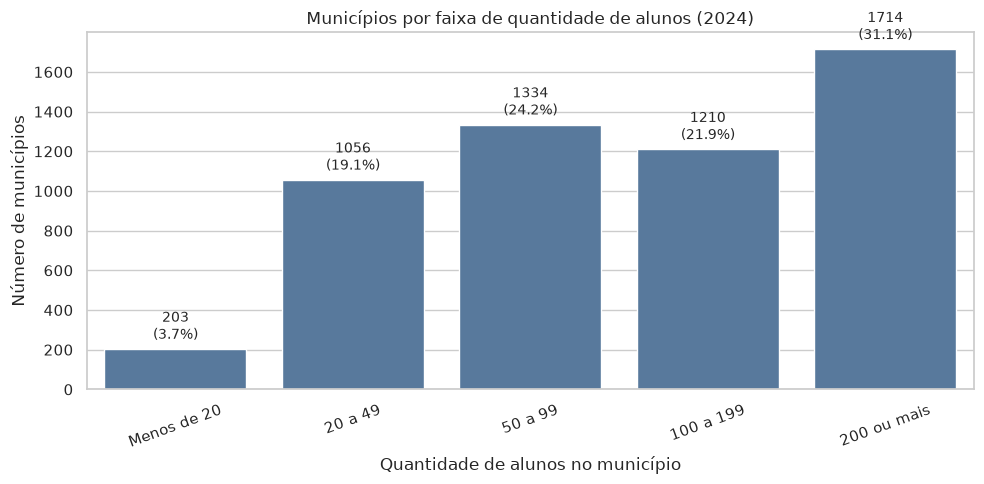

22.8% dos municípios possuem menos de 50 alunos.


3937

In [73]:
# ------------------------------------------------------------
# Verificação 9 — Municípios por faixa de quantidade de alunos
# ------------------------------------------------------------

alunos_por_municipio = (
    auditoria
    .groupby(['ano', 'id_municipio'], observed=True)
    .agg(
        alunos=(ALVO_CLASSIFICACAO, 'size'),
        taxa_alfabetizacao=(ALVO_CLASSIFICACAO, 'mean')
    )
    .reset_index()
)

# Mantém apenas o ano analisado
recorte = alunos_por_municipio[
    alunos_por_municipio['ano'].eq(ANO_ANALISE)
].copy()

# Define faixas fáceis de interpretar
faixas = [0, 20, 50, 100, 200, float('inf')]
rotulos = [
    'Menos de 20',
    '20 a 49',
    '50 a 99',
    '100 a 199',
    '200 ou mais'
]

recorte['faixa_alunos'] = pd.cut(
    recorte['alunos'],
    bins=faixas,
    labels=rotulos,
    right=False
)

# Conta municípios por faixa
distribuicao = (
    recorte['faixa_alunos']
    .value_counts(sort=False)
    .rename('municipios')
    .reset_index()
)

distribuicao['percentual'] = (
    distribuicao['municipios']
    / distribuicao['municipios'].sum()
    * 100
)

print(f'Distribuição dos municípios por quantidade de alunos ({ANO_ANALISE})')
display(
    distribuicao.style.format({
        'percentual': '{:.1f}%'
    })
)

# Gráfico
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=distribuicao,
    x='faixa_alunos',
    y='municipios',
    color='#4C78A8'
)

plt.title(
    f'Municípios por faixa de quantidade de alunos ({ANO_ANALISE})'
)
plt.xlabel('Quantidade de alunos no município')
plt.ylabel('Número de municípios')
plt.xticks(rotation=20)

# Exibe os valores sobre as barras
for barra, percentual in zip(
    ax.patches,
    distribuicao['percentual']
):
    altura = barra.get_height()

    ax.annotate(
        f'{int(altura)}\n({percentual:.1f}%)',
        xy=(
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 4),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

percentual_menos_50 = (
    recorte['alunos'].lt(50).mean() * 100
)

print(
    f'{percentual_menos_50:.1f}% dos municípios '
    f'possuem menos de 50 alunos.'
)

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


Em 2024, a maior parte dos municípios está concentrada na faixa de 200 ou mais. Além disso, 23% dos municípios possuem menos de 50 alunos, indicando que comparações diretas entre taxas municipais podem ser instáveis em parte dos municípios devido ao baixo tamanho da amostra.

Na etapa de modelagem, o desempenho dos modelos poderá ser avaliado separadamente por faixas de quantidade de alunos para verificar se as previsões são menos estáveis nos municípios com amostras menores.

### Verificação 11 — Distribuição das probabilidades

Antes de qualquer modelo, a base já fornece uma probabilidade observada: a **taxa empírica de alfabetização** de cada município, que é a proporção de alunos com `label_alfabetizado = 1`. Ela é o piso de comparação para o modelo e revela quanto de heterogeneidade real existe entre territórios.

A leitura só é honesta se separar dois componentes. Municípios com poucos alunos produzem taxas extremas — 0% ou 100% — por **ruído amostral**, não por desempenho. O desvio esperado apenas por amostragem é

$$
\sigma_{\text{ruído}} = \sqrt{\frac{\bar{p}\,(1 - \bar{p})}{n}}
$$

Comparar esse valor com o desvio observado entre municípios diz quanto da dispersão é sinal e quanto é artefato do tamanho da amostra.


Taxa de alfabetização por faixa de tamanho amostral (2024)


,faixa_alunos,municipios,taxa_media,taxa_mediana,taxa_minima,taxa_maxima,percentual_municipios
0,Menos de 20,203,66.0%,66.7%,0.0%,100.0%,3.7%
1,20 a 49,"1,056",66.2%,68.3%,4.0%,100.0%,19.1%
2,50 a 99,"1,334",65.0%,67.3%,11.3%,100.0%,24.2%
3,100 a 199,"1,210",62.3%,64.1%,15.8%,100.0%,21.9%
4,200 ou mais,"1,714",60.6%,60.6%,16.5%,100.0%,31.1%


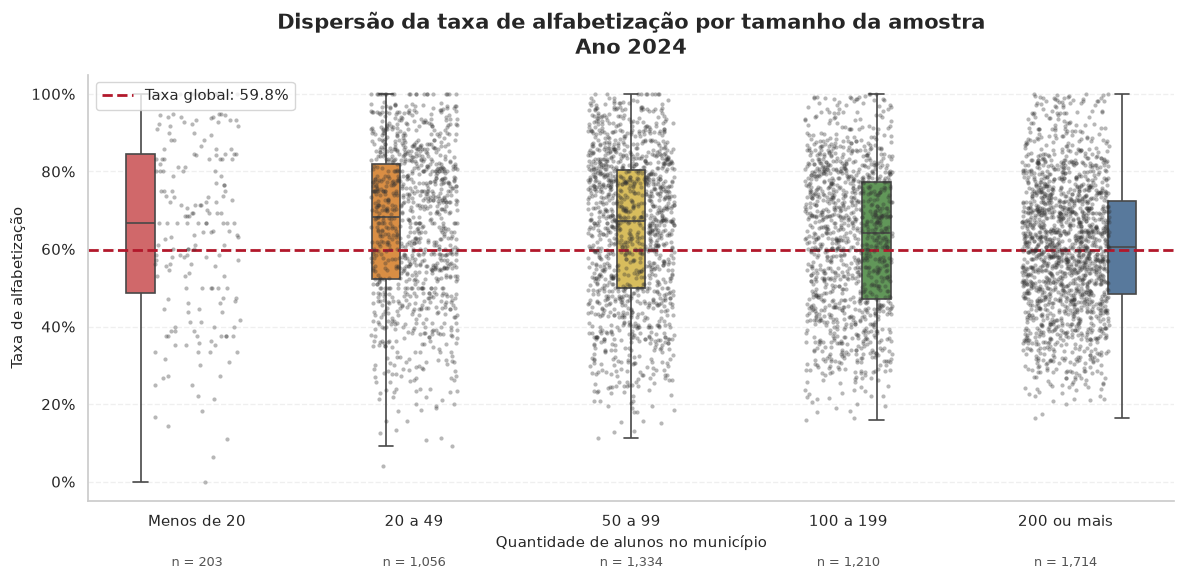

697

In [74]:
# ------------------------------------------------------------
# Verificação 11 — Taxa de alfabetização por tamanho da amostra
# ------------------------------------------------------------

# Tema visual
sns.set_theme(
    style='whitegrid',
    context='notebook'
)

probabilidades = alunos_por_municipio[
    alunos_por_municipio['ano'].eq(ANO_ANALISE)
].copy()

# Faixas de quantidade de alunos
faixas = [0, 20, 50, 100, 200, float('inf')]

rotulos = [
    'Menos de 20',
    '20 a 49',
    '50 a 99',
    '100 a 199',
    '200 ou mais'
]

probabilidades['faixa_alunos'] = pd.cut(
    probabilidades['alunos'],
    bins=faixas,
    labels=rotulos,
    right=False
)

# Taxa média global
taxa_global = auditoria.loc[
    auditoria['ano'].eq(ANO_ANALISE),
    ALVO_CLASSIFICACAO
].mean()

# Resumo por faixa
resumo = (
    probabilidades
    .groupby('faixa_alunos', observed=False)
    .agg(
        municipios=('id_municipio', 'count'),
        taxa_media=('taxa_alfabetizacao', 'mean'),
        taxa_mediana=('taxa_alfabetizacao', 'median'),
        taxa_minima=('taxa_alfabetizacao', 'min'),
        taxa_maxima=('taxa_alfabetizacao', 'max')
    )
    .reindex(rotulos)
    .reset_index()
)

resumo['percentual_municipios'] = (
    resumo['municipios']
    / resumo['municipios'].sum()
    * 100
)

print(
    f'Taxa de alfabetização por faixa de tamanho amostral '
    f'({ANO_ANALISE})'
)

display(
    resumo.style
    .format({
        'municipios': '{:,.0f}',
        'taxa_media': '{:.1%}',
        'taxa_mediana': '{:.1%}',
        'taxa_minima': '{:.1%}',
        'taxa_maxima': '{:.1%}',
        'percentual_municipios': '{:.1f}%'
    })
)

# Paleta de cores para as faixas
cores_faixas = {
    'Menos de 20': '#E15759',
    '20 a 49': '#F28E2B',
    '50 a 99': '#EDC948',
    '100 a 199': '#59A14F',
    '200 ou mais': '#4C78A8'
}

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot
sns.boxplot(
    data=probabilidades,
    x='faixa_alunos',
    y='taxa_alfabetizacao',
    order=rotulos,
    hue='faixa_alunos',
    palette=cores_faixas,
    legend=False,
    showfliers=False,
    width=0.65,
    linewidth=1.2,
    ax=ax
)

# Pontos individuais dos municípios
sns.stripplot(
    data=probabilidades,
    x='faixa_alunos',
    y='taxa_alfabetizacao',
    order=rotulos,
    color='#333333',
    alpha=0.35,
    size=3,
    jitter=0.2,
    ax=ax
)

# Linha da taxa global
ax.axhline(
    taxa_global,
    color='#B2182B',
    linestyle='--',
    linewidth=2,
    label=f'Taxa global: {taxa_global:.1%}'
)

# Título e eixos
ax.set_title(
    f'Dispersão da taxa de alfabetização por tamanho da amostra\n'
    f'Ano {ANO_ANALISE}',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Quantidade de alunos no município',
    fontsize=11
)

ax.set_ylabel(
    'Taxa de alfabetização',
    fontsize=11
)

# Formatação do eixo Y como percentual
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda valor, pos: f'{valor:.0%}')
)

ax.set_ylim(-0.05, 1.05)

# Quantidade de municípios abaixo dos rótulos
for posicao, (_, linha) in enumerate(resumo.iterrows()):
    if pd.notna(linha['municipios']):
        ax.text(
            posicao,
            -0.13,
            f'n = {int(linha["municipios"]):,}',
            ha='center',
            va='top',
            fontsize=9,
            color='#555555',
            transform=ax.get_xaxis_transform()
        )

# Ajustes visuais
ax.legend(
    loc='upper left',
    frameon=True
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


**Interpretação — taxa de alfabetização por tamanho da amostra**

A distribuição indica dois efeitos relevantes. Primeiro, municípios com poucos alunos apresentam resultados mais extremos, o que é compatível com maior variabilidade amostral quando o número de avaliados é pequeno.

Segundo, observa-se uma redução da taxa média de alfabetização conforme aumenta o número de alunos: de aproximadamente 66% nas menores faixas para 60,6% nos municípios com 200 ou mais alunos. Portanto, as diferenças entre as faixas não devem ser atribuídas apenas à instabilidade amostral; o tamanho do município também está associado ao nível observado de alfabetização.

Esses resultados não justificam excluir municípios pequenos. A modelagem deve manter a granularidade município-ano e considerar que o target possui precisão diferente conforme o número de alunos avaliados. Posteriormente, o desempenho dos modelos pode ser avaliado por faixas de tamanho para verificar sua robustez nos municípios com menor amostra.


### Síntese da auditoria e decisões registradas

| # | Verificação | Resultado | Decisão |
|---|---|---|---|
| 1 | Duplicidades | `ano + id_aluno` única em todos os anos; nenhuma linha idêntica | Granularidade aluno-ano confirmada |
| 1b | Natureza de `id_aluno` | Sequencial por UF, recriado a cada edição | Não usar como grupo em CV nem como histórico longitudinal |
| 2 | Valores ausentes | Ausências estruturais e por bloco | Remover features com >10% de nulos em 2024; imputar somente os nulos remanescentes dentro do `Pipeline` |
| 3 | Targets inválidos | Alvos íntegros | Alvos nunca entram na matriz de features |
| 4 | Municípios sem meta | Meta ausente em pequena parcela de 2024/2025 | Não imputar meta como zero; tratar ausência conforme o alvo utilizado |
| 5 | Features constantes | Nenhuma constante relevante em 2024/2025 | Não aplicar exclusão adicional por constância |
| 6 | Leakage | Sem vazamento aparente nas features contextuais mantidas | Reconfirmar após o treino |
| 6b | Redundância | Componentes produzidos por Spearman municipal | `|ρ| ≥ 0,90`; manter um representante por componente com regra explícita |
| 6c | `nivel_lag1 × taxa_lag1` | Diagnóstico reproduzido para 2024/2025 antes do `drop()` | Manter `taxa_lag1` quando concordância/cobertura confirmarem redundância |
| 7 | Inconsistências de ano | Coluna `ano` coerente com as partições | Corte temporal seguro |
| 8 | Cobertura de municípios | Maioria dos municípios presente nos anos comparáveis | Avaliar municípios inéditos no teste |
| 9 | Alunos por município | Tamanhos muito diferentes | Considerar tamanho amostral ao interpretar rankings |
| 10-11 | Distribuições | Ver seções específicas | Métricas e limiares definidos na validação |


## 3. Alvos e prevenção de vazamento

`label_alfabetizado` é uma classificação derivada de `label_proficiencia` a partir de um ponto de corte. Portanto, esses dois alvos carregam a mesma informação em formatos diferentes e jamais podem coexistir na matriz de atributos.


In [75]:
corte = df.loc[df[ALVO_CLASSIFICACAO].eq(1), ALVO_REGRESSAO].min()
identidade = df[ALVO_REGRESSAO].ge(corte).astype(int).eq(df[ALVO_CLASSIFICACAO].astype(int))

print(f'Corte de alfabetização: {corte:.0f} pontos')
print(f'Concordância entre os alvos: {identidade.mean() * 100:.4f}%')
print(f'Divergências: {(~identidade).sum():,}')

Corte de alfabetização: 743 pontos
Concordância entre os alvos: 100.0000%
Divergências: 0


### Decisão de modelagem — leakage

- Usar somente informações disponíveis antes do resultado que se quer prever.
- `taxa_lag1` permanece como feature histórica de desempenho.
- `nivel_lag1` foi removida por redundância com `taxa_lag1`.
- `taxa_realizada`, `nivel_realizado`, `proficiencia_media` e derivados do resultado corrente não podem ser features para prever o próprio ano.
- Alvos individuais (`label_alfabetizado`, `label_proficiencia`) não entram como atributos.
- Desempenho quase perfeito deve ser investigado como possível vazamento antes de ser interpretado como bom modelo.


## 4. Estatística descritiva, nulos e escalas

Esta etapa mostra magnitude, dispersão, extremos e assimetria. Ela é particularmente importante porque os indicadores vêm de fontes diferentes: uma taxa pode estar em fração `[0, 1]`, enquanto outra está em percentual `[0, 100]`.


In [76]:
# Variáveis de contexto
variaveis_contexto = [
    coluna for coluna in df.columns
    if coluna.startswith('ctx_')
]

# Mantém apenas as variáveis numéricas
contexto_numerico = df[variaveis_contexto].select_dtypes(
    include='number'
)

# Estatísticas descritivas
descritiva = (
    contexto_numerico
    .describe()
    .T
    .rename(columns={
        'mean': 'Média',
        'std': 'Desvio-padrão',
        'min': 'Mínimo',
        '50%': 'Mediana',
        'max': 'Máximo'
    })
)

descritiva['Nulos (%)'] = (
    contexto_numerico.isna().mean() * 100
)

descritiva['Assimetria'] = contexto_numerico.skew()

# Classificação simples da assimetria
def classificar_assimetria(valor):
    if pd.isna(valor):
        return 'Não calculada'
    elif abs(valor) < 0.5:
        return 'Baixa'
    elif abs(valor) < 1:
        return 'Moderada'
    else:
        return 'Alta'

descritiva['Interpretação da assimetria'] = (
    descritiva['Assimetria']
    .apply(classificar_assimetria)
)

# Ordena pelas variáveis mais assimétricas
descritiva_ordenada = (
    descritiva
    .sort_values(
        'Assimetria',
        key=lambda coluna: coluna.abs(),
        ascending=False
    )
    .head(20)
)

print(
    f'Variáveis numéricas de contexto: '
    f'{contexto_numerico.shape[1]}'
)
print(
    f'Observações analisadas: '
    f'{contexto_numerico.shape[0]:,}'
)
print('\nVariáveis com maior assimetria:')

display(
    descritiva_ordenada.style
    .format({
        'Média': '{:,.2f}',
        'Desvio-padrão': '{:,.2f}',
        'Mínimo': '{:,.2f}',
        'Mediana': '{:,.2f}',
        'Máximo': '{:,.2f}',
        'Nulos (%)': '{:.2f}%',
        'Assimetria': '{:.2f}'
    })
    .background_gradient(
        subset=['Assimetria'],
        cmap='RdYlBu_r'
    )
    .background_gradient(
        subset=['Nulos (%)'],
        cmap='Reds'
    )
)


Variáveis numéricas de contexto: 37
Observações analisadas: 1,851,828

Variáveis com maior assimetria:


,count,Média,Desvio-padrão,Mínimo,25%,Mediana,75%,Máximo,Nulos (%),Assimetria,Interpretação da assimetria
ctx_ibge_area_km2,1851828.000000,"2,476.39","7,958.20",3.56,301.865000,693.44,1521.202000,"159,533.31",0.00%,11.36,Alta
ctx_atlas_taxa_fora_escola_6a14,1851186.000000,3.20,2.02,0.00,2.150000,2.92,3.890000,48.23,0.03%,5.37,Alta
ctx_atlas_percentual_domicilios_energia,1851186.000000,98.44,4.34,41.83,99.190000,99.82,99.950000,100.00,0.03%,-5.03,Alta
ctx_ibge_populacao_residente,1851828.000000,"1,100,852.70","2,747,438.16",854.00,31314.000000,"119,172.00",507838.000000,"11,895,578.00",0.00%,3.26,Alta
ctx_atlas_taxa_analfabetismo_15a17,1851186.000000,2.04,1.97,0.00,0.940000,1.23,2.390000,30.69,0.03%,3.11,Alta
ctx_atlas_taxa_analfabetismo_11a14,1851186.000000,2.93,2.97,0.00,1.230000,1.69,3.310000,34.67,0.03%,2.80,Alta
ctx_atlas_taxa_trabalho_infantil_10a14,1851186.000000,7.43,4.84,0.00,4.670000,5.79,8.700000,72.55,0.03%,2.63,Alta
ctx_atlas_percentual_domicilios_agua,1851186.000000,91.78,11.57,0.15,89.650000,96.69,98.980000,100.00,0.03%,-2.61,Alta
ctx_atlas_taxa_maes_10a14,1851186.000000,0.43,0.45,0.00,0.000000,0.38,0.570000,8.38,0.03%,2.54,Alta
ctx_atlas_taxa_frequencia_liquida_fundamental,1851186.000000,92.11,2.44,47.92,90.770000,92.27,93.660000,100.00,0.03%,-2.24,Alta


### Implicações para o preprocessing posterior

A tabela descritiva acima identifica variáveis assimétricas; a seção de transformação logarítmica mede posteriormente se `log1p` reduz essa assimetria.

Nesta EDA ficam registrados apenas princípios que evitam leakage:

- imputação e qualquer transformação aprendida devem ser ajustadas **somente no treino**;
- padronização será aplicada apenas aos modelos que dela se beneficiam, como regressões regularizadas, SVM e KNN;
- modelos de árvores não exigem padronização para construir suas divisões.

A escolha final de imputador, scaler e transformação pertence ao notebook de modelagem e será validada empiricamente no pipeline.


## 5. Distribuição dos alvos e métricas

A classificação deve considerar o custo de errar alunos não alfabetizados. Por isso, não basta observar a acurácia.


Distribuição da classificação:


,quantidade,percentual
Não alfabetizado,"744,725",40.2%
Alfabetizado,"1,107,103",59.8%


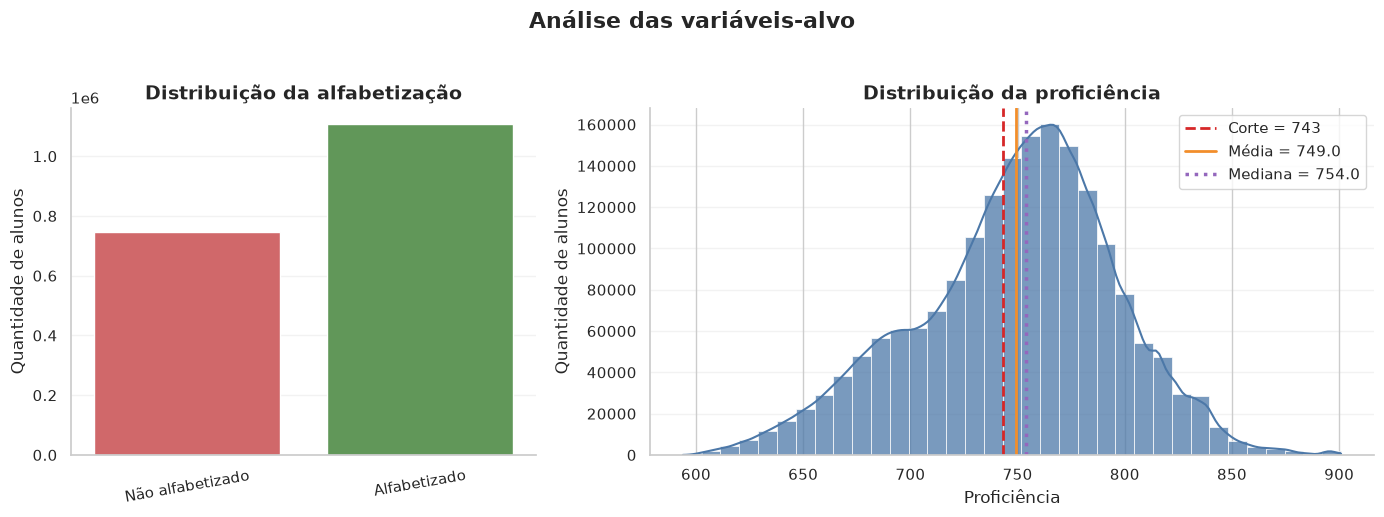

In [77]:
# ------------------------------------------------------------
# Distribuição das variáveis-alvo
# ------------------------------------------------------------

# Estilo visual
sns.set_theme(
    style='whitegrid',
    context='notebook',
    palette='deep'
)

# Tabela de distribuição da classificação
dist_alvo = (
    df[ALVO_CLASSIFICACAO]
    .value_counts(dropna=False)
    .sort_index()
    .rename('quantidade')
    .to_frame()
)

dist_alvo['percentual'] = (
    dist_alvo['quantidade']
    / dist_alvo['quantidade'].sum()
    * 100
)

# Rótulos mais fáceis de interpretar
rotulos_classificacao = {
    0: 'Não alfabetizado',
    1: 'Alfabetizado'
}

dist_alvo.index = [
    rotulos_classificacao.get(valor, 'Nulo')
    for valor in dist_alvo.index
]

print('Distribuição da classificação:')
display(
    dist_alvo.style.format({
        'quantidade': '{:,.0f}',
        'percentual': '{:.1f}%'
    })
)

# Dados para o gráfico de classificação
dados_classificacao = df[[ALVO_CLASSIFICACAO]].copy()

dados_classificacao['classificacao'] = (
    dados_classificacao[ALVO_CLASSIFICACAO]
    .map(rotulos_classificacao)
    .fillna('Nulo')
)

ordem_classificacao = [
    'Não alfabetizado',
    'Alfabetizado',
    'Nulo'
]

ordem_classificacao = [
    categoria for categoria in ordem_classificacao
    if categoria in dados_classificacao['classificacao'].unique()
]

# Estatísticas da proficiência
media_proficiencia = df[ALVO_REGRESSAO].mean()
mediana_proficiencia = df[ALVO_REGRESSAO].median()

# Criação dos gráficos
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [0.9, 1.4]}
)

# ------------------------------------------------------------
# Gráfico 1 — Classificação
# ------------------------------------------------------------

ax = sns.countplot(
    data=dados_classificacao,
    x='classificacao',
    order=ordem_classificacao,
    palette={
        'Não alfabetizado': '#E15759',
        'Alfabetizado': '#59A14F',
        'Nulo': '#9D9D9D'
    },
    hue='classificacao',
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    'Distribuição da alfabetização',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade de alunos')
axes[0].tick_params(axis='x', rotation=10)


# ------------------------------------------------------------
# Gráfico 2 — Proficiência
# ------------------------------------------------------------

sns.histplot(
    data=df,
    x=ALVO_REGRESSAO,
    bins=35,
    kde=True,
    color='#4C78A8',
    alpha=0.75,
    edgecolor='white',
    linewidth=0.5,
    ax=axes[1]
)

axes[1].axvline(
    corte,
    color='#D62728',
    linestyle='--',
    linewidth=2,
    label=f'Corte = {corte:.0f}'
)

axes[1].axvline(
    media_proficiencia,
    color='#F28E2B',
    linestyle='-',
    linewidth=2,
    label=f'Média = {media_proficiencia:.1f}'
)

axes[1].axvline(
    mediana_proficiencia,
    color='#9467BD',
    linestyle=':',
    linewidth=2.5,
    label=f'Mediana = {mediana_proficiencia:.1f}'
)

axes[1].set_title(
    'Distribuição da proficiência',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('Proficiência')
axes[1].set_ylabel('Quantidade de alunos')
axes[1].legend(frameon=True)

# Ajustes finais
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.25)

plt.suptitle(
    'Análise das variáveis-alvo',
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()


### Decisão de modelagem — avaliação

Como há desbalanceamento moderado, o primeiro treino pode dispensar reamostragem. Entretanto, a avaliação deve incluir:

- **Classificação:** precision, recall, F1-score, PR-AUC, ROC-AUC, matriz de confusão e calibração.
- **Regressão:** MAE, RMSE, $R^2$ e análise dos resíduos.

Se o objetivo for identificar alunos prioritários para intervenção, o limiar de probabilidade deve ser escolhido considerando o **recall da classe não alfabetizada**, não somente o valor padrão de $0,5$.


### 5.1 Avaliação da `label_alfabetizado`

A célula acima mostra a distribuição do alvo em 2024. Esta subseção completa a avaliação da variável de classificação: como ela se distribui **globalmente e por ano**, como varia **por rede, UF e região**, e o quanto cada bloco de features realmente separa as duas classes.

A ordem é deliberada. Primeiro medimos a separação com testes estatísticos e tamanho de efeito; só depois plotamos — assim os boxplots mostram as variáveis que importam, e não as 76 disponíveis.


Distribuição da label_alfabetizado — série completa


,quantidade,percentual
classe_alfabetizacao,,
Não alfabetizado,"2,033,517",38.2%
Alfabetizado,"3,287,215",61.8%



Razão de desbalanceamento (classe maior / classe menor): 1.62
Alvos nulos: 0


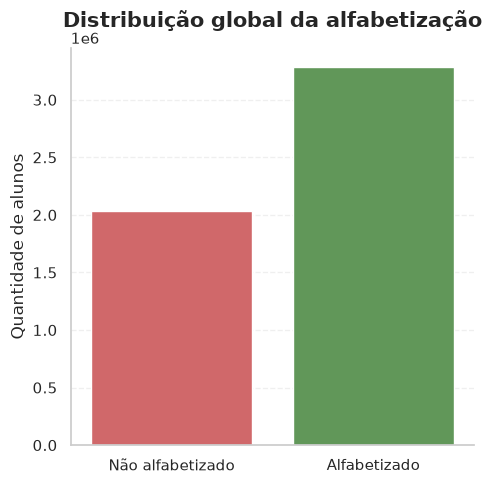

In [78]:
# ------------------------------------------------------------
# Distribuição global da label_alfabetizado
# ------------------------------------------------------------

sns.set_theme(
    style='whitegrid',
    context='notebook'
)

ROTULOS_ALVO = {
    0: 'Não alfabetizado',
    1: 'Alfabetizado'
}

# Cria uma coluna com rótulos mais amigáveis
auditoria_plot = auditoria.copy()

auditoria_plot['classe_alfabetizacao'] = (
    auditoria_plot[ALVO_CLASSIFICACAO]
    .map(ROTULOS_ALVO)
    .fillna('Nulo')
)

ordem_classes = [
    'Não alfabetizado',
    'Alfabetizado',
    'Nulo'
]

# Mantém somente categorias existentes
ordem_classes = [
    classe for classe in ordem_classes
    if classe in auditoria_plot['classe_alfabetizacao'].unique()
]

# Tabela de distribuição
distribuicao_global = (
    auditoria_plot['classe_alfabetizacao']
    .value_counts()
    .reindex(ordem_classes, fill_value=0)
    .rename('quantidade')
    .to_frame()
)

distribuicao_global['percentual'] = (
    distribuicao_global['quantidade']
    / distribuicao_global['quantidade'].sum()
    * 100
)

print('Distribuição da label_alfabetizado — série completa')

display(
    distribuicao_global.style
    .format({
        'quantidade': '{:,.0f}',
        'percentual': '{:.1f}%'
    })
)

# Razão de desbalanceamento entre as classes válidas
classes_validas = distribuicao_global.loc[
    ['Não alfabetizado', 'Alfabetizado']
].copy()

quantidade_maior = classes_validas['quantidade'].max()
quantidade_menor = classes_validas['quantidade'].min()

razao = quantidade_maior / quantidade_menor

quantidade_nulos = (
    auditoria_plot['classe_alfabetizacao']
    .eq('Nulo')
    .sum()
)

print(
    f'\nRazão de desbalanceamento '
    f'(classe maior / classe menor): {razao:.2f}'
)

print(f'Alvos nulos: {quantidade_nulos:,}')

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

cores_classes = {
    'Não alfabetizado': '#E15759',
    'Alfabetizado': '#59A14F',
    'Nulo': '#9D9D9D'
}

fig, ax = plt.subplots(figsize=(5, 5))

sns.countplot(
    data=auditoria_plot,
    x='classe_alfabetizacao',
    order=ordem_classes,
    hue='classe_alfabetizacao',
    palette=cores_classes,
    legend=False,
    ax=ax
)


ax.set_title(
    'Distribuição global da alfabetização',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('')
ax.set_ylabel('Quantidade de alunos')

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


Frequência absoluta por ano


label_alfabetizado,0,1
ano,,
2023,625382,877427
2024,744725,1107103
2025,663410,1302685



Frequência relativa (%) por ano


label_alfabetizado,0,1
ano,,
2023,41.610,58.390
2024,40.220,59.780
2025,33.740,66.260



Razão de desbalanceamento por ano


,razao_maior_sobre_menor
ano,
2023,1.400
2024,1.490
2025,1.960


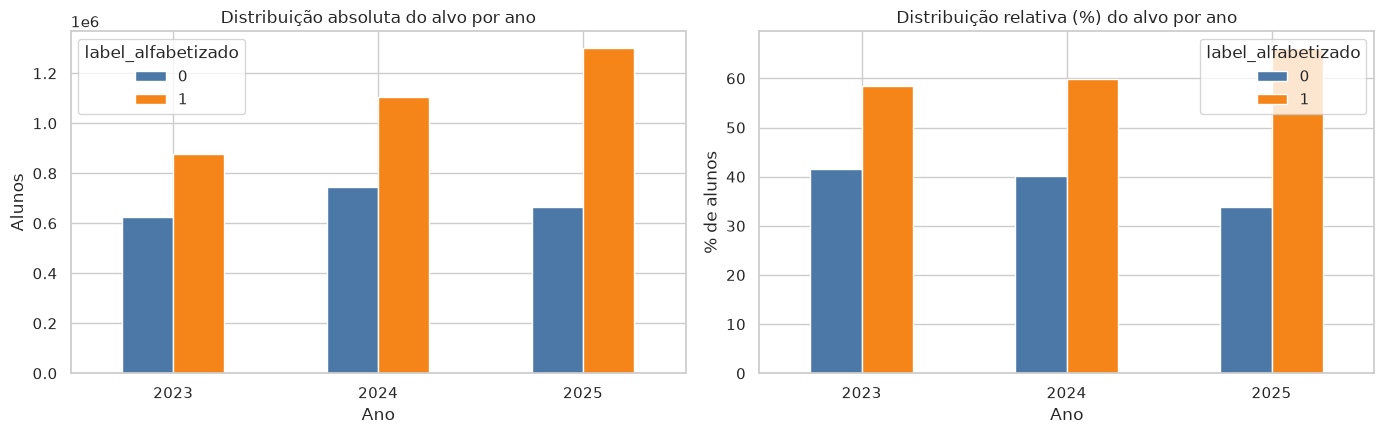

25151

In [79]:
# ------------------------------------------------------------
# Distribuição da label_alfabetizado por ano (barras lado a lado)
# ------------------------------------------------------------

distribuicao_ano_abs = (
    auditoria.groupby('ano', observed=True)[ALVO_CLASSIFICACAO]
    .value_counts(dropna=False)
    .unstack()
    .fillna(0)
    .astype(int)
)

distribuicao_ano_rel = (
    auditoria.groupby('ano', observed=True)[ALVO_CLASSIFICACAO]
    .value_counts(normalize=True, dropna=False)
    .unstack()
    .fillna(0)
    .mul(100)
    .round(2)
)

print('Frequência absoluta por ano')
display(distribuicao_ano_abs)

print('\nFrequência relativa (%) por ano')
display(distribuicao_ano_rel)

print('\nRazão de desbalanceamento por ano')
display(
    (distribuicao_ano_abs.max(axis=1) / distribuicao_ano_abs.min(axis=1))
    .round(2)
    .rename('razao_maior_sobre_menor')
    .to_frame()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

distribuicao_ano_abs.plot(
    kind='bar', stacked=False, color=['#4C78A8', '#F58518'], ax=axes[0],
)
axes[0].set_title('Distribuição absoluta do alvo por ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Alunos')
axes[0].legend(title=ALVO_CLASSIFICACAO)
axes[0].tick_params(axis='x', rotation=0)

distribuicao_ano_rel.plot(
    kind='bar', stacked=False, color=['#4C78A8', '#F58518'], ax=axes[1],
)
axes[1].set_title('Distribuição relativa (%) do alvo por ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('% de alunos')
axes[1].legend(title=ALVO_CLASSIFICACAO)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


**Leitura — prevalência móvel**

A proporção de alfabetizados sobe de 58,4% (2023) para 59,8% (2024) e 66,3% (2025). O desbalanceamento é moderado — a razão entre classes vai de 1,4 a 2,0 — e não exige reamostragem no primeiro treino.

O ponto relevante para o desenho de validação é outro: **a prevalência do alvo muda entre treino (2024) e teste (2025)**. Um modelo calibrado em 2024 tende a subestimar sistematicamente a probabilidade de alfabetização em 2025. Isso torna obrigatórias duas coisas na avaliação final: a curva de calibração no ano de teste e a escolha do limiar na validação, não no padrão de 0,5.


#### Distribuição do alvo por rede, UF e região

A `dependencia_administrativa` é a única coluna da base que descreve o aluno; UF e região descrevem o território. Vale medir quanto de variação cada recorte carrega, porque isso antecipa onde o modelo pode errar de forma sistemática.


Por dependência administrativa — 2024 (2 = estadual, 3 = municipal)


,alunos,alfabetizados,taxa_alfabetizacao
dependencia_administrativa,,,
2,241074,150760,62.540
3,1610754,956343,59.370



Por região — 2024


,alunos,alfabetizados,taxa_alfabetizacao
regiao,,,
Centro-Oeste,175205,113353,64.700
Sudeste,744637,463862,62.290
Sul,278403,169753,60.970
Nordeste,465488,264668,56.860
Norte,188095,95467,50.750



Por UF — 2024


,alunos,alfabetizados,taxa_alfabetizacao
uf,,,
CE,88158,75223,85.330
GO,70799,51698,73.020
MG,180771,131226,72.590
ES,42751,30818,72.090
PR,119806,84819,70.800
SC,69035,43941,63.650
RO,20027,12621,63.020
PE,75953,46385,61.070
MT,45083,27488,60.970



Taxa de alfabetização (%) por rede e ano


dependencia_administrativa,2,3
ano,,
2023,61.330,58.100
2024,62.540,59.370
2025,64.670,66.480



Amplitude entre UFs .: 49.4 pontos percentuais
Amplitude entre redes: 3.2 pontos percentuais


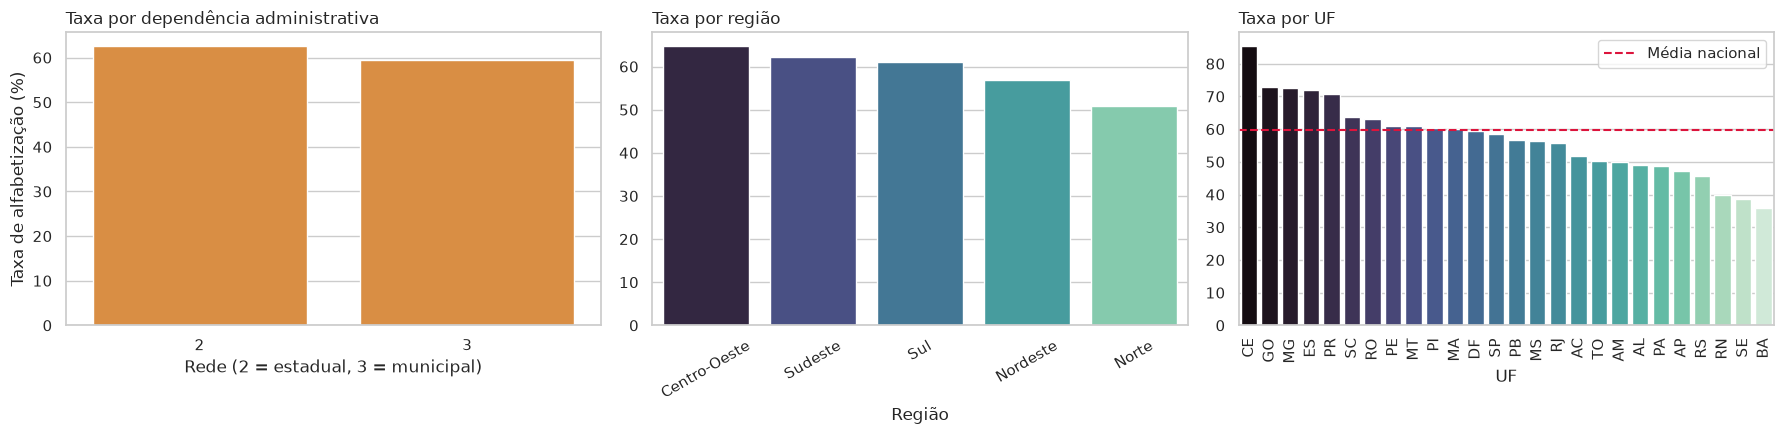

16430

In [80]:
# ------------------------------------------------------------
# label_alfabetizado por dependência administrativa, UF e região
# ------------------------------------------------------------

auditoria['uf'] = auditoria['id_uf'].map(mapa_sigla_uf)
auditoria['regiao'] = auditoria['id_uf'].map(mapa_regiao_uf)

def taxa_por_grupo(dados, coluna_grupo):
    """Alunos, alfabetizados e taxa (%) por grupo."""
    resultado = (
        dados.groupby(coluna_grupo, observed=True)
        .agg(
            alunos=(ALVO_CLASSIFICACAO, 'size'),
            alfabetizados=(ALVO_CLASSIFICACAO, 'sum'),
            taxa_alfabetizacao=(ALVO_CLASSIFICACAO, 'mean'),
        )
    )
    resultado['taxa_alfabetizacao'] = (resultado['taxa_alfabetizacao'] * 100).round(2)
    return resultado.sort_values('taxa_alfabetizacao', ascending=False)

recorte_ano = auditoria[auditoria['ano'].eq(ANO_ANALISE)]

print(f'Por dependência administrativa — {ANO_ANALISE} (2 = estadual, 3 = municipal)')
display(taxa_por_grupo(recorte_ano, 'dependencia_administrativa'))

print(f'\nPor região — {ANO_ANALISE}')
por_regiao = taxa_por_grupo(recorte_ano, 'regiao')
display(por_regiao)

print(f'\nPor UF — {ANO_ANALISE}')
por_uf = taxa_por_grupo(recorte_ano, 'uf')
display(por_uf)

print('\nTaxa de alfabetização (%) por rede e ano')
display(
    auditoria.pivot_table(
        index='ano', columns='dependencia_administrativa',
        values=ALVO_CLASSIFICACAO, aggfunc='mean', observed=True,
    ).mul(100).round(2)
)

amplitude_uf = por_uf['taxa_alfabetizacao'].max() - por_uf['taxa_alfabetizacao'].min()
amplitude_rede = (
    taxa_por_grupo(recorte_ano, 'dependencia_administrativa')['taxa_alfabetizacao'].max()
    - taxa_por_grupo(recorte_ano, 'dependencia_administrativa')['taxa_alfabetizacao'].min()
)
print(f'\nAmplitude entre UFs .: {amplitude_uf:.1f} pontos percentuais')
print(f'Amplitude entre redes: {amplitude_rede:.1f} pontos percentuais')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.barplot(
    data=taxa_por_grupo(recorte_ano, 'dependencia_administrativa').reset_index(),
    x='dependencia_administrativa', y='taxa_alfabetizacao',
    color='#F28E2B', ax=axes[0],
)
axes[0].set_title('Taxa por dependência administrativa', loc='left')
axes[0].set_xlabel('Rede (2 = estadual, 3 = municipal)')
axes[0].set_ylabel('Taxa de alfabetização (%)')

sns.barplot(
    data=por_regiao.reset_index(), x='regiao', y='taxa_alfabetizacao',
    palette='mako', ax=axes[1],
)
axes[1].set_title('Taxa por região', loc='left')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(
    data=por_uf.reset_index(), x='uf', y='taxa_alfabetizacao',
    palette='mako', ax=axes[2],
)
axes[2].axhline(
    recorte_ano[ALVO_CLASSIFICACAO].mean() * 100,
    color='crimson', linestyle='--', label='Média nacional',
)
axes[2].set_title('Taxa por UF', loc='left')
axes[2].set_xlabel('UF')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=90)
axes[2].legend()

plt.tight_layout()
plt.show()

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


#### Separação das classes por feature — significância e tamanho de efeito

Com quase 1,9 milhão de linhas, praticamente qualquer diferença vira estatisticamente significativa. Reportar apenas o p-valor levaria à conclusão errada de que quase todas as variáveis "importam".

Por isso cada feature recebe três medidas:

- **Mann-Whitney U** — teste não paramétrico, sem hipótese de normalidade;
- **teste t de Welch** — comparação de médias sem exigir variâncias iguais;
- **correlação rank-biserial** — o tamanho de efeito derivado do próprio U:

$$
r_{rb} = \frac{2U}{n_0 \, n_1} - 1
$$

O `\|r_{rb}\|` varia de 0 (nenhuma separação) a 1 (separação total) e é o critério de ordenação — o p-valor apenas confirma que a diferença não é acaso.


In [81]:
# ------------------------------------------------------------
# Testes de separação das classes por feature (ano de análise)
# ------------------------------------------------------------

from scipy.stats import mannwhitneyu, ttest_ind

MINIMO_POR_GRUPO = 30

colunas_contexto = [c for c in df.columns if c.startswith('ctx_')]

# Máscaras calculadas uma única vez, em numpy: evita recortar o DataFrame
# 76 vezes (cada recorte copiaria ~1,8M linhas).
eh_nao_alfabetizado = df[ALVO_CLASSIFICACAO].eq(0).to_numpy()
eh_alfabetizado = df[ALVO_CLASSIFICACAO].eq(1).to_numpy()

resultados = []
for coluna in colunas_contexto:
    valores = df[coluna].to_numpy(dtype='float64', na_value=np.nan)
    grupo_0 = valores[eh_nao_alfabetizado]
    grupo_1 = valores[eh_alfabetizado]
    grupo_0 = grupo_0[~np.isnan(grupo_0)]
    grupo_1 = grupo_1[~np.isnan(grupo_1)]

    if len(grupo_0) < MINIMO_POR_GRUPO or len(grupo_1) < MINIMO_POR_GRUPO:
        continue

    estatistica_u, p_mannwhitney = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
    _, p_welch = ttest_ind(grupo_0, grupo_1, equal_var=False)

    # Correlação rank-biserial: tamanho de efeito derivado do U.
    # Sinal positivo => valores maiores na classe 1 (alfabetizado).
    rank_biserial = 1 - 2 * estatistica_u / (len(grupo_0) * len(grupo_1))

    resultados.append({
        'feature': coluna,
        'fonte': coluna.split('_')[1],
        'n_nao_alfabetizado': len(grupo_0),
        'n_alfabetizado': len(grupo_1),
        'media_nao_alfabetizado': grupo_0.mean(),
        'media_alfabetizado': grupo_1.mean(),
        'diferenca_de_medias': grupo_1.mean() - grupo_0.mean(),
        'corr_rank_biserial': rank_biserial,
        'p_mannwhitney': p_mannwhitney,
        'p_welch': p_welch,
    })

separacao = pd.DataFrame(resultados)
separacao['efeito_abs'] = separacao['corr_rank_biserial'].abs()
separacao = separacao.sort_values('efeito_abs', ascending=False).reset_index(drop=True)

significativas = int((separacao['p_mannwhitney'] < 0.05).sum())
print(f'Ano avaliado: {ANO_ANALISE} | features testadas: {len(separacao)}')
print(f'Significativas a 5% (Mann-Whitney): {significativas} de {len(separacao)}')
print(f'Maior tamanho de efeito |r_rb|: {separacao["efeito_abs"].max():.3f}')
print(f'Features com |r_rb| >= 0,10: {int(separacao["efeito_abs"].ge(0.10).sum())}')

print('\nTop 15 features por tamanho de efeito')
display(
    separacao.head(15)[[
        'feature', 'media_nao_alfabetizado', 'media_alfabetizado',
        'diferenca_de_medias', 'corr_rank_biserial', 'p_mannwhitney',
    ]].round(4)
)

print('\nMenores tamanhos de efeito — significância sem relevância prática')
display(
    separacao.tail(5)[[
        'feature', 'diferenca_de_medias', 'corr_rank_biserial', 'p_mannwhitney',
    ]].round(6)
)

print('\nTamanho de efeito por fonte de dados')
display(
    separacao.groupby('fonte')['efeito_abs']
    .agg(features='size', efeito_mediano='median', efeito_maximo='max')
    .round(4)
    .sort_values('efeito_maximo', ascending=False)
)

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


Ano avaliado: 2024 | features testadas: 37
Significativas a 5% (Mann-Whitney): 36 de 37
Maior tamanho de efeito |r_rb|: 0.270
Features com |r_rb| >= 0,10: 8

Top 15 features por tamanho de efeito


,feature,media_nao_alfabetizado,media_alfabetizado,diferenca_de_medias,corr_rank_biserial,p_mannwhitney
0,ctx_inep_mun_media_portugues_lag1,738.561,748.279,9.718,0.270,0.000
1,ctx_inep_mun_taxa_alfabetizacao_lag1,51.197,58.702,7.505,0.264,0.000
2,ctx_inep_mun_meta,55.053,60.946,5.893,0.262,0.000
3,ctx_inep_uf_media_portugues_lag1,741.860,747.758,5.898,0.235,0.000
4,ctx_inep_mun_percentual_participacao_lag1,85.778,87.570,1.792,0.165,0.000
5,ctx_inep_uf_percentual_participacao_lag1,86.063,87.209,1.146,0.142,0.000
6,ctx_atlas_taxa_densidade_domiciliar,29.910,27.531,-2.379,-0.114,0.000
7,ctx_atlas_taxa_analfabetismo_11a14,3.187,2.763,-0.423,-0.108,0.000
8,ctx_atlas_taxa_fora_escola_6a14,3.349,3.102,-0.247,-0.096,0.000
9,ctx_atlas_taxa_analfabetismo_15a17,2.156,1.964,-0.191,-0.085,0.000



Menores tamanhos de efeito — significância sem relevância prática


,feature,diferenca_de_medias,corr_rank_biserial,p_mannwhitney
32,ctx_atu_creche,-0.138,-0.016,0.000
33,ctx_atu_fundamental_2_ano,-0.106,-0.013,0.000
34,ctx_atlas_taxa_analfabetismo_15mais,0.000,0.009,0.000
35,ctx_atu_fundamental_1_ano,-0.058,-0.005,0.000
36,ctx_fundeb_nse_uf,0.471,0.001,0.212



Tamanho de efeito por fonte de dados


,features,efeito_mediano,efeito_maximo
fonte,,,
inep,6,0.249,0.270
atlas,16,0.054,0.114
ibge,5,0.034,0.057
atu,9,0.021,0.028
fundeb,1,0.001,0.001


0

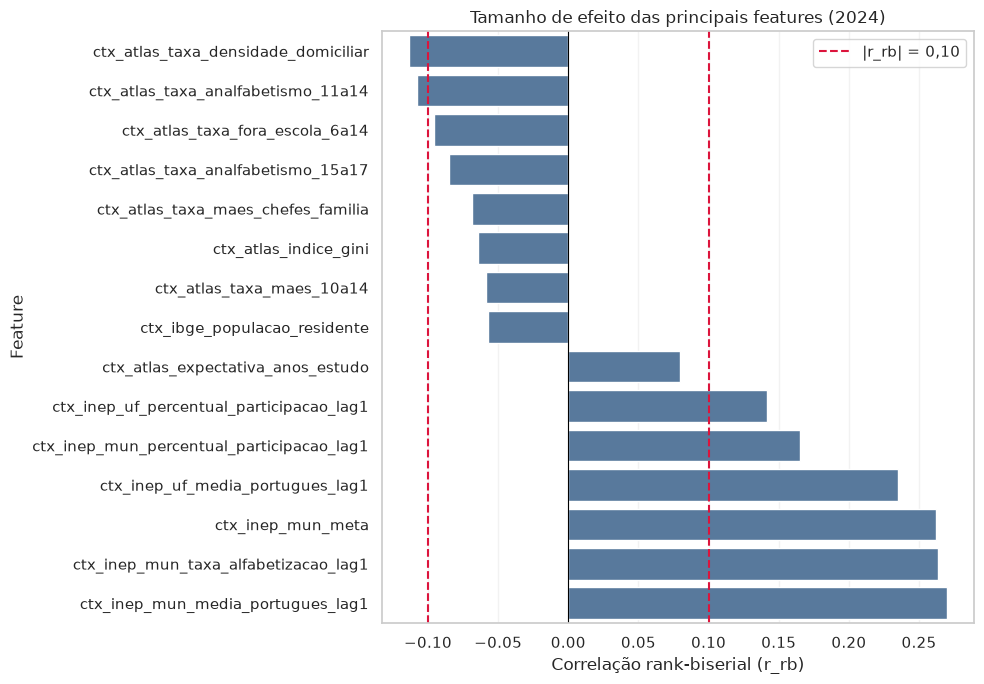

3271

In [82]:
# ------------------------------------------------------------
# Visualização — tamanho de efeito das principais features
# ------------------------------------------------------------

# 'resultados' foi construído como lista no loop anterior.
# Converte para DataFrame para análise e visualização.
resultados_df = pd.DataFrame(resultados)

# Calcula magnitude do efeito para ordenar as features
resultados_df['abs_efeito'] = (
    resultados_df['corr_rank_biserial'].abs()
)

# Seleciona as 15 maiores associações em magnitude
top_plot = (
    resultados_df
    .nlargest(15, 'abs_efeito')
    .sort_values('corr_rank_biserial')
    .copy()
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_plot,
    x='corr_rank_biserial',
    y='feature',
    color='#4C78A8'
)

# Limite adotado para destacar relevância prática
plt.axvline(
    0.10,
    color='crimson',
    linestyle='--',
    linewidth=1.5,
    label='|r_rb| = 0,10'
)

plt.axvline(
    -0.10,
    color='crimson',
    linestyle='--',
    linewidth=1.5
)

# Referência de efeito nulo
plt.axvline(
    0,
    color='black',
    linewidth=0.8
)

plt.title(
    f'Tamanho de efeito das principais features ({ANO_ANALISE})'
)
plt.xlabel('Correlação rank-biserial (r_rb)')
plt.ylabel('Feature')

plt.legend()
plt.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

# Libera objetos temporários
del top_plot, resultados_df
gc.collect()

**Decisão de modelagem — o que a avaliação do alvo determina**

1. **Nenhuma feature isolada separa as classes.** O maior tamanho de efeito é ~0,27, do desempenho municipal defasado do INEP. Um modelo linear simples sobre uma variável não resolve; o ganho, se existir, virá da combinação de features e de interações — o que justifica comparar um baseline linear com um modelo de árvores.

2. **Significância não é relevância.** Praticamente todas as features são significativas a 5%, e várias com `|r_rb|` abaixo de 0,01. O critério de seleção é o tamanho de efeito e a validação cruzada, nunca o p-valor.

3. **O contexto municipal é um teto, não um oráculo.** Todas as features descrevem o município ou a rede; nenhuma descreve o aluno. Dois alunos da mesma escola recebem exatamente o mesmo vetor de atributos. Isso limita estruturalmente a acurácia individual alcançável — e reforça que o resultado útil é a **priorização de territórios**, não a classificação de um aluno específico.

4. **A prevalência se desloca entre 2024 e 2025.** Avaliar com PR-AUC e curva de calibração no ano de teste, e definir o limiar na validação a partir do recall da classe não alfabetizada.

5. **A avaliação precisa ser por subgrupo.** A amplitude entre UFs (~49 pontos percentuais) é muito maior que entre redes (~3). Um bom resultado médio pode esconder falha sistemática justamente nos territórios mais vulneráveis.


## 6. Evolução temporal e validação

O comportamento do alvo ao longo do tempo pode mudar. Uma divisão aleatória mistura passado e futuro e tende a superestimar a capacidade de generalização em produção.


,ano,alunos,taxa_alfabetizacao,proficiencia_media
0,2023,1502809,58.390,747.564
1,2024,1851828,59.780,749.042
2,2025,1966095,66.260,753.573


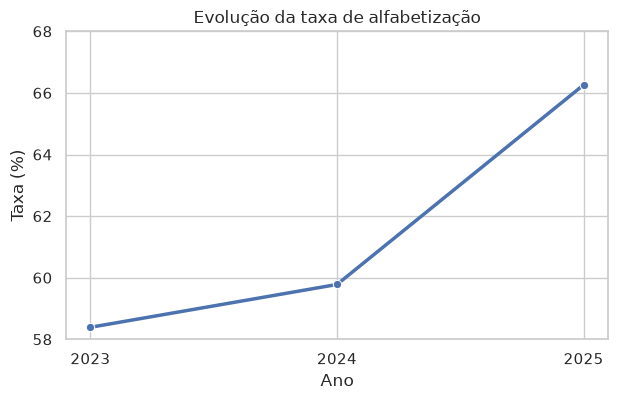

600

In [83]:
COLUNAS_SERIE = ['ano', ALVO_CLASSIFICACAO, ALVO_REGRESSAO]

serie = pd.concat(
    [pd.read_parquet(arq, columns=COLUNAS_SERIE)
     for arq in sorted(CAMINHO_BASE.rglob('*.parquet'))],
    ignore_index=True
)

por_ano = serie.groupby('ano').agg(
    alunos=(ALVO_CLASSIFICACAO, 'size'),
    taxa_alfabetizacao=(ALVO_CLASSIFICACAO, 'mean'),
    proficiencia_media=(ALVO_REGRESSAO, 'mean')
).reset_index()

por_ano['taxa_alfabetizacao'] = (
    por_ano['taxa_alfabetizacao'] * 100
).round(2)

display(por_ano)

plt.figure(figsize=(7, 4))

sns.lineplot(
    data=por_ano,
    x='ano',
    y='taxa_alfabetizacao',
    marker='o',
    linewidth=2.5
)

plt.title('Evolução da taxa de alfabetização')
plt.xlabel('Ano')
plt.ylabel('Taxa (%)')
plt.xticks([2023, 2024, 2025])
plt.ylim(58, 68)

plt.show()

del serie
gc.collect()

### Decisão de modelagem — validação temporal

A comparação entre anos mostra que a taxa de alfabetização se desloca de forma relevante ao longo da série. Isso torna a separação temporal obrigatória: uma divisão aleatória misturaria anos e produziria uma estimativa otimista de generalização.

A especificação do desenho experimental — unidade de análise, alvo e quais anos entram em cada conjunto — é fechada na **seção 10**, depois que a EDA acumular as evidências necessárias. Até lá, fica registrado o princípio: o ano mais recente permanece isolado e é usado uma única vez, ao final.


## 7. Padrões por rede e território

A comparação por grupos indica onde existe maior heterogeneidade. O resultado é associativo, não causal: diferenças entre UFs podem refletir muitas características simultâneas.


IDs de UF sem mapeamento: <IntegerArray>
[]
Length: 0, dtype: Int64


,dependencia_administrativa,alunos,taxa_alfabetizacao,proficiencia_media
0,2,241074,62.540,752.283
1,3,1610754,59.370,748.557


,uf,id_uf,alunos,taxa_alfabetizacao,proficiencia_media
8,CE,23,88158,85.330,797.349
24,GO,52,70799,73.020,759.351
15,MG,31,180771,72.590,758.784
16,ES,32,42751,72.090,758.982
19,PR,41,119806,70.800,755.043
20,SC,42,69035,63.650,751.774
0,RO,11,20027,63.020,745.905
11,PE,26,75953,61.070,747.609
23,MT,51,45083,60.970,753.728
7,PI,22,31105,60.270,755.379


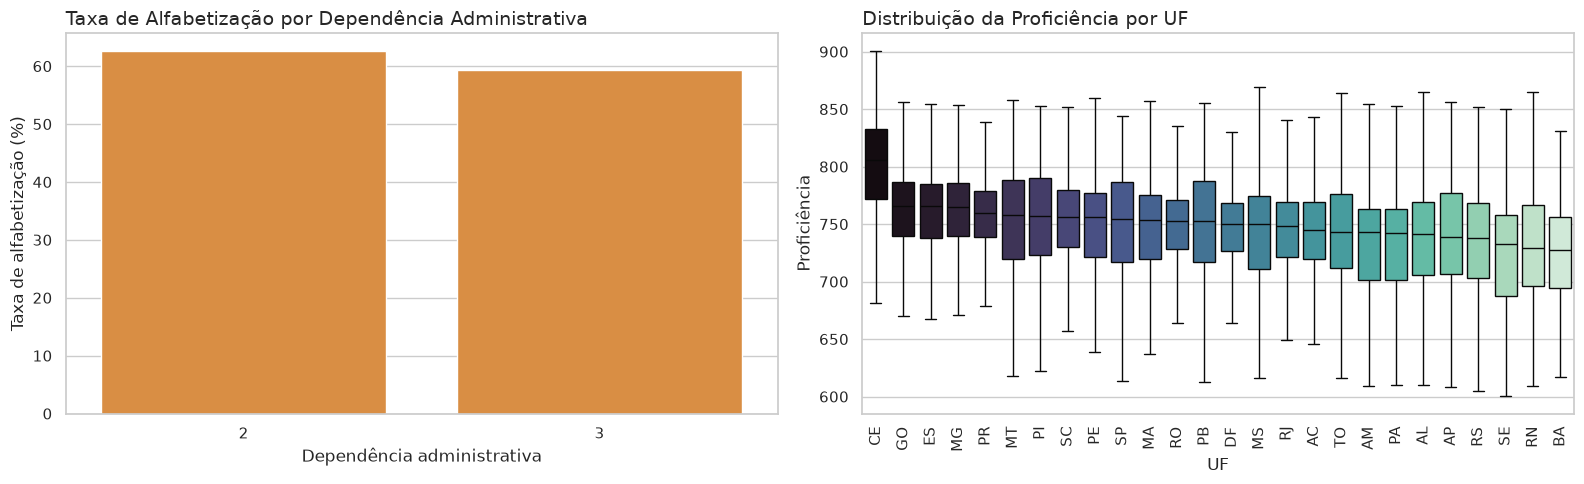

18685

In [84]:
# ------------------------------------------------------------
# Análise por dependência administrativa e UF
# ------------------------------------------------------------

# Mapeamento: código IBGE da UF -> sigla
mapa_sigla_uf = {
    11: 'RO', 12: 'AC', 13: 'AM', 14: 'RR', 15: 'PA', 16: 'AP', 17: 'TO',
    21: 'MA', 22: 'PI', 23: 'CE', 24: 'RN', 25: 'PB', 26: 'PE', 27: 'AL',
    28: 'SE', 29: 'BA',
    31: 'MG', 32: 'ES', 33: 'RJ', 35: 'SP',
    41: 'PR', 42: 'SC', 43: 'RS',
    50: 'MS', 51: 'MT', 52: 'GO', 53: 'DF'
}

# Cria a coluna de sigla da UF
df['uf'] = df['id_uf'].map(mapa_sigla_uf)

# Validação: verificar se existe algum código sem sigla correspondente
ufs_sem_mapeamento = df.loc[
    df['uf'].isna(),
    'id_uf'
].unique()

print('IDs de UF sem mapeamento:', ufs_sem_mapeamento)


# ------------------------------------------------------------
# Resumo por dependência administrativa
# ------------------------------------------------------------

por_rede = df.groupby('dependencia_administrativa').agg(
    alunos=('id_aluno', 'size'),
    taxa_alfabetizacao=(ALVO_CLASSIFICACAO, 'mean'),
    proficiencia_media=(ALVO_REGRESSAO, 'mean')
).reset_index()

por_rede['taxa_alfabetizacao'] = (
    por_rede['taxa_alfabetizacao'] * 100
).round(2)

display(por_rede)


# ------------------------------------------------------------
# Resumo por UF
# ------------------------------------------------------------

por_uf = df.groupby(['id_uf', 'uf']).agg(
    alunos=('id_aluno', 'size'),
    taxa_alfabetizacao=(ALVO_CLASSIFICACAO, 'mean'),
    proficiencia_media=(ALVO_REGRESSAO, 'mean')
).reset_index()

por_uf['taxa_alfabetizacao'] = (
    por_uf['taxa_alfabetizacao'] * 100
).round(2)

por_uf = por_uf.sort_values(
    by='taxa_alfabetizacao',
    ascending=False
)

display(
    por_uf[
        [
            'uf',
            'id_uf',
            'alunos',
            'taxa_alfabetizacao',
            'proficiencia_media'
        ]
    ]
)


# ------------------------------------------------------------
# Gráficos: alfabetização por rede e proficiência por UF
# ------------------------------------------------------------

# Ordena as UFs pela mediana de proficiência.
# A ordenação torna a comparação visual mais simples.
ordem_ufs = (
    df.groupby('uf')[ALVO_REGRESSAO]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras: taxa de alfabetização por rede
sns.barplot(
    data=por_rede,
    x='dependencia_administrativa',
    y='taxa_alfabetizacao',
    color='#F28E2B',
    ax=axes[0]
)

axes[0].set_title(
    'Taxa de Alfabetização por Dependência Administrativa',
    loc='left',
    fontsize=14
)

axes[0].set_xlabel('Dependência administrativa')
axes[0].set_ylabel('Taxa de alfabetização (%)')


# Boxplot: distribuição da proficiência dos alunos por UF
sns.boxplot(
    data=df,
    x='uf',
    y=ALVO_REGRESSAO,
    order=ordem_ufs,
    palette='mako',
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title(
    'Distribuição da Proficiência por UF',
    loc='left',
    fontsize=14
)

axes[1].set_xlabel('UF')
axes[1].set_ylabel('Proficiência')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


IDs de UF sem mapeamento de região: <IntegerArray>
[]
Length: 0, dtype: Int64


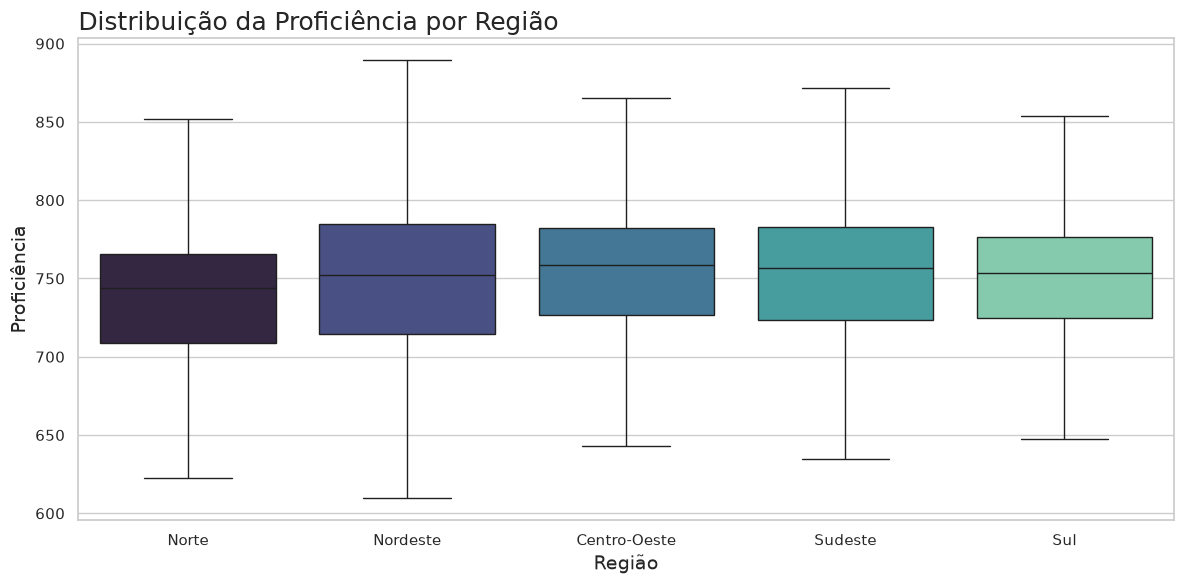

In [85]:
# ------------------------------------------------------------
# Boxplot: distribuição da proficiência por região do Brasil
# ------------------------------------------------------------

# Mapeamento: código IBGE da UF -> região
mapa_regiao_uf = {
    # Norte
    11: 'Norte', 12: 'Norte', 13: 'Norte', 14: 'Norte',
    15: 'Norte', 16: 'Norte', 17: 'Norte',

    # Nordeste
    21: 'Nordeste', 22: 'Nordeste', 23: 'Nordeste',
    24: 'Nordeste', 25: 'Nordeste', 26: 'Nordeste',
    27: 'Nordeste', 28: 'Nordeste', 29: 'Nordeste',

    # Sudeste
    31: 'Sudeste', 32: 'Sudeste', 33: 'Sudeste', 35: 'Sudeste',

    # Sul
    41: 'Sul', 42: 'Sul', 43: 'Sul',

    # Centro-Oeste
    50: 'Centro-Oeste', 51: 'Centro-Oeste',
    52: 'Centro-Oeste', 53: 'Centro-Oeste'
}

# Cria a variável categórica de região
df['regiao'] = df['id_uf'].map(mapa_regiao_uf)

# Confere se existe algum código de UF sem região correspondente
ufs_sem_regiao = df.loc[
    df['regiao'].isna(),
    'id_uf'
].unique()

print('IDs de UF sem mapeamento de região:', ufs_sem_regiao)

# Ordem geográfica e didática das regiões
ordem_regioes = [
    'Norte',
    'Nordeste',
    'Centro-Oeste',
    'Sudeste',
    'Sul'
]

# Boxplot da proficiência por região
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='regiao',
    y=ALVO_REGRESSAO,
    order=ordem_regioes,
    palette='mako',
    showfliers=False
)

plt.title(
    'Distribuição da Proficiência por Região',
    loc='left',
    fontsize=18
)

plt.xlabel('Região', fontsize=14)
plt.ylabel('Proficiência', fontsize=14)

plt.tight_layout()
plt.show()


### Decisão de modelagem — avaliação por subgrupo

Além da métrica global, calcular resultados por UF, faixa de pobreza e rede. Um modelo pode apresentar bom resultado médio e falhar de modo sistemático em territórios mais vulneráveis. Essa análise é parte da validação do modelo, não uma etapa opcional de apresentação.


### Teste estatístico de diferenças de proficiência

Primeiro, calculamos a média observada de `label_proficiencia` por UF e por região.
Depois, aplicamos a ANOVA de Welch para verificar se há diferença estatisticamente
significativa entre os grupos.

A ANOVA de Welch foi escolhida porque não exige que todos os grupos tenham a mesma
variância ou exatamente o mesmo número de alunos.

Quando o resultado global é significativo, realizamos comparações entre pares usando
o teste t de Welch. Como são feitos vários testes simultaneamente, aplicamos a
correção de Holm aos p-valores para reduzir o risco de identificar diferenças falsas.

A maior média observada não significa automaticamente que o grupo seja superior aos
demais. Para afirmar diferença estatística, a UF ou região líder deve apresentar
p-valor ajustado inferior a 0,05 nas comparações com os demais grupos.


In [86]:
from itertools import combinations

from scipy.stats import ttest_ind
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multitest import multipletests

df['regiao'] = df['id_uf'].map(mapa_regiao_uf)

def comparar_medias_por_grupo(
    dados,
    coluna_grupo,
    coluna_nota,
    nivel_significancia=0.05
):
    """
    Compara médias entre grupos usando:
    1. ANOVA de Welch para diferença global;
    2. Testes t de Welch par a par;
    3. Correção de Holm para múltiplas comparações.
    """

    # Mantém apenas grupos e notas válidas
    base = dados[[coluna_grupo, coluna_nota]].dropna().copy()

    # Tabela descritiva: quantidade, média, desvio e mediana
    resumo = (
        base.groupby(coluna_grupo)[coluna_nota]
        .agg(
            alunos='count',
            media='mean',
            desvio_padrao='std',
            mediana='median'
        )
        .sort_values('media', ascending=False)
    )

    grupo_lider = resumo.index[0]
    media_lider = resumo.loc[grupo_lider, 'media']

    print(f'Grupo com maior média observada: {grupo_lider}')
    print(f'Média de proficiência: {media_lider:.2f}\n')

    display(resumo.round(2))

    # Prepara as notas de cada grupo para a ANOVA de Welch
    grupos = [
        grupo[coluna_nota].values
        for _, grupo in base.groupby(coluna_grupo)
    ]

    # Teste global: há pelo menos uma média diferente?
    resultado_welch = anova_oneway(
        grupos,
        use_var='unequal',
        welch_correction=True
    )

    print('ANOVA de Welch')
    print(f'Estatística: {resultado_welch.statistic:.4f}')
    print(f'p-valor: {resultado_welch.pvalue:.6f}')

    if resultado_welch.pvalue >= nivel_significancia:
        print(
            '\nConclusão: não há evidência estatística suficiente '
            'de diferença entre as médias dos grupos.'
        )
        return resumo, None

    print(
        '\nConclusão: há evidência de que pelo menos dois grupos '
        'possuem médias diferentes.'
    )

    # Comparações em pares com teste t de Welch
    resultados_pares = []

    for grupo_a, grupo_b in combinations(resumo.index, 2):
        notas_a = base.loc[
            base[coluna_grupo] == grupo_a,
            coluna_nota
        ]

        notas_b = base.loc[
            base[coluna_grupo] == grupo_b,
            coluna_nota
        ]

        teste = ttest_ind(
            notas_a,
            notas_b,
            equal_var=False,
            nan_policy='omit'
        )

        diferenca_media = notas_a.mean() - notas_b.mean()

        resultados_pares.append({
            'grupo_a': grupo_a,
            'grupo_b': grupo_b,
            'diferenca_media_a_menos_b': diferenca_media,
            'p_valor_bruto': teste.pvalue
        })

    comparacoes = pd.DataFrame(resultados_pares)

    # Corrige os p-valores de todas as comparações simultâneas
    rejeita_h0, p_ajustado, _, _ = multipletests(
        comparacoes['p_valor_bruto'],
        alpha=nivel_significancia,
        method='holm'
    )

    comparacoes['p_valor_ajustado_holm'] = p_ajustado
    comparacoes['diferenca_significativa'] = rejeita_h0

    comparacoes = comparacoes.sort_values(
        'p_valor_ajustado_holm'
    )

    print('\nComparações par a par — teste t de Welch com correção de Holm')
    display(comparacoes.round(4))

    # Compara especificamente o líder com todos os demais grupos
    comparacoes_lider = comparacoes[
        (comparacoes['grupo_a'] == grupo_lider) |
        (comparacoes['grupo_b'] == grupo_lider)
    ].copy()

    grupos_sem_diferenca_do_lider = set()

    for _, linha in comparacoes_lider.iterrows():
        outro_grupo = (
            linha['grupo_b']
            if linha['grupo_a'] == grupo_lider
            else linha['grupo_a']
        )

        if not linha['diferenca_significativa']:
            grupos_sem_diferenca_do_lider.add(outro_grupo)

    if len(grupos_sem_diferenca_do_lider) == 0:
        print(
            f'\nResultado: {grupo_lider} possui a maior média e é '
            'estatisticamente diferente de todos os demais grupos.'
        )
    else:
        print(
            f'\nResultado: {grupo_lider} possui a maior média observada, '
            'mas não difere estatisticamente de:'
        )
        print(', '.join(sorted(grupos_sem_diferenca_do_lider)))

    return resumo, comparacoes

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


480

In [87]:
df['uf'] = df['id_uf'].map(mapa_sigla_uf)

resumo_uf, comparacoes_uf = comparar_medias_por_grupo(
    dados=df,
    coluna_grupo='uf',
    coluna_nota=ALVO_REGRESSAO
)

Grupo com maior média observada: CE
Média de proficiência: 797.35



,alunos,media,desvio_padrao,mediana
uf,,,,
CE,88158,797.350,52.570,805.390
GO,70799,759.350,42.000,765.980
ES,42751,758.980,41.430,765.690
MG,180771,758.780,41.390,764.870
PI,31105,755.380,48.040,756.870
PR,119806,755.040,38.490,759.890
MT,45083,753.730,47.300,758.150
SC,69035,751.770,42.750,756.030
PB,31004,751.470,49.060,752.460


ANOVA de Welch
Estatística: 6965.1334
p-valor: 0.000000

Conclusão: há evidência de que pelo menos dois grupos possuem médias diferentes.

Comparações par a par — teste t de Welch com correção de Holm


,grupo_a,grupo_b,diferenca_media_a_menos_b,p_valor_bruto,p_valor_ajustado_holm,diferenca_significativa
0,CE,GO,37.998,0.000,0.000,True
1,CE,ES,38.368,0.000,0.000,True
2,CE,MG,38.565,0.000,0.000,True
3,CE,PI,41.970,0.000,0.000,True
4,CE,PR,42.306,0.000,0.000,True
...,...,...,...,...,...,...
289,AC,RJ,0.164,0.715,1.000,False
94,PI,PR,0.336,0.253,1.000,False
49,ES,MG,0.197,0.376,1.000,False
304,AL,RS,0.237,0.448,1.000,False



Resultado: CE possui a maior média e é estatisticamente diferente de todos os demais grupos.


O Ceará apresentou a maior média observada de proficiência, com 797,35 pontos.
Após a ANOVA de Welch e os testes t de Welch com correção de Holm, a média do
Ceará foi estatisticamente superior à média de todas as demais UFs analisadas
(p-valor ajustado < 0,05).

In [88]:
resumo_regiao, comparacoes_regiao = comparar_medias_por_grupo(
    dados=df,
    coluna_grupo='regiao',
    coluna_nota=ALVO_REGRESSAO
)


Grupo com maior média observada: Centro-Oeste
Média de proficiência: 752.11



,alunos,media,desvio_padrao,mediana
regiao,,,,
Centro-Oeste,175205,752.110,44.360,758.800
Sudeste,744637,751.110,46.290,756.940
Nordeste,465488,750.190,52.130,752.390
Sul,278403,747.980,42.980,753.600
Norte,188095,736.740,42.790,743.640


ANOVA de Welch
Estatística: 4551.2252
p-valor: 0.000000

Conclusão: há evidência de que pelo menos dois grupos possuem médias diferentes.

Comparações par a par — teste t de Welch com correção de Holm


,grupo_a,grupo_b,diferenca_media_a_menos_b,p_valor_bruto,p_valor_ajustado_holm,diferenca_significativa
3,Centro-Oeste,Norte,15.379,0.000,0.000,True
6,Sudeste,Norte,14.370,0.000,0.000,True
9,Sul,Norte,11.249,0.000,0.000,True
8,Nordeste,Norte,13.455,0.000,0.000,True
5,Sudeste,Sul,3.121,0.000,0.000,True
2,Centro-Oeste,Sul,4.130,0.000,0.000,True
7,Nordeste,Sul,2.206,0.000,0.000,True
1,Centro-Oeste,Nordeste,1.924,0.000,0.000,True
4,Sudeste,Nordeste,0.915,0.000,0.000,True
0,Centro-Oeste,Sudeste,1.009,0.000,0.000,True



Resultado: Centro-Oeste possui a maior média e é estatisticamente diferente de todos os demais grupos.


## 8. Engenharia de atributos orientada pela EDA

Features derivadas devem ter justificativa de negócio e estar disponíveis no momento da previsão. Densidade e transformações logarítmicas corrigem limitações observadas na análise descritiva.


### Transformação logarítmica de população e densidade

População e densidade são candidatas a `log1p` quando apresentam forte assimetria. Em vez de assumir o benefício da transformação, a célula abaixo calcula a assimetria **antes e depois**.

A transformação é:

\[
x_{log} = \ln(1+x)
\]

Ela só será considerada útil se reduzir materialmente a assimetria observada. As versões originais permanecem disponíveis para interpretação descritiva.


In [89]:
# ------------------------------------------------------------
# Evidência e transformação logarítmica
# ------------------------------------------------------------

# Relação entre população e área.
df['ctx_ibge_densidade_populacional'] = (
    df['ctx_ibge_populacao_residente'] /
    df['ctx_ibge_area_km2'].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

assimetria_antes = pd.Series({
    'populacao': df['ctx_ibge_populacao_residente'].skew(),
    'densidade': df['ctx_ibge_densidade_populacional'].skew(),
}, name='assimetria_antes')

# Redução de assimetria.
df['ctx_ibge_log_populacao'] = np.log1p(
    df['ctx_ibge_populacao_residente']
)
df['ctx_ibge_log_densidade_populacional'] = np.log1p(
    df['ctx_ibge_densidade_populacional']
)

assimetria_depois = pd.Series({
    'populacao': df['ctx_ibge_log_populacao'].skew(),
    'densidade': df['ctx_ibge_log_densidade_populacional'].skew(),
}, name='assimetria_depois_log1p')

diagnostico_log = pd.concat(
    [assimetria_antes, assimetria_depois],
    axis=1
)
diagnostico_log['reducao_abs_assimetria'] = (
    diagnostico_log['assimetria_antes'].abs()
    - diagnostico_log['assimetria_depois_log1p'].abs()
)

print('Efeito de log1p sobre a assimetria')
display(diagnostico_log.round(3))

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


Efeito de log1p sobre a assimetria


,assimetria_antes,assimetria_depois_log1p,reducao_abs_assimetria
populacao,3.265,0.403,2.862
densidade,2.163,0.108,2.055


0

## 9. Correlação e sinal preditivo

A análise de correlação é mantida de forma enxuta. Os grandes heatmaps por bloco e a grade de dispersões foram removidos porque repetiam informação, eram difíceis de interpretar e aumentavam o custo de renderização.

Nesta etapa interessa principalmente ordenar as associações com o alvo. A redundância entre features já foi tratada antecipadamente no bloco **Qualidade das features**.


Quantidade inicial de features numéricas: 41
Features após filtros de qualidade: 41


,correlacao_spearman_com_proficiencia
ctx_inep_mun_media_portugues_lag1,0.273
ctx_inep_mun_taxa_alfabetizacao_lag1,0.261
ctx_inep_mun_meta,0.259
ctx_inep_uf_media_portugues_lag1,0.236
ctx_inep_mun_percentual_participacao_lag1,0.198
ctx_inep_uf_percentual_participacao_lag1,0.184
ctx_atlas_expectativa_anos_estudo,0.100
ctx_atlas_taxa_fora_escola_6a14,-0.099
ctx_atlas_taxa_densidade_domiciliar,-0.092
ctx_atlas_taxa_fora_escola_4a5,-0.083


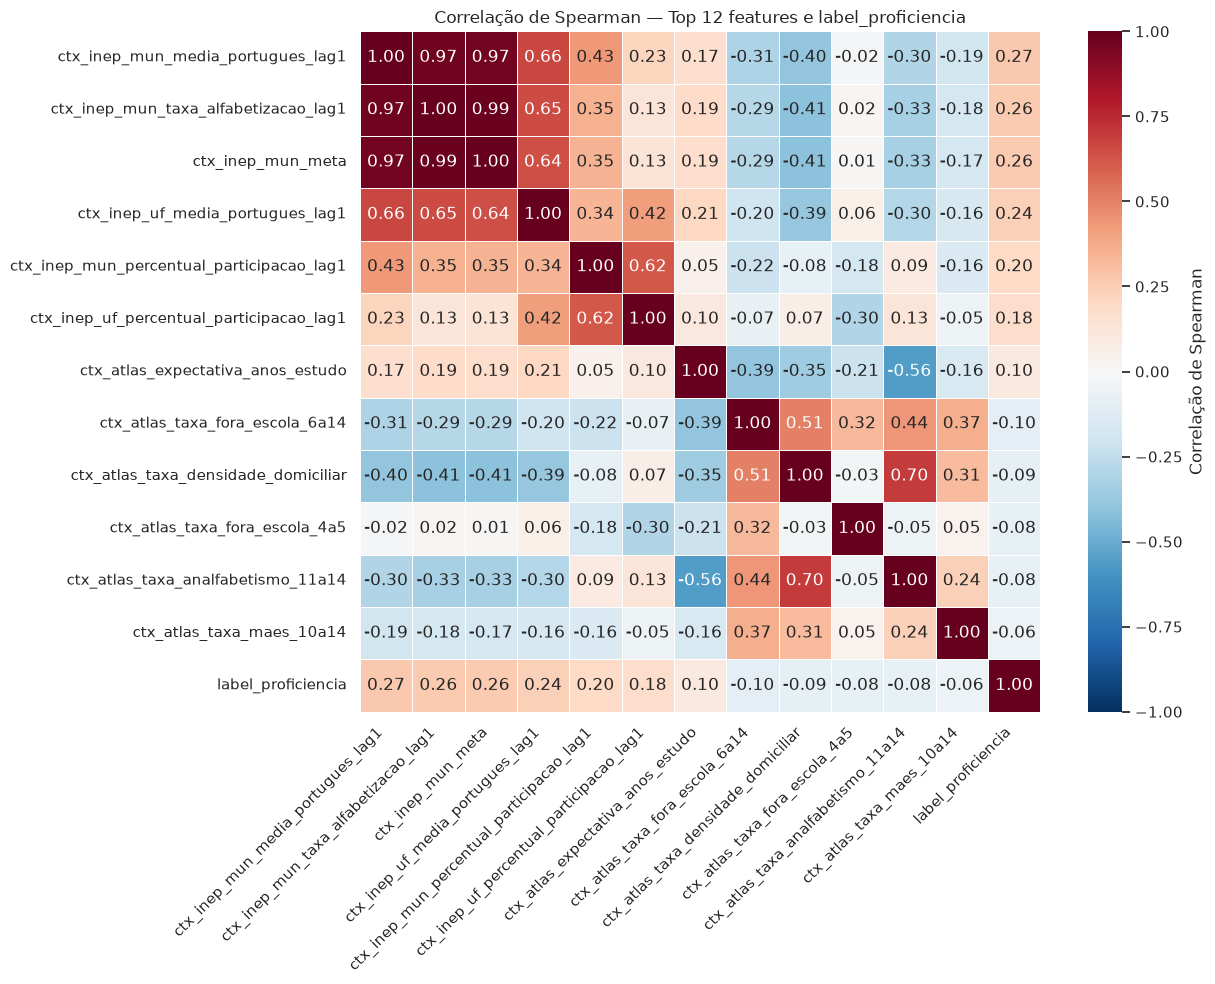

16265

In [90]:
# ------------------------------------------------------------
# Seleção automática de colunas para análise de correlação
# ------------------------------------------------------------

import gc

# Definições
LIMITE_NULOS_PCT = 10
TOP_N_FEATURES = 12

# 1. Remover identificadores e os dois alvos.
# Os dois alvos saem para evitar vazamento de dados.
colunas_excluir = IDENTIFICADORES + [
    ALVO_CLASSIFICACAO,
    ALVO_REGRESSAO
]

features_candidatas = df.drop(
    columns=colunas_excluir,
    errors='ignore'
)

# 2. Manter somente colunas numéricas.
features_numericas = features_candidatas.select_dtypes(
    include='number'
)

quantidade_inicial = features_numericas.shape[1]

# 3. Remover colunas constantes ou sem variação.
features_numericas = features_numericas.loc[
    :,
    features_numericas.nunique(dropna=True) > 1
]

# 4. Remover colunas com muitos valores ausentes.
nulos_pct = features_numericas.isna().mean() * 100

features_numericas = features_numericas.loc[
    :,
    nulos_pct <= LIMITE_NULOS_PCT
]

print(
    f'Quantidade inicial de features numéricas: '
    f'{quantidade_inicial}'
)

print(
    f'Features após filtros de qualidade: '
    f'{features_numericas.shape[1]}'
)

# ------------------------------------------------------------
# 5. Correlação de Spearman entre cada feature e o alvo
# ------------------------------------------------------------

correlacao_alvo = (
    features_numericas
    .corrwith(
        df[ALVO_REGRESSAO],
        method='spearman'
    )
    .dropna()
    .sort_values(
        key=lambda serie: serie.abs(),
        ascending=False
    )
)

display(
    correlacao_alvo
    .rename('correlacao_spearman_com_proficiencia')
    .to_frame()
    .head(20)
)

# ------------------------------------------------------------
# 6. Seleciona as TOP_N_FEATURES mais associadas ao alvo
# ------------------------------------------------------------

top_features = (
    correlacao_alvo
    .head(TOP_N_FEATURES)
    .index
    .tolist()
)

# ------------------------------------------------------------
# 7. Matriz de correlação para o heatmap
# ------------------------------------------------------------

# Inclui o alvo apenas para fins de visualização.
# Ele não está sendo usado como feature preditora.
colunas_heatmap = top_features + [ALVO_REGRESSAO]

dados_heatmap = df[
    colunas_heatmap
].copy()

matriz_corr = dados_heatmap.corr(
    method='spearman'
)

# ------------------------------------------------------------
# 8. Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(13, 10))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={
        'label': 'Correlação de Spearman'
    }
)

plt.title(
    f'Correlação de Spearman — Top {TOP_N_FEATURES} features '
    f'e {ALVO_REGRESSAO}'
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Liberação de memória
# ------------------------------------------------------------

del (
    features_candidatas,
    dados_heatmap,
    matriz_corr
)

gc.collect()

### Decisão de modelagem — seleção de features

A seleção estrutural de features já foi realizada no início do notebook:

- `>10%` de nulos em 2024 → remoção;
- componentes com `|Spearman| ≥ 0,90` → um representante;
- `nivel_lag1` → removida em favor de `taxa_lag1`.

Não será aplicada uma segunda rodada arbitrária de VIF ou correlação antes do baseline. Isso evita criar metodologias concorrentes de seleção.

Na modelagem, comparar conjuntos progressivos de informação — por exemplo, histórico educacional; histórico + socioeconômico; conjunto completo aprovado — e avaliar o ganho por validação temporal. Para interpretação, usar coeficientes nos modelos lineares e importância por permutação/SHAP nos modelos de árvores.


## 10. Unidade de análise e definição do alvo de modelagem

Todas as seções anteriores trataram a base como ela é gravada: **uma linha por aluno-ano**. Essa é a granularidade do arquivo. A unidade de análise da modelagem é outra decisão, e é ela que organiza tudo o que vem depois — quais features fazem sentido, qual alvo é previsível, como separar treino e teste.

A pergunta surge de uma constatação que atravessa toda a EDA: **nenhuma das 76 features descreve o aluno**. Elas descrevem o desempenho municipal defasado do INEP, o contexto socioeconômico do Atlas, a oferta educacional do Censo Escolar, os indicadores do IBGE e do FUNDEB. A única coluna que descreve o aluno é `dependencia_administrativa`, e ela na verdade descreve a rede em que ele estuda.

Se as features descrevem o lugar e o alvo descreve a pessoa, dois alunos da mesma cidade recebem vetores de entrada idênticos e nenhum algoritmo consegue separá-los. A célula a seguir transforma isso em contagem, em vez de deixar como argumento.

### 10.1 Evidência: quantas entradas distintas o modelo realmente enxerga

Se as features são constantes dentro do município, dois alunos da mesma cidade recebem vetores de atributos idênticos e o modelo não tem como separá-los — qualquer que seja o algoritmo. A contagem abaixo transforma isso em número: quantas linhas a matriz de atributos tem, e quantas linhas **distintas**.


In [91]:
# ------------------------------------------------------------
# 10.1 — As features variam dentro do município?
# ------------------------------------------------------------
# Uma coluna por vez: agrupar as 76 de uma vez materializaria um objeto grande
# demais para o Colab.

variacao_interna = {}
for coluna in variaveis_contexto:
    variacao_interna[coluna] = int(
        df.groupby('id_municipio', observed=True)[coluna].nunique(dropna=False).max()
    )

variacao_interna = pd.Series(variacao_interna, name='valores_distintos_no_municipio')
constantes = variacao_interna.le(1)

print(f'Features de contexto avaliadas: {len(variacao_interna)}')
print(f'  constantes dentro do município: {int(constantes.sum())}')
print(f'  que variam dentro do município: {int((~constantes).sum())}')
print()
print('As que variam, e até quantos valores assumem:')
display(variacao_interna[~constantes].sort_values(ascending=False).to_frame())
print('Todas pertencem ao bloco ATU do Censo Escolar, que é casado por município + rede.')
print('Elas assumem no máximo 2 valores: um para a rede estadual, outro para a municipal.')

# ------------------------------------------------------------
# Quantos vetores de atributos distintos existem de fato
# ------------------------------------------------------------
bloco_contexto = df[variaveis_contexto].astype('float32')   # cópia enxuta só para o hash
assinatura = pd.util.hash_pandas_object(bloco_contexto, index=False)
del bloco_contexto
gc.collect()

grupos_municipio_rede = df.groupby(
    ['id_municipio', 'dependencia_administrativa'], observed=True
).ngroups

print(f'\nAlunos na partição de {ANO_ANALISE} ....: {len(df):,}')
print(f'Vetores de atributos distintos .......: {assinatura.nunique():,}')
print(f'Municípios ...........................: {df["id_municipio"].nunique():,}')
print(f'Pares município x rede ...............: {grupos_municipio_rede:,}')

tamanho_grupo = assinatura.groupby(assinatura).size()
print(f'\nAlunos por vetor distinto: mediana {tamanho_grupo.median():.0f} | '
      f'média {tamanho_grupo.mean():.0f} | máximo {tamanho_grupo.max():,}')

del assinatura, tamanho_grupo
gc.collect();

Features de contexto avaliadas: 37
  constantes dentro do município: 28
  que variam dentro do município: 9

As que variam, e até quantos valores assumem:


,valores_distintos_no_municipio
ctx_atu_educacao_infantil,2
ctx_atu_creche,2
ctx_atu_pre_escola,2
ctx_atu_fundamental_anos_iniciais,2
ctx_atu_fundamental_1_ano,2
ctx_atu_fundamental_2_ano,2
ctx_atu_fundamental_3_ano,2
ctx_atu_fundamental_4_ano,2
ctx_atu_fundamental_5_ano,2


Todas pertencem ao bloco ATU do Censo Escolar, que é casado por município + rede.
Elas assumem no máximo 2 valores: um para a rede estadual, outro para a municipal.

Alunos na partição de 2024 ....: 1,851,828
Vetores de atributos distintos .......: 6,535
Municípios ...........................: 5,517
Pares município x rede ...............: 6,535

Alunos por vetor distinto: mediana 91 | média 283 | máximo 52,622


### 10.2 Leitura e decisão sobre a unidade de análise

**A matriz de atributos tem 1,85 milhão de linhas e cerca de 6,5 mil linhas distintas** — exatamente o número de pares município × rede. Cinquenta e quatro das 76 features são constantes dentro do município; as 22 que variam pertencem ao bloco ATU, casado por município + rede, e assumem no máximo dois valores. A mediana é de **91 alunos compartilhando o mesmo vetor de entrada**, e o máximo é de 52.622.

Isso encerra a discussão sobre granularidade. Não se trata de escolher um algoritmo melhor: alunos com entrada idêntica não podem receber previsões diferentes, qualquer que seja o modelo. A pergunta estava formulada numa granularidade que os dados não sustentam.

### Decisão — unidade de análise

A modelagem passa a operar em **(município, ano)**. Cada linha é um município num ano letivo, features e alvo passam a descrever a mesma entidade, e o produto do modelo deixa de ser uma classificação de aluno para ser uma **priorização de territórios** — que é o que uma política pública consegue executar.

Essa decisão fixa a *unidade*, não o *alvo*. Qual desfecho municipal prever é uma segunda decisão, que depende de evidência ainda não produzida e é tratada na seção 11.

### 10.3 Reconstrução da base município-ano

A versão anterior desta seção agregava cinco colunas — `alunos`, `taxa_realizada`, `proficiencia_media`, `meta` e `taxa_lag1`. Depois de excluir o alvo e o que dele deriva, sobravam **três atributos**: `alunos`, `meta` e `taxa_lag1`.

Três atributos não respondem às perguntas de negócio. O contexto do Atlas, do IBGE, do FUNDEB e do Censo Escolar existe na base e é, por natureza, municipal: ele foi descartado por um recorte de conveniência da agregação, não por um problema de dados.

A reconstrução aproveita uma propriedade da base. Como cada linha é um aluno, **a média por município já é a média ponderada por aluno**: para as 54 colunas constantes dentro do município ela devolve o próprio valor, e para as 22 colunas do bloco ATU devolve a média entre as redes estadual e municipal, ponderada pelo número de alunos de cada uma. Um único caminho de código cobre os dois casos.

A chave da agregação continua explicitamente sendo **`ano + id_uf + id_municipio`**. Portanto, “reconstruir a base município-ano” não significa abandonar município e ano; significa justamente fazer com que **cada linha final seja um município em um determinado ano**, preservando o contexto necessário para explicar e prever seus resultados.


In [92]:
# ------------------------------------------------------------
# 10.3 — Base município-ano com o bloco de contexto completo
# ------------------------------------------------------------
# A versão anterior desta célula agregava 5 colunas e, depois de excluir alvo
# e derivados, sobravam 3 atributos (`alunos`, `meta`, `taxa_lag1`). Isso é
# pouco para responder às perguntas de negócio.
#
# Como cada linha do arquivo é um aluno, a MÉDIA por município já é a média
# ponderada por aluno. Para as 54 colunas constantes dentro do município ela
# devolve o próprio valor; para as 22 colunas do bloco ATU, que variam por
# rede, devolve a média ponderada entre rede estadual e municipal.
#
# A leitura é feita arquivo a arquivo e o DataFrame é descartado em seguida:
# a partição de 2024 sozinha ocupa ~1,5 GB.

def agregar_municipio_ano(arquivo):
    """Colapsa um arquivo aluno-ano em município-ano."""
    parte = pd.read_parquet(arquivo)
    parte = parte.drop(columns=['_gold_processed_at'], errors='ignore')

    # Aplica a mesma seleção antecipada definida em Qualidade das features.
    parte = parte.drop(columns=COLUNAS_REMOVER, errors='ignore')

    colunas_ctx = [c for c in parte.columns if c.startswith('ctx_')]
    chaves = ['ano', 'id_uf', 'id_municipio']

    resumo = parte.groupby(chaves, observed=True).agg(
        alunos=(ALVO_CLASSIFICACAO, 'size'),
        taxa_realizada=(ALVO_CLASSIFICACAO, 'mean'),
        proficiencia_media=(ALVO_REGRESSAO, 'mean'),
        escolas=('id_escola', 'nunique'),
        pct_rede_municipal=('dependencia_administrativa',
                            lambda s: (s == 3).mean()),
    )
    resumo['taxa_realizada'] = resumo['taxa_realizada'].astype(float) * 100
    resumo['pct_rede_municipal'] = resumo['pct_rede_municipal'] * 100

    contexto = parte.groupby(chaves, observed=True)[colunas_ctx].mean()
    resultado = resumo.join(contexto).reset_index()

    del parte, contexto
    gc.collect()
    return resultado


municipios_ano = pd.concat(
    [agregar_municipio_ano(arquivo) for arquivo in arquivos_ano],
    ignore_index=True,
)

# Nomes curtos para as colunas usadas o tempo todo daqui em diante.
ALIASES_MUNICIPIO = {
    'ctx_inep_mun_meta': 'meta',
    'ctx_inep_mun_taxa_alfabetizacao_lag1': 'taxa_lag1',
    'ctx_inep_mun_percentual_participacao_lag1': 'participacao_lag1',
    'ctx_inep_mun_media_portugues_lag1': 'proficiencia_lag1',
    'ctx_ibge_populacao_residente': 'populacao',
}

faltantes_alias = [
    origem for origem in ALIASES_MUNICIPIO
    if origem not in municipios_ano.columns
]
if faltantes_alias:
    raise KeyError(
        'Colunas necessárias à base município-ano não foram preservadas: '
        f'{faltantes_alias}. Verifique COLUNAS_REMOVER.'
    )

municipios_ano = municipios_ano.rename(columns=ALIASES_MUNICIPIO)

municipios_ano['uf'] = municipios_ano['id_uf'].map(mapa_sigla_uf)
municipios_ano['regiao'] = municipios_ano['id_uf'].map(mapa_regiao_uf)

print(f'Base município-ano: {len(municipios_ano):,} linhas x '
      f'{municipios_ano.shape[1]} colunas')
display(municipios_ano.groupby('ano', observed=True)
        .size().rename('municipios').to_frame())

# Sanidade: a agregação reproduz a taxa que o pipeline gravou como lag?
pivot_taxa = municipios_ano.pivot_table(index='id_municipio', columns='ano',
                                        values='taxa_realizada', observed=True)
pivot_lag = municipios_ano.pivot_table(index='id_municipio', columns='ano',
                                       values='taxa_lag1', observed=True)
print('\nConsistência entre a taxa agregada em t-1 e taxa_lag1 em t')
for ano in sorted(municipios_ano['ano'].unique())[1:]:
    if (ano - 1) not in pivot_taxa.columns:
        continue
    par = pd.concat([pivot_taxa[ano - 1], pivot_lag[ano]], axis=1).dropna()
    par.columns = ['agregado', 'gravado']
    print(f'  {ano}: correlação {par["agregado"].corr(par["gravado"]):.4f} | '
          f'erro médio absoluto {(par["agregado"] - par["gravado"]).abs().mean():.2f} p.p. '
          f'| n={len(par):,}')

# Pivôs servem apenas à checagem acima e não são usados adiante.
del pivot_taxa, pivot_lag
if 'par' in locals():
    del par
gc.collect()


Base município-ano: 15,944 linhas x 47 colunas


,municipios
ano,
2023,4871
2024,5517
2025,5556



Consistência entre a taxa agregada em t-1 e taxa_lag1 em t
  2024: correlação 0.9832 | erro médio absoluto 1.73 p.p. | n=4,792
  2025: correlação 0.9877 | erro médio absoluto 1.12 p.p. | n=5,441


0

### 10.4 Decisão entre `nivel_lag1` e `taxa_lag1`

A decisão foi produzida de forma reproduzível no bloco inicial **Qualidade das features**, antes da remoção das colunas.

Os critérios são:

1. correlação de Spearman entre as duas representações;
2. concordância entre o nível gravado e o nível reconstruído pelos cortes oficiais;
3. cobertura de cada coluna em 2024 e 2025;
4. quantidade de informação preservada.

Quando a concordância é praticamente total, `nivel_lag1` funciona como discretização de `taxa_lag1`. Nesse cenário, a taxa é preferida porque mantém a informação contínua.


In [93]:
# ------------------------------------------------------------
# 10.4 — Evidência registrada e definição dos níveis oficiais
# ------------------------------------------------------------

print('Evidência usada para decidir nivel_lag1 x taxa_lag1:')
display(diagnostico_nivel_taxa.round(3))

CORTES_NIVEL = [40, 50, 60, 70, 80]
ROTULOS_NIVEL = {
    0: '0 — abaixo do nível 1 (até 40%)',
    1: '1 — nível 1 (>40% a 50%)',
    2: '2 — nível 2 (>50% a 60%)',
    3: '3 — nível 3 (>60% a 70%)',
    4: '4 — nível 4 (>70% a 80%)',
    5: '5 — nível 5 (>80%)',
}

def nivel_do_ica(taxa_percentual):
    """Converte taxa percentual no nível oficial 0–5 e preserva nulos."""
    valores = pd.to_numeric(taxa_percentual, errors='coerce')
    nivel = pd.Series(
        np.digitize(
            valores.to_numpy(dtype=float),
            CORTES_NIVEL,
            right=True
        ),
        index=valores.index,
        dtype='float'
    )
    return nivel.where(valores.notna())

municipios_ano['nivel_realizado'] = nivel_do_ica(
    municipios_ano['taxa_realizada']
)

print(
    '\nDecisão: taxa_lag1 mantida como feature; '
    'nivel_lag1 removida por redundância.'
)


Evidência usada para decidir nivel_lag1 x taxa_lag1:


,municipios,missing_taxa_pct,missing_nivel_pct,spearman_nivel_taxa,concordancia_nivel_derivado_pct,n_comparaveis
ano,,,,,,
2024,5517,1.813,3.408,0.985,99.981,5329
2025,5556,2.070,3.798,0.985,98.952,5345



Decisão: taxa_lag1 mantida como feature; nivel_lag1 removida por redundância.


### 10.5 Distribuição da alfabetização municipal

Três leituras da mesma variável: a forma da distribuição, a dispersão entre municípios e a composição por nível oficial.

A distribuição por nível é a que mais importa para a decisão da seção 11. Ela determina se faz sentido tratar o nível como alvo multiclasse, como alvo ordinal ou como binário agregado — e, principalmente, se as classes extremas têm observações suficientes para serem aprendidas.

Taxa de alfabetização por município (%), por ano


,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max
ano,,,,,,,,,,,,
2023,"4,871.000",60.920,19.950,4.550,26.750,33.140,46.780,62.100,75.980,86.670,92.860,100.000
2024,"5,517.000",63.280,18.980,0.000,30.970,37.100,49.160,64.370,77.910,87.670,93.450,100.000
2025,"5,556.000",72.160,15.840,0.000,45.230,50.620,60.970,73.360,84.310,92.310,96.430,100.000



Municípios por nível oficial de alfabetização (contagem)


ano,2023,2024,2025
0 — abaixo do nível 1 (até 40%),849,734,140
1 — nível 1 (>40% a 50%),614,738,389
2 — nível 2 (>50% a 60%),812,877,789
3 — nível 3 (>60% a 70%),872,1002,1044
4 — nível 4 (>70% a 80%),840,1013,1292
5 — nível 5 (>80%),884,1153,1902


Municípios por nível oficial de alfabetização (%)


ano,2023,2024,2025
0 — abaixo do nível 1 (até 40%),17.400,13.300,2.500
1 — nível 1 (>40% a 50%),12.600,13.400,7.000
2 — nível 2 (>50% a 60%),16.700,15.900,14.200
3 — nível 3 (>60% a 70%),17.900,18.200,18.800
4 — nível 4 (>70% a 80%),17.200,18.400,23.300
5 — nível 5 (>80%),18.100,20.900,34.200


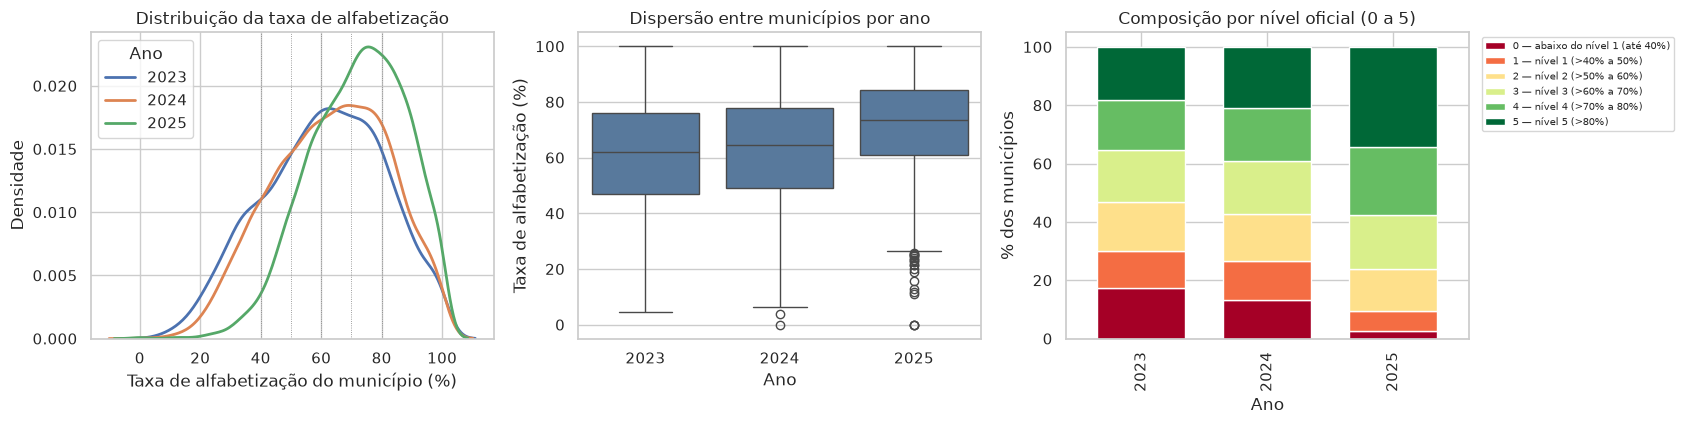

1968

In [94]:
# ------------------------------------------------------------
# 10.5 — Distribuição da alfabetização municipal
# ------------------------------------------------------------

anos_validos = sorted(municipios_ano['ano'].unique())

print('Taxa de alfabetização por município (%), por ano')
display(
    municipios_ano.groupby('ano', observed=True)['taxa_realizada']
    .describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95]).round(2)
)

distribuicao_nivel = (
    municipios_ano.pivot_table(index='nivel_realizado', columns='ano',
                               values='id_municipio', aggfunc='size',
                               observed=True)
    .reindex(range(6)).fillna(0).astype(int)
)
distribuicao_nivel.index = [ROTULOS_NIVEL[i] for i in distribuicao_nivel.index]
proporcao_nivel = distribuicao_nivel.div(distribuicao_nivel.sum()) * 100

print('\nMunicípios por nível oficial de alfabetização (contagem)')
display(distribuicao_nivel)
print('Municípios por nível oficial de alfabetização (%)')
display(proporcao_nivel.round(1))

fig, eixos = plt.subplots(1, 3, figsize=(17, 4.4))

for ano in anos_validos:
    recorte = municipios_ano[municipios_ano['ano'].eq(ano)]
    sns.kdeplot(recorte['taxa_realizada'], label=str(int(ano)),
                linewidth=2, ax=eixos[0])
for corte in CORTES_NIVEL:
    eixos[0].axvline(corte, color='grey', linewidth=0.6, linestyle=':')
eixos[0].set_title('Distribuição da taxa de alfabetização')
eixos[0].set_xlabel('Taxa de alfabetização do município (%)')
eixos[0].set_ylabel('Densidade')
eixos[0].legend(title='Ano')

sns.boxplot(data=municipios_ano, x='ano', y='taxa_realizada',
            color='#4C78A8', ax=eixos[1])
eixos[1].set_title('Dispersão entre municípios por ano')
eixos[1].set_xlabel('Ano')
eixos[1].set_ylabel('Taxa de alfabetização (%)')

proporcao_nivel.T.plot(kind='bar', stacked=True, ax=eixos[2],
                       colormap='RdYlGn', width=0.7)
eixos[2].set_title('Composição por nível oficial (0 a 5)')
eixos[2].set_xlabel('Ano')
eixos[2].set_ylabel('% dos municípios')
eixos[2].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Libera objetos temporários desta etapa.
if 'fig' in locals():
    del fig
if 'eixos' in locals():
    del eixos
gc.collect()


### 10.6 Cumprimento da meta é uma dimensão diferente de alfabetização

A auditoria já produziu o número que obriga esta seção. Em 2025, por UF:

| UF | meta média | taxa média | % que não cumpriu |
|---|---:|---:|---:|
| RS | 71,6 | 64,9 | 71,6% |
| AL | 56,0 | 70,0 | 4,9% |

Alagoas alfabetiza **mais** que o Rio Grande do Sul e tem taxa de não cumprimento quinze vezes menor, porque pactuou uma meta 15 p.p. mais baixa. `taxa_realizada < meta` mede o quanto a meta foi ambiciosa, não o quanto o município é vulnerável.

Isso não invalida o alvo — invalida apenas a **interpretação** dele como vulnerabilidade educacional. São duas perguntas distintas:

- *este município vai cumprir o que pactuou?* → cumprimento de política;
- *este município está alfabetizando suas crianças?* → risco educacional.

A célula mede o quanto as duas definições coincidem de fato. Quanto menor a sobreposição, mais claro fica que uma única variável-alvo não responde às duas perguntas.

Balanceamento de `risco_nao_atingir_meta` por ano


,municipios,nao_cumpriu_pct,meta_media,taxa_media,esforco_pactuado_mediano
ano,,,,,
2024,5442,45.530,61.650,63.210,3.150
2025,5499,27.280,64.640,72.160,2.310



Por UF em 2025: a meta explica o risco melhor que a taxa?


,municipios,nao_cumpriu_pct,taxa_media,meta_media,pct_nivel_0_ou_1
uf,,,,,
RS,472,71.610,64.930,71.600,19.920
SC,293,47.100,70.510,67.870,7.510
RJ,92,44.570,64.550,63.470,13.040
SP,627,41.150,68.010,66.350,5.580
PA,144,40.970,60.240,56.170,20.830
AP,16,37.500,61.320,53.940,31.250
AM,62,37.100,59.290,53.450,25.810
RN,167,36.530,53.870,47.710,39.520
MA,217,28.570,72.790,65.690,4.150



Baixa alfabetização x cumprimento da meta — 2025


risco_nao_atingir_meta,cumpriu,não cumpriu
nivel_realizado,,
nível 0 ou 1,153,371
nível 2+,3846,1129


As duas definições coincidem em 76.7% dos municípios.
Quanto menor esse valor, mais claro fica que são perguntas distintas e
exigem alvos distintos.


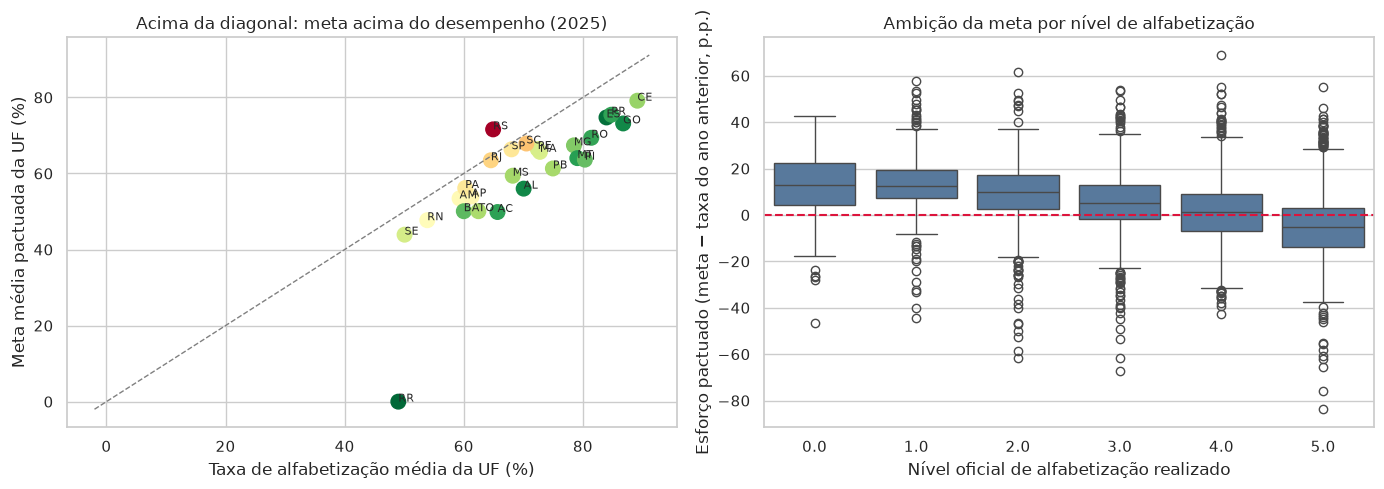

12453

In [95]:
# ------------------------------------------------------------
# 10.6 — Cumprimento da meta é uma dimensão diferente de alfabetização
# ------------------------------------------------------------

# O alvo só existe quando meta e taxa realizada estão disponíveis.
municipios_ano['risco_nao_atingir_meta'] = np.where(
    municipios_ano['meta'].isna() | municipios_ano['taxa_realizada'].isna(),
    np.nan,
    (municipios_ano['taxa_realizada'] < municipios_ano['meta']).astype(float)
)
municipios_ano['distancia_ate_a_meta'] = (
    municipios_ano['taxa_realizada'] - municipios_ano['meta'])
municipios_ano['esforco_pactuado'] = (
    municipios_ano['meta'] - municipios_ano['taxa_lag1'])

com_meta = municipios_ano.dropna(subset=['risco_nao_atingir_meta'])

print('Balanceamento de `risco_nao_atingir_meta` por ano')
display(pd.DataFrame({
    'municipios': com_meta.groupby('ano', observed=True).size(),
    'nao_cumpriu_pct': com_meta.groupby('ano', observed=True)
                               ['risco_nao_atingir_meta'].mean() * 100,
    'meta_media': com_meta.groupby('ano', observed=True)['meta'].mean(),
    'taxa_media': com_meta.groupby('ano', observed=True)['taxa_realizada'].mean(),
    'esforco_pactuado_mediano': com_meta.groupby('ano', observed=True)
                                        ['esforco_pactuado'].median(),
}).round(2))

ano_recente = max(com_meta['ano'])
recorte = com_meta[com_meta['ano'].eq(ano_recente)]

print(f'\nPor UF em {int(ano_recente)}: a meta explica o risco melhor que a taxa?')
por_uf = recorte.groupby('uf', observed=True).agg(
    municipios=('id_municipio', 'size'),
    nao_cumpriu_pct=('risco_nao_atingir_meta', 'mean'),
    taxa_media=('taxa_realizada', 'mean'),
    meta_media=('meta', 'mean'),
    pct_nivel_0_ou_1=('nivel_realizado', lambda s: (s <= 1).mean()),
)
por_uf['nao_cumpriu_pct'] = por_uf['nao_cumpriu_pct'] * 100
por_uf['pct_nivel_0_ou_1'] = por_uf['pct_nivel_0_ou_1'] * 100
display(por_uf.sort_values('nao_cumpriu_pct', ascending=False).round(2))

# Cruzamento direto: baixa alfabetização x não cumprimento da meta
cruzamento = pd.crosstab(
    recorte['nivel_realizado'].le(1).map({True: 'nível 0 ou 1', False: 'nível 2+'}),
    recorte['risco_nao_atingir_meta'].map({1.0: 'não cumpriu', 0.0: 'cumpriu'}),
)
print(f'\nBaixa alfabetização x cumprimento da meta — {int(ano_recente)}')
display(cruzamento)
concordancia_dimensoes = (
    recorte['nivel_realizado'].le(1).astype(int)
    .eq(recorte['risco_nao_atingir_meta'].astype(int)).mean())
print(f'As duas definições coincidem em {concordancia_dimensoes:.1%} dos municípios.')
print('Quanto menor esse valor, mais claro fica que são perguntas distintas e')
print('exigem alvos distintos.')

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].scatter(por_uf['taxa_media'], por_uf['meta_media'],
                 c=por_uf['nao_cumpriu_pct'], cmap='RdYlGn_r', s=110)
limites = [por_uf[['taxa_media', 'meta_media']].min().min() - 2,
           por_uf[['taxa_media', 'meta_media']].max().max() + 2]
eixos[0].plot(limites, limites, '--', color='grey', linewidth=1)
for uf, linha in por_uf.iterrows():
    eixos[0].annotate(uf, (linha['taxa_media'], linha['meta_media']), fontsize=8)
eixos[0].set_xlabel('Taxa de alfabetização média da UF (%)')
eixos[0].set_ylabel('Meta média pactuada da UF (%)')
eixos[0].set_title(f'Acima da diagonal: meta acima do desempenho ({int(ano_recente)})')

sns.boxplot(data=recorte, x='nivel_realizado', y='esforco_pactuado',
            color='#4C78A8', ax=eixos[1])
eixos[1].axhline(0, color='crimson', linestyle='--')
eixos[1].set_xlabel('Nível oficial de alfabetização realizado')
eixos[1].set_ylabel('Esforço pactuado (meta − taxa do ano anterior, p.p.)')
eixos[1].set_title('Ambição da meta por nível de alfabetização')

plt.tight_layout()
plt.show()
# Objetos temporários desta análise não são usados nas células seguintes.
del com_meta, recorte, por_uf, cruzamento, fig, eixos, limites
gc.collect()


**Interpretação — alfabetização e cumprimento da meta**

Os resultados confirmam que **baixo nível de alfabetização e não cumprimento da meta representam dimensões distintas do desempenho educacional**.

Em 2025, 27,3% dos municípios com meta válida não atingiram o resultado pactuado. O cruzamento com o nível de alfabetização mostra que **1.129 municípios classificados no nível 2 ou superior não cumpriram sua meta**, enquanto **153 municípios nos níveis 0 ou 1 conseguiram cumpri-la**.

As duas classificações coincidem em 76,7% dos municípios, mas divergem em aproximadamente 23,3%. Isso ocorre porque o nível de alfabetização avalia o **desempenho absoluto** do município, enquanto o cumprimento da meta compara o resultado realizado com um **referencial pactuado específico**.

Consequentemente, os dois indicadores não devem ser tratados como substitutos. O **risco educacional** responde à pergunta sobre quais municípios apresentam alfabetização criticamente baixa, enquanto o **risco de não atingir a meta** responde à pergunta sobre quais municípios podem ficar abaixo do resultado pactuado. Essa distinção justifica a utilização de alvos separados para os dois problemas de classificação.


### 10.7 Associações municipais mais úteis

A visualização é mantida apenas para quatro relações de interpretação direta: persistência temporal, renda, participação anterior e diferenças regionais.

Os gráficos são associativos, não causais.


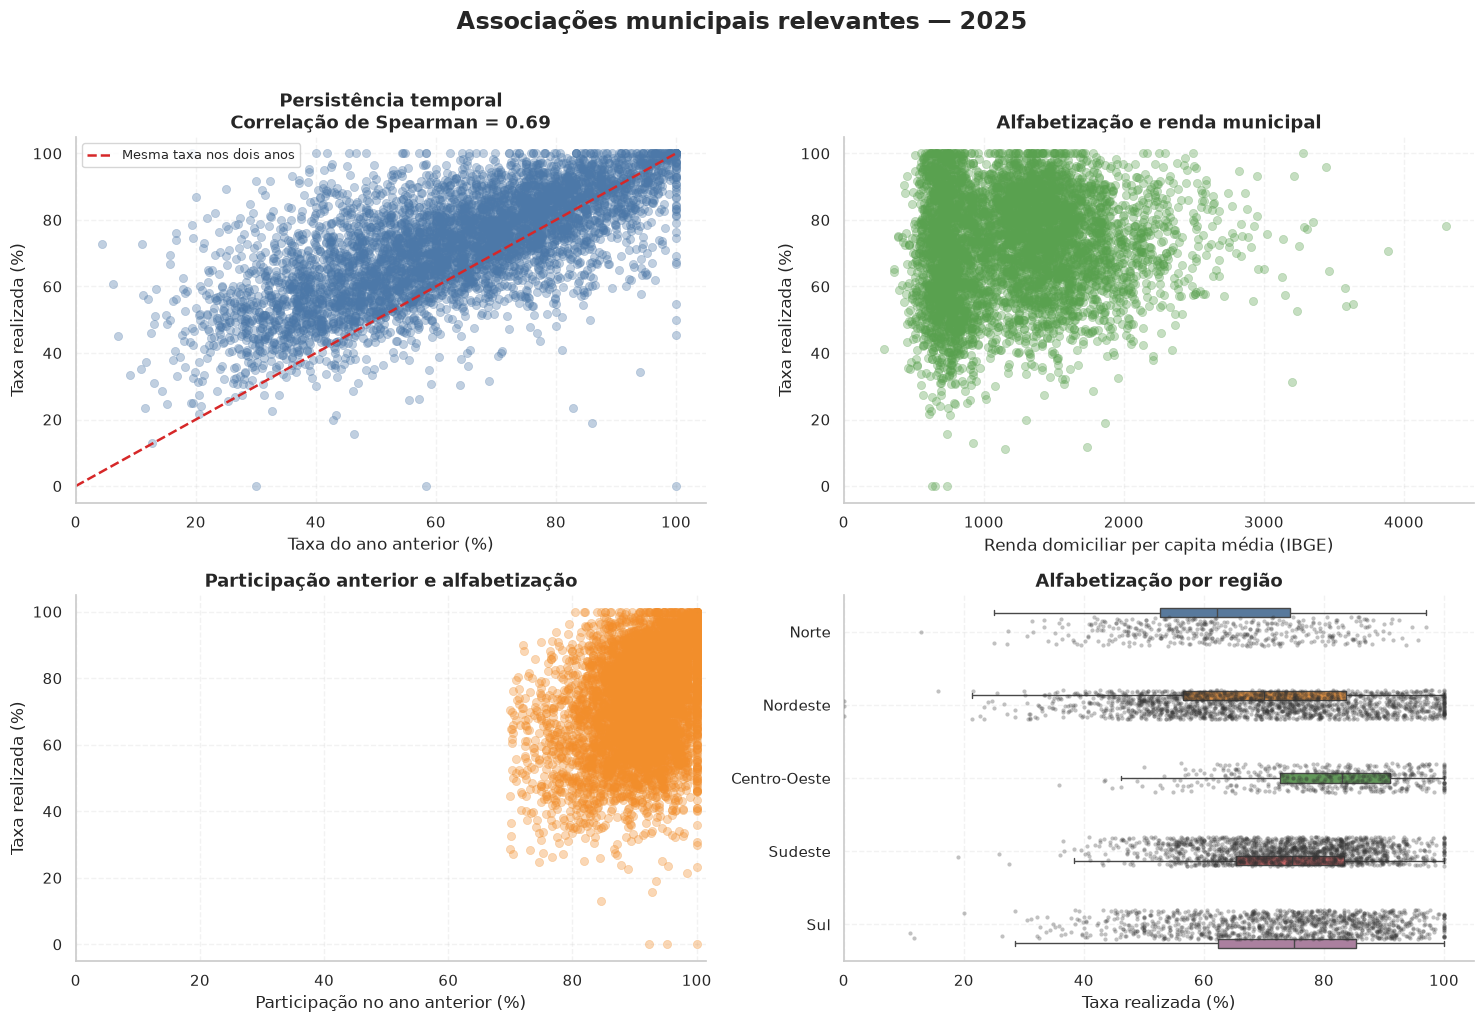

16648

In [96]:
# ------------------------------------------------------------
# 10.7 — Associações municipais mais úteis
# ------------------------------------------------------------

import gc

# Paleta fixa para as regiões
PALETA_REGIOES = {
    'Norte': '#4C78A8',
    'Nordeste': '#F28E2B',
    'Centro-Oeste': '#59A14F',
    'Sudeste': '#E15759',
    'Sul': '#B279A2'
}

recorte = municipios_ano[
    municipios_ano['ano'].eq(ano_recente)
].copy()

# Garante que a região seja tratada como categoria
ordem_regioes = [
    regiao for regiao in PALETA_REGIOES
    if regiao in recorte['regiao'].dropna().unique()
]

recorte['regiao'] = pd.Categorical(
    recorte['regiao'],
    categories=ordem_regioes,
    ordered=True
)

# Correlação de Spearman entre taxa anterior e taxa atual
dados_persistencia = recorte[
    ['taxa_lag1', 'taxa_realizada']
].dropna()

rho = dados_persistencia.corr(
    method='spearman'
).iloc[0, 1]

# Configuração visual
sns.set_theme(
    style='whitegrid',
    context='notebook'
)

fig, eixos = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# ------------------------------------------------------------
# 1. Persistência temporal
# ------------------------------------------------------------

sns.scatterplot(
    data=recorte,
    x='taxa_lag1',
    y='taxa_realizada',
    color='#4C78A8',
    alpha=0.35,
    s=35,
    edgecolor=None,
    ax=eixos[0, 0]
)

# Linha de referência: taxa anterior igual à taxa atual
eixos[0, 0].plot(
    [0, 100],
    [0, 100],
    color='#D62728',
    linestyle='--',
    linewidth=1.8,
    label='Mesma taxa nos dois anos'
)

eixos[0, 0].set_title(
    f'Persistência temporal\n'
    f'Correlação de Spearman = {rho:.2f}',
    fontsize=13,
    fontweight='bold'
)

eixos[0, 0].set_xlabel('Taxa do ano anterior (%)')
eixos[0, 0].set_ylabel('Taxa realizada (%)')
eixos[0, 0].legend(fontsize=9)

# ------------------------------------------------------------
# 2. Contexto socioeconômico
# ------------------------------------------------------------

sns.scatterplot(
    data=recorte,
    x='ctx_ibge_renda_domiciliar_per_capita_media',
    y='taxa_realizada',
    color='#59A14F',
    alpha=0.35,
    s=35,
    edgecolor=None,
    ax=eixos[0, 1]
)

eixos[0, 1].set_title(
    'Alfabetização e renda municipal',
    fontsize=13,
    fontweight='bold'
)

eixos[0, 1].set_xlabel(
    'Renda domiciliar per capita média (IBGE)'
)

eixos[0, 1].set_ylabel('Taxa realizada (%)')

# ------------------------------------------------------------
# 3. Participação anterior
# ------------------------------------------------------------

sns.scatterplot(
    data=recorte,
    x='participacao_lag1',
    y='taxa_realizada',
    color='#F28E2B',
    alpha=0.35,
    s=35,
    edgecolor=None,
    ax=eixos[1, 0]
)

eixos[1, 0].set_title(
    'Participação anterior e alfabetização',
    fontsize=13,
    fontweight='bold'
)

eixos[1, 0].set_xlabel('Participação no ano anterior (%)')
eixos[1, 0].set_ylabel('Taxa realizada (%)')

# ------------------------------------------------------------
# 4. Distribuição por região
# ------------------------------------------------------------

sns.boxplot(
    data=recorte,
    y='regiao',
    x='taxa_realizada',
    order=ordem_regioes,
    hue='regiao',
    palette=PALETA_REGIOES,
    legend=False,
    showfliers=False,
    width=0.65,
    ax=eixos[1, 1]
)

# Pontos individuais para mostrar a distribuição dos municípios
sns.stripplot(
    data=recorte,
    y='regiao',
    x='taxa_realizada',
    order=ordem_regioes,
    color='#333333',
    alpha=0.30,
    size=3,
    jitter=0.2,
    ax=eixos[1, 1]
)

eixos[1, 1].set_title(
    'Alfabetização por região',
    fontsize=13,
    fontweight='bold'
)

eixos[1, 1].set_xlabel('Taxa realizada (%)')
eixos[1, 1].set_ylabel('')

# ------------------------------------------------------------
# Ajustes gerais
# ------------------------------------------------------------

for ax in eixos.flat:
    ax.grid(
        axis='both',
        linestyle='--',
        alpha=0.25
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Mantém o mesmo limite quando a taxa está em percentual
    ax.set_xlim(left=0)

fig.suptitle(
    f'Associações municipais relevantes — {ano_recente}',
    fontsize=17,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Liberação de memória
# ------------------------------------------------------------

del dados_persistencia
del recorte
del fig
del eixos

gc.collect()


### 10.8 Correlação na granularidade município-ano

A seção 9 mediu associações na granularidade do aluno. Aqui cada linha representa a mesma entidade descrita pelas features: o município em um determinado ano.

A tabela usa Spearman para ordenar associações monotônicas com `taxa_realizada`. **Ela não é usada para remover novas features**: a redundância já foi tratada no início com a metodologia reproduzível de componentes `|ρ| ≥ 0,90`.

Portanto, esta seção é interpretativa e não cria uma segunda regra de seleção.


Associação com taxa_realizada — município-ano, 2025


,spearman
taxa_lag1,0.690
meta,0.571
esforco_pactuado,-0.449
participacao_lag1,0.317
populacao,-0.268
alunos,-0.245
ctx_atlas_taxa_fora_escola_6a14,-0.171
pct_rede_municipal,0.164
ctx_atlas_expectativa_anos_estudo,0.158
ctx_atlas_indice_gini,-0.156


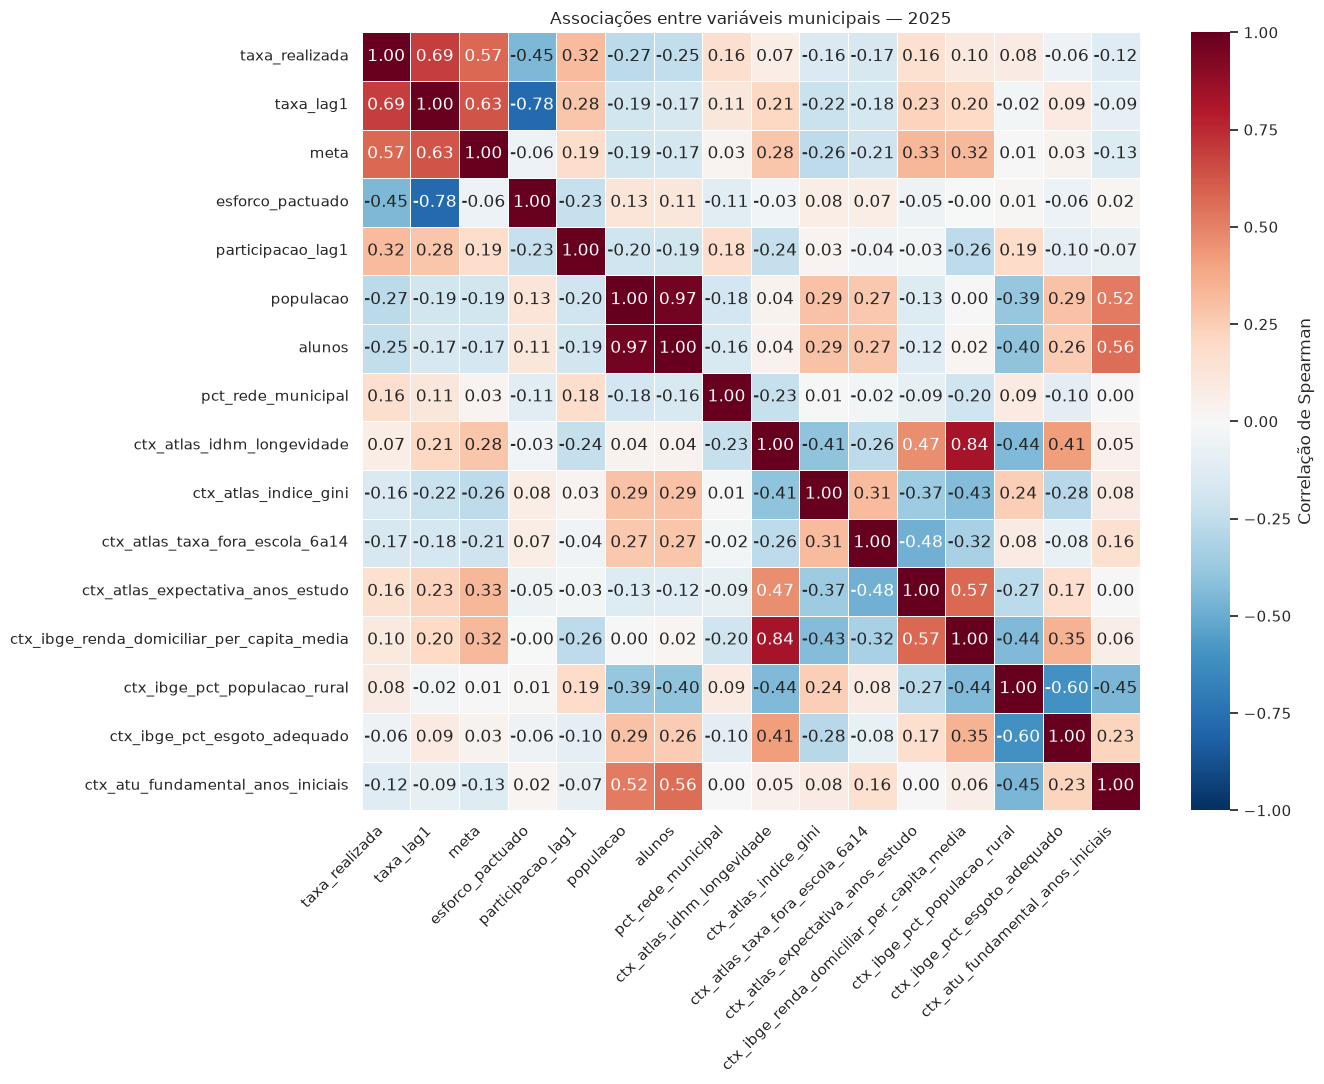

21671

In [97]:
# ------------------------------------------------------------
# 10.8 — Associações na granularidade município-ano
# ------------------------------------------------------------

import gc

VARIAVEIS_PRIORITARIAS = [
    'taxa_realizada', 'taxa_lag1', 'meta', 'esforco_pactuado',
    'participacao_lag1', 'populacao', 'alunos', 'pct_rede_municipal',
    'ctx_atlas_idhm_longevidade',
    'ctx_atlas_indice_gini',
    'ctx_atlas_taxa_fora_escola_6a14',
    'ctx_atlas_expectativa_anos_estudo',
    'ctx_ibge_renda_domiciliar_per_capita_media',
    'ctx_ibge_pct_populacao_rural',
    'ctx_ibge_pct_esgoto_adequado',
    'ctx_atu_fundamental_anos_iniciais',
]

# Mantém apenas variáveis existentes
VARIAVEIS_PRIORITARIAS = [
    c for c in VARIAVEIS_PRIORITARIAS
    if c in municipios_ano.columns
]

# Recorte do ano mais recente
recorte = municipios_ano.loc[
    municipios_ano['ano'].eq(ano_recente),
    VARIAVEIS_PRIORITARIAS
].copy()

# Conversão defensiva para numérico
recorte = recorte.apply(
    pd.to_numeric,
    errors='coerce'
)

# Matriz de correlação de Spearman
matriz = recorte.corr(
    method='spearman'
)

print(
    f'Associação com taxa_realizada — '
    f'município-ano, {int(ano_recente)}'
)

display(
    matriz['taxa_realizada']
    .drop('taxa_realizada')
    .sort_values(
        key=abs,
        ascending=False
    )
    .round(3)
    .to_frame('spearman')
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(14, 11))

sns.heatmap(
    matriz,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    square=True,
    cbar_kws={
        'label': 'Correlação de Spearman'
    }
)

plt.title(
    f'Associações entre variáveis municipais — {int(ano_recente)}'
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Liberação de memória
# ------------------------------------------------------------

del recorte, matriz
gc.collect()

## 11. Validação da seleção de features

A seleção estrutural foi aplicada no início do notebook **depois de produzir e exibir as evidências** correspondentes.

Metodologia única:

- `>10%` de nulos em 2024 → remoção;
- Spearman na granularidade municipal de 2024;
- `|ρ| ≥ 0,90` → features conectadas pertencem ao mesmo componente redundante;
- um representante por componente, seguindo regra explícita de preferência e fallback por missingness;
- `nivel_lag1 × taxa_lag1` → decisão sustentada por cobertura, Spearman e concordância com os cortes oficiais em 2024/2025;
- `_lag1` não é penalizado pelo missingness estrutural de 2023;
- nulos remanescentes serão tratados somente dentro do `Pipeline`.

Não é aplicada uma segunda metodologia de seleção por Pearson, VIF ou outro corte de correlação antes do baseline.


In [98]:
print(f'Colunas removidas no início: {len(COLUNAS_REMOVER)}')
print(f'  por missingness >10% em 2024: {len(REMOVER_MISSING_10)}')
print(f'  marcadas por redundância: {len(REMOVER_REDUNDANCIA)}')
print(f'Features contextuais restantes no df de análise: '
      f'{sum(c.startswith("ctx_") for c in df.columns)}')

print('\nHistórico educacional mantido: taxa_lag1.')
print('nivel_lag1 foi removida por redundância: Spearman=0,9853,')
print('concordância ≈99% e cobertura inferior à taxa_lag1.')


Colunas removidas no início: 39
  por missingness >10% em 2024: 12
  marcadas por redundância: 27
Features contextuais restantes no df de análise: 40

Histórico educacional mantido: taxa_lag1.
nivel_lag1 foi removida por redundância: Spearman=0,9853,
concordância ≈99% e cobertura inferior à taxa_lag1.


## 12. Evidência para a escolha dos alvos municipais

Antes de formalizar as targets, o notebook compara os cortes candidatos para **risco educacional absoluto**.

Os cortes 40, 50, 60 e 70% correspondem a fronteiras já presentes na escala oficial. A comparação mostra, para cada ano, quantos municípios seriam classificados como positivos.

O corte de **50%** não é escolhido para maximizar balanceamento. Ele é mantido por interpretação substantiva: identifica municípios em que **menos da metade das crianças avaliadas está alfabetizada**, correspondendo aos níveis oficiais 0 e 1.

A tabela também permite verificar o custo estatístico dessa escolha, especialmente a redução da prevalência da classe positiva em 2025.


Percentual de municípios classificados como risco


Ano,2023,2024,2025
Corte de risco (%),,,
40,17.1%,13.0%,2.5%
50,29.5%,25.8%,8.9%
60,46.5%,42.1%,23.2%
70,64.4%,60.5%,42.4%



Contagens completas


,ano,corte_pct,municipios_com_alvo,risco_1_n,risco_1_pct,risco_0_n,risco_0_pct
0,2023,40,"4,871",835,17.1%,"4,036",82.9%
1,2023,50,"4,871","1,435",29.5%,"3,436",70.5%
2,2023,60,"4,871","2,263",46.5%,"2,608",53.5%
3,2023,70,"4,871","3,138",64.4%,"1,733",35.6%
4,2024,40,"5,517",715,13.0%,"4,802",87.0%
5,2024,50,"5,517","1,425",25.8%,"4,092",74.2%
6,2024,60,"5,517","2,321",42.1%,"3,196",57.9%
7,2024,70,"5,517","3,336",60.5%,"2,181",39.5%
8,2025,40,"5,556",137,2.5%,"5,419",97.5%
9,2025,50,"5,556",497,8.9%,"5,059",91.1%


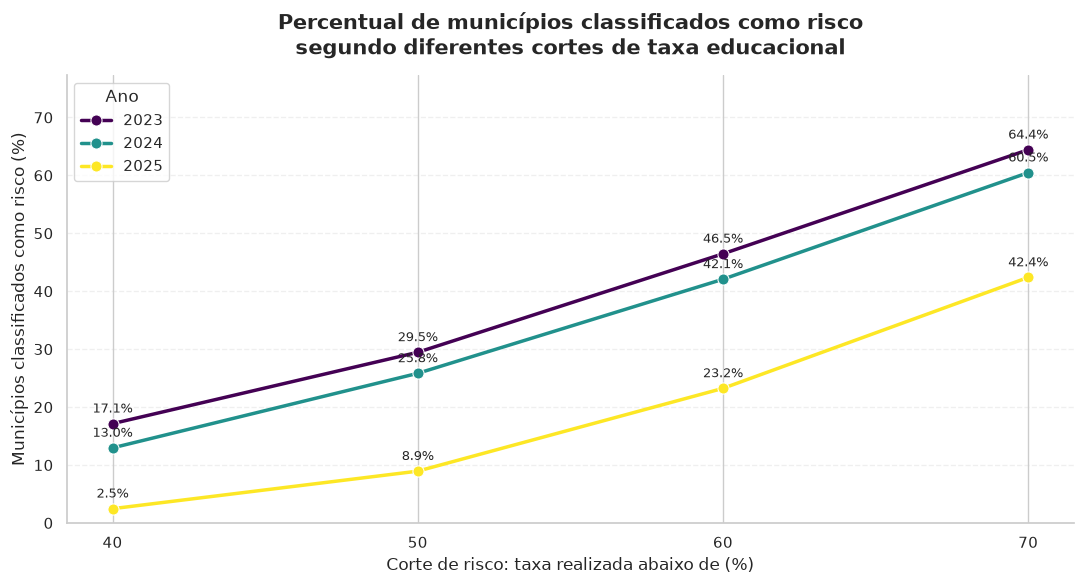

15545

In [99]:
# ------------------------------------------------------------
# 12 — Comparação empírica dos cortes de risco educacional
# ------------------------------------------------------------

import gc

CORTES_RISCO_CANDIDATOS = [40, 50, 60, 70]

linhas_cortes = []

for ano_diag, recorte_ano in municipios_ano.groupby(
    'ano',
    observed=True
):
    taxa = recorte_ano['taxa_realizada'].dropna()

    for corte in CORTES_RISCO_CANDIDATOS:
        positivos = taxa < corte

        linhas_cortes.append({
            'ano': int(ano_diag),
            'corte_pct': corte,
            'municipios_com_alvo': len(taxa),
            'risco_1_n': int(positivos.sum()),
            'risco_1_pct': positivos.mean() * 100,
            'risco_0_n': int((~positivos).sum()),
            'risco_0_pct': (~positivos).mean() * 100,
        })

comparacao_cortes_risco = pd.DataFrame(linhas_cortes)

# ------------------------------------------------------------
# Tabela principal
# ------------------------------------------------------------

print('Percentual de municípios classificados como risco')

tabela_percentuais = (
    comparacao_cortes_risco
    .pivot(
        index='corte_pct',
        columns='ano',
        values='risco_1_pct'
    )
    .round(2)
    .rename_axis(
        index='Corte de risco (%)',
        columns='Ano'
    )
)

display(
    tabela_percentuais.style.format('{:.1f}%')
)

# ------------------------------------------------------------
# Contagens completas
# ------------------------------------------------------------

print('\nContagens completas')

display(
    comparacao_cortes_risco.style.format({
        'ano': '{:.0f}',
        'corte_pct': '{:.0f}',
        'municipios_com_alvo': '{:,.0f}',
        'risco_1_n': '{:,.0f}',
        'risco_1_pct': '{:.1f}%',
        'risco_0_n': '{:,.0f}',
        'risco_0_pct': '{:.1f}%'
    })
)

# ------------------------------------------------------------
# Gráfico — percentual de municípios em risco por corte
# ------------------------------------------------------------

sns.set_theme(
    style='whitegrid',
    context='notebook'
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=comparacao_cortes_risco,
    x='corte_pct',
    y='risco_1_pct',
    hue='ano',
    palette='viridis',
    marker='o',
    markersize=8,
    linewidth=2.5,
    ax=ax
)

# Adiciona os percentuais próximos aos pontos
for _, linha in comparacao_cortes_risco.iterrows():
    ax.annotate(
        f'{linha["risco_1_pct"]:.1f}%',
        xy=(
            linha['corte_pct'],
            linha['risco_1_pct']
        ),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

ax.set_title(
    'Percentual de municípios classificados como risco\n'
    'segundo diferentes cortes de taxa educacional',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Corte de risco: taxa realizada abaixo de (%)'
)

ax.set_ylabel(
    'Municípios classificados como risco (%)'
)

ax.set_xticks(CORTES_RISCO_CANDIDATOS)
ax.set_ylim(
    0,
    min(100, comparacao_cortes_risco['risco_1_pct'].max() * 1.20)
)

ax.legend(
    title='Ano',
    frameon=True
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Libera objetos gráficos temporários
del fig
del ax

gc.collect()


## 12.1 Definição formal dos alvos municipais

Com as distribuições acima, a EDA termina com a definição dos alvos na unidade **município-ano**.

| Pergunta | Alvo | Tipo | Definição |
|---|---|---|---|
| Q1 — fatores associados à alfabetização | `taxa_realizada` | regressão | percentual de crianças alfabetizadas no município |
| Q2 — risco educacional | `risco_educacional` | classificação binária | `1` se `taxa_realizada < 50`, caso contrário `0` |
| Q4 — risco de não atingir a meta | `risco_nao_atingir_meta` | classificação binária | `1` se `taxa_realizada < meta`, caso contrário `0` |

### Justificativa das escolhas

- **Q1:** `taxa_realizada` preserva toda a informação contínua do desempenho municipal.
- **Q2:** o corte de 50% representa baixo desempenho absoluto — menos da metade das crianças alfabetizadas — e coincide com a agregação dos níveis oficiais 0 e 1. A tabela anterior mostra explicitamente o balanceamento resultante.
- **Q4:** a meta é um limiar externo e específico de cada município; portanto `taxa_realizada < meta` responde diretamente à pergunta de cumprimento da política.

`risco_educacional` e `risco_nao_atingir_meta` não são equivalentes: um município pode ter alfabetização baixa e ainda cumprir uma meta pouco ambiciosa, ou ter alfabetização relativamente alta e não cumprir uma meta mais exigente.

Q3 é não supervisionado e não possui target. Q5 será respondida posteriormente pela explicabilidade dos modelos selecionados.

As três targets supervisionadas são derivadas do resultado corrente e **nunca podem entrar em `X`**.


In [100]:
# ------------------------------------------------------------
# 12 — Definição formal e validação final dos alvos municipais
# ------------------------------------------------------------

ALVO_REGRESSAO_MUNICIPIO = 'taxa_realizada'
ALVO_CLASSIFICACAO_RISCO = 'risco_educacional'
ALVO_CLASSIFICACAO_META = 'risco_nao_atingir_meta'

LIMIAR_RISCO_EDUCACIONAL = 50.0

# Q2 — risco educacional absoluto
municipios_ano[ALVO_CLASSIFICACAO_RISCO] = np.where(
    municipios_ano[ALVO_REGRESSAO_MUNICIPIO].isna(),
    np.nan,
    (municipios_ano[ALVO_REGRESSAO_MUNICIPIO] < LIMIAR_RISCO_EDUCACIONAL).astype(float)
)

# Q4 — risco de não atingir a meta
municipios_ano[ALVO_CLASSIFICACAO_META] = np.where(
    municipios_ano['meta'].isna() | municipios_ano[ALVO_REGRESSAO_MUNICIPIO].isna(),
    np.nan,
    (municipios_ano[ALVO_REGRESSAO_MUNICIPIO] < municipios_ano['meta']).astype(float)
)

ALVOS_SUPERVISIONADOS = [
    ALVO_REGRESSAO_MUNICIPIO,
    ALVO_CLASSIFICACAO_RISCO,
    ALVO_CLASSIFICACAO_META,
]

# Variáveis derivadas do resultado corrente: excluir de qualquer matriz X.
COLUNAS_PROIBIDAS_X = [
    'taxa_realizada',
    'nivel_realizado',
    'risco_educacional',
    'risco_nao_atingir_meta',
    'distancia_ate_a_meta',
]

print('=== ALVOS DEFINIDOS ===')
print(f'Q1 — Regressão:       {ALVO_REGRESSAO_MUNICIPIO}')
print(f'Q2 — Classificação:   {ALVO_CLASSIFICACAO_RISCO} '
      f'(< {LIMIAR_RISCO_EDUCACIONAL:.0f}%)')
print(f'Q4 — Classificação:   {ALVO_CLASSIFICACAO_META}')
print('Q3 — Clustering:      sem target')
print('Q5 — Explicabilidade: usa os modelos selecionados')

# Validação final: cobertura e balanceamento
resumo_alvos = []

for ano, recorte in municipios_ano.groupby('ano', observed=True):
    n = len(recorte)

    resumo_alvos.append({
        'ano': int(ano),
        'municipios': n,
        'taxa_realizada_disponivel_pct':
            recorte[ALVO_REGRESSAO_MUNICIPIO].notna().mean() * 100,
        'risco_educacional_1_n':
            int((recorte[ALVO_CLASSIFICACAO_RISCO] == 1).sum()),
        'risco_educacional_1_pct':
            recorte[ALVO_CLASSIFICACAO_RISCO].mean() * 100,
        'risco_meta_1_n':
            int((recorte[ALVO_CLASSIFICACAO_META] == 1).sum()),
        'risco_meta_1_pct':
            recorte[ALVO_CLASSIFICACAO_META].mean() * 100,
        'sem_meta_n':
            int(recorte['meta'].isna().sum()),
    })

resumo_alvos = pd.DataFrame(resumo_alvos).set_index('ano')

print('\nValidação final dos alvos por ano')
display(resumo_alvos.round(2))

# Sanidade lógica das targets
assert (
    municipios_ano.loc[
        municipios_ano[ALVO_CLASSIFICACAO_RISCO].eq(1),
        ALVO_REGRESSAO_MUNICIPIO
    ] < LIMIAR_RISCO_EDUCACIONAL
).all()

assert municipios_ano.loc[
    municipios_ano['meta'].isna(),
    ALVO_CLASSIFICACAO_META
].isna().all()

print('\nValidações lógicas dos alvos: OK')

# Coleta objetos temporários já sem referência nesta etapa.
gc.collect()


=== ALVOS DEFINIDOS ===
Q1 — Regressão:       taxa_realizada
Q2 — Classificação:   risco_educacional (< 50%)
Q4 — Classificação:   risco_nao_atingir_meta
Q3 — Clustering:      sem target
Q5 — Explicabilidade: usa os modelos selecionados

Validação final dos alvos por ano


,municipios,taxa_realizada_disponivel_pct,risco_educacional_1_n,risco_educacional_1_pct,risco_meta_1_n,risco_meta_1_pct,sem_meta_n
ano,,,,,,,
2023,4871,100.000,1435,29.460,0,NaN,4871
2024,5517,100.000,1425,25.830,2478,45.530,75
2025,5556,100.000,497,8.950,1500,27.280,57



Validações lógicas dos alvos: OK


4364

## 13. Encerramento da EDA e transição para modelagem

A análise exploratória termina aqui.

### Decisões consolidadas

- **Unidade de modelagem:** município-ano.
- **Qualidade das features:** remover `>10%` de nulos em 2024 e reduzir componentes com `|Spearman| ≥ 0,90` a um representante.
- **Histórico educacional:** manter `taxa_lag1`; remover `nivel_lag1`.
- **Q1 — regressão:** `taxa_realizada`.
- **Q2 — classificação de risco educacional:** `risco_educacional = taxa_realizada < 50`.
- **Q3 — clustering:** sem target.
- **Q4 — classificação de cumprimento da meta:** `risco_nao_atingir_meta = taxa_realizada < meta`.
- **Q5 — explicabilidade:** aplicada aos modelos selecionados.
- **Validação temporal:** 2024 para desenvolvimento/validação e 2025 como teste temporal final.
- **Imputação:** somente dentro do `Pipeline`, ajustada no conjunto de treino.
- **Leakage:** targets e qualquer variável derivada do resultado corrente ficam fora de `X`.

### Próxima etapa: preparação para modelagem

A partir deste ponto, o trabalho deixa de ser EDA. O próximo notebook/bloco deve:

1. construir matrizes `X` e `y` municipais separadas para regressão e para cada classificação;
2. definir explicitamente as features disponíveis antes do desfecho;
3. separar 2024 e 2025 temporalmente;
4. criar o `Pipeline` de preprocessing/imputação;
5. estabelecer modelos baseline;
6. definir métricas adequadas para regressão e classificação;
7. comparar modelos sem usar 2025 para seleção de hiperparâmetros;
8. somente depois avaliar uma vez no teste temporal de 2025.

Para Q4, municípios sem `meta` ficam fora **apenas** do dataset dessa classificação. Eles não precisam ser descartados da regressão, do risco educacional ou do clustering.
